In [10]:
import scanpy as sc
import anndata
from scipy import io
import scipy
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pickle
import pandas as pd
import matplotlib.pyplot as pl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import matplotlib as mpl
import matplotlib as mp
mpl.rcParams['pdf.fonttype'] = 42

sc.settings.set_figure_params(facecolor='white', dpi=100, frameon=False)

import matplotlib.colors

In [3]:
full = sc.read_h5ad('all_cells_orig_UMAP.h5ad')

In [4]:
work_dir = ''

meta = pickle.load(open(os.path.join(work_dir, 'epithelial_epi_no_LumHR_bigsur_scvi_from_all.pkl'), 'rb'))

In [5]:
meta=meta.raw.to_adata()

In [6]:
full = full[meta.obs_names,:].copy()

In [7]:
full = full[:,meta.var_names].copy()

In [8]:
meta.X=full.X

In [9]:
meta.obs['Group'].value_counts()

Group
WKBR_MG       17729
Control        5130
WKBR_Tumor     3121
Name: count, dtype: int64

In [10]:
meta.obs['SampleID'].value_counts()

SampleID
WKBR65.2f      3319
WKBR61.4dTM    3092
WKBR65.2g      2541
CBLT           2011
WKBR75.4bMG    1943
WKBR61.4dMG    1630
CBLA13         1489
WKBR65.3h      1369
WKBR91.1f      1307
WKBR90.3g      1214
WKBR91.1e      1023
WKBR65.3g       962
CTRL_2          864
WKBR90.3i       821
WKBR76.4f       706
WKBR65.3i       569
CTRL_1          453
WKBR91.3j       325
CTRL_3          313
WKBR75.4bTM      29
Name: count, dtype: int64

<h1 id="no-LumHR,-MUT-only">no LumHR, MUT + WT only</h1>

In [13]:
wk = meta[meta.obs['Group'].isin(['WKBR_MG','Control'])]
wk = wk[~wk.obs['SampleID'].isin(['CBLT','CBLA13'])]

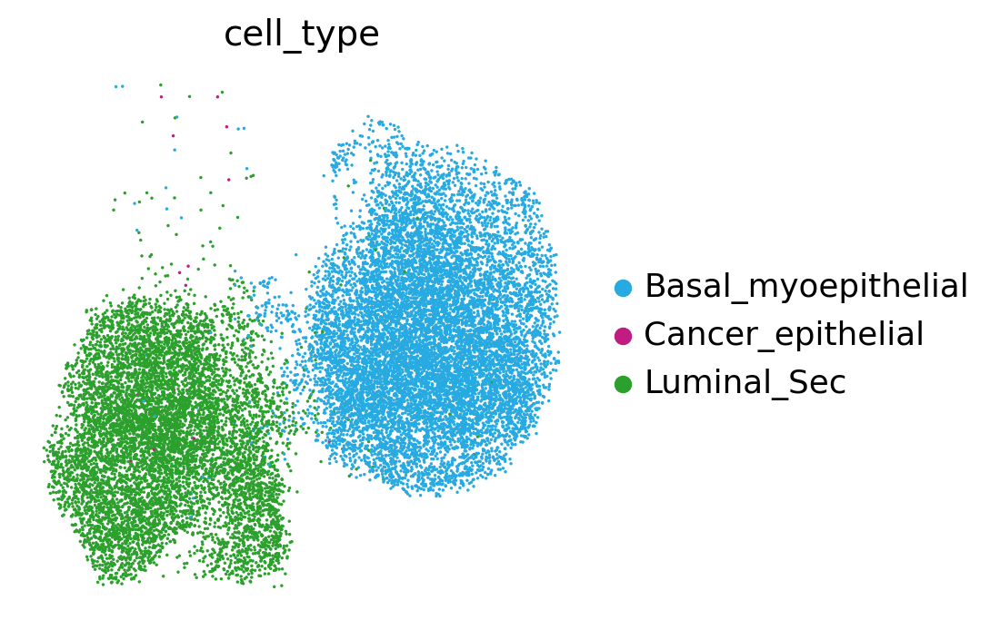

In [16]:
sc.pl.umap(wk, color=["cell_type"])

In [17]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import scanpy as sc
import anndata as ad
import os
import sys
sys.path.append('/data/homezvol3/tzhuravl/bin/bigsur/BigSur')
from BigSur.feature_selection import mcfano_feature_selection as mcfano

sc.pp.filter_genes(wk, min_cells=1)
wk.layers["counts"] = wk.X.copy()
mcfano(wk, layer='counts')

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:275: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


Using 0.01 for pvalue cutoff and 0.95 for mcfano quantile cutoff for highly variable genes.


/opt/apps/python/3.10.2/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


In [18]:
wk.var["mt"] = wk.var_names.str.startswith("mt-")
wk.var["ribo"] = wk.var_names.str.startswith(("Rps", "Rpl"))

sc.pp.calculate_qc_metrics(
    wk, qc_vars=["mt", "ribo"], inplace=True, log1p=True
)

In [19]:
sc.pp.normalize_total(wk, target_sum=1e4)
sc.pp.log1p(wk)

In [20]:
wk.raw = wk


wk = wk[:, wk.var.highly_variable].copy()
wk = wk.copy()
sc.pp.regress_out(wk, ['total_counts'])

In [21]:
wk

AnnData object with n_obs × n_vars = 19359 × 703
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums', 'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore', 'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups', 'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin', 'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', 'scaled_combined_lumsec_basal', 'subtype', 'p.value', 'correlation', 'subtype_tumor_only'
    var: 'n_cells', 'mc_Fano', 'FDR_adj_pvalue', 'p_value', 'highly_variable', 

In [22]:
scvi.model.SCVI.setup_anndata(wk, batch_key="Batch", layer="counts")

In [23]:
scvi_ref = scvi.model.SCVI(
    wk,
    use_layer_norm="both",
    use_batch_norm="none",
    encode_covariates=True,
    dropout_rate=0.2,
    n_layers=2,
)
scvi_ref.train()

/opt/apps/python/3.10.2/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /opt/apps/python/3.10.2/lib/python3.10/site-package ...
/opt/apps/python/3.10.2/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3 /opt/apps/python/3.10.2/lib/python3.10/site-package ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/opt/apps/python/3.10.2/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HI

Epoch 400/400: 100%|██████████| 400/400 [4:22:57<00:00, 34.03s/it, v_num=1, train_loss_step=556, train_loss_epoch=503]  

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [4:22:57<00:00, 39.44s/it, v_num=1, train_loss_step=556, train_loss_epoch=503]


In [24]:
work_dir = ''

scvi_ref_path = os.path.join(work_dir, "scvi_epi_mut_wt_no_LumHR_from_all")
scvi_ref.save(scvi_ref_path, overwrite=True)

In [25]:
SCVI_LATENT_KEY = "X_scVI"

wk.obsm[SCVI_LATENT_KEY] = scvi_ref.get_latent_representation()

In [26]:
sc.pp.neighbors(wk, use_rep="X_scVI")
sc.tl.leiden(wk)
sc.tl.umap(wk)

In [41]:
sc.tl.leiden(wk, resolution = 0.2)

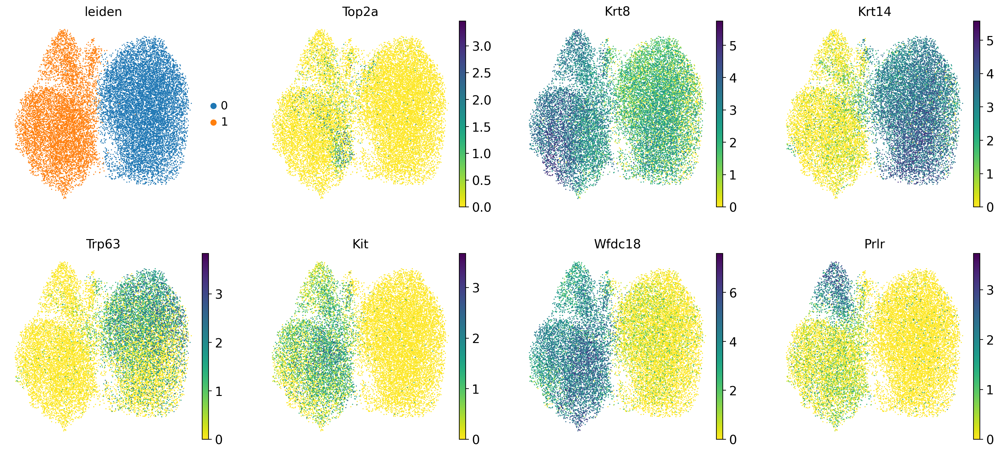

In [42]:
sc.pl.umap(wk, color=["leiden", "Top2a", "Krt8", "Krt14", "Trp63", "Kit","Wfdc18","Prlr"], cmap = 'viridis_r')

In [174]:
wk.obs["cell_type_epi_individual"] = wk.obs["leiden"].map(
    {
        "0": "Basal_myoepithelial",
        "1": "Luminal_Sec"
    }
)

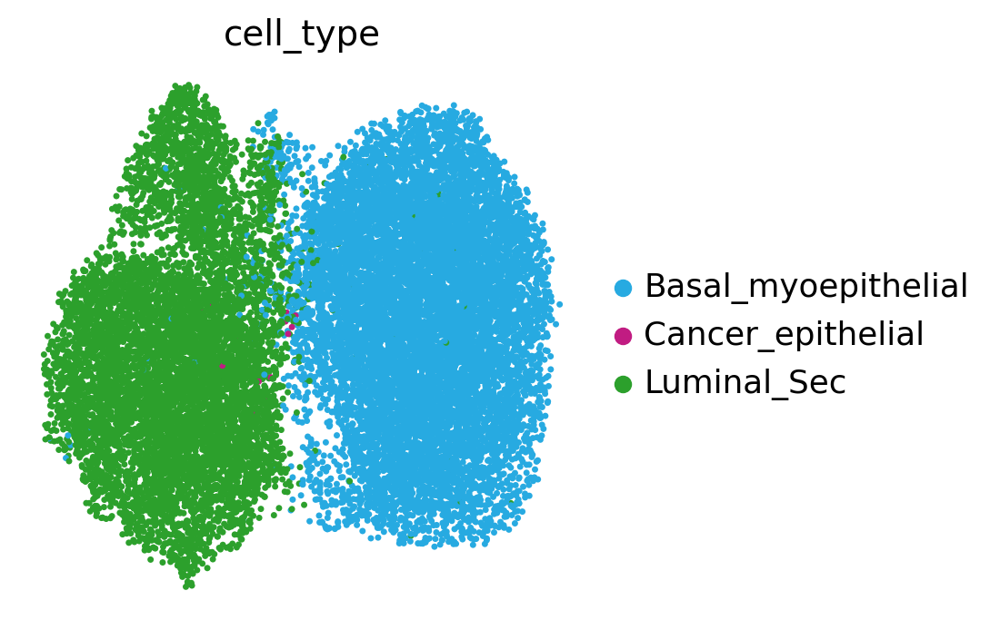

In [30]:
sc.pl.umap(wk, color=["cell_type"],
           s=25,palette = {'Basal_myoepithelial':'#27AAE1',
                                                        'Luminal_Sec':'#2ca02c',
                                                        'Cancer_epithelial':'#C11C82'},save='_celltype_on_mutant.pdf')

In [158]:
wk.obs['Group'].value_counts()

Group
WKBR_MG    17729
Control     1630
Name: count, dtype: int64

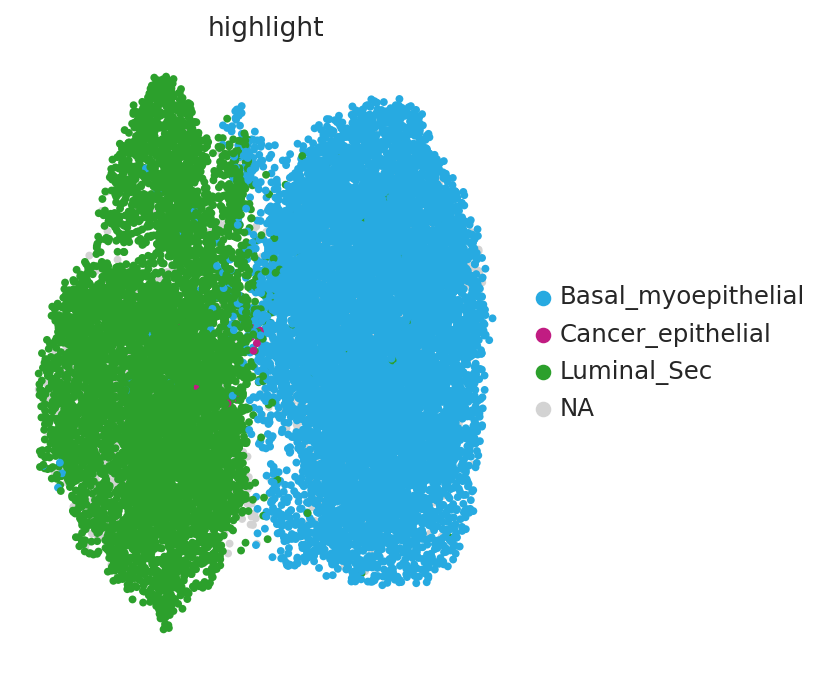

In [165]:
highlight = wk[wk.obs['Group'].isin(['WKBR_MG'])].copy()

pl.rcParams["figure.figsize"] = (4,5)

highlight.obs['highlight'] = (
    highlight.obs["highlight"]
    .map(lambda x: {"Basal_myoepithelial":"1",
                    "Luminal_Sec": "0",
                   "Cancer_epithelial": "2"}.get(x, x))
    .astype('int32')
)

wk.obs['highlight'] = highlight.obs['cell_type']

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#2ca02c','#27AAE1',
                                                        '#C11C82'])

sc.pl.umap(wk, color='highlight', cmap = cmap, size=50)

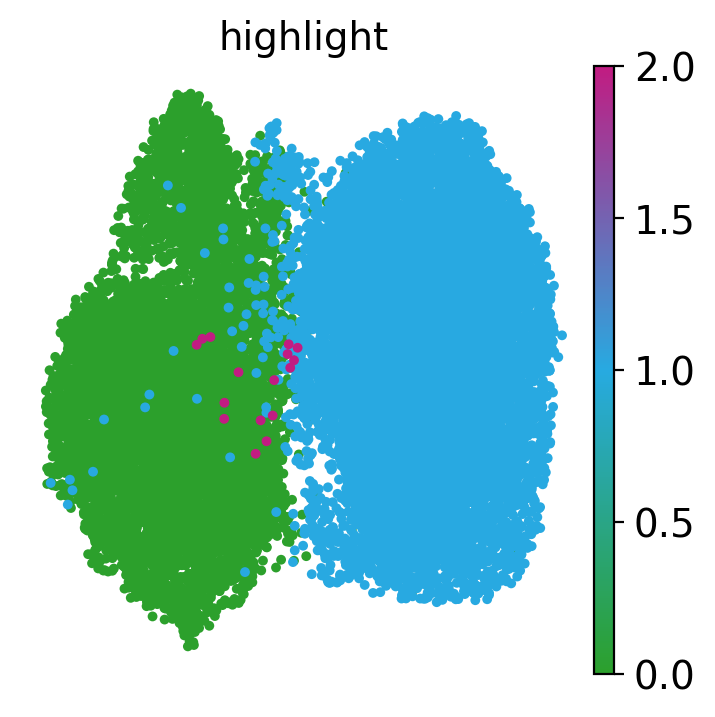

In [52]:
wk.obs['highlight'] = wk.obs['cell_state_epi_with_tumor']

wk.obs['highlight'] = (
    wk.obs["highlight"]
    .map(lambda x: {"Basal_myoepithelial":"1",
                    "Luminal_Sec": "0",
                   "Cancer_epithelial": "2"}.get(x, x))
    .astype('int32')
)

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#2ca02c','#27AAE1',
                                                        '#C11C82'])

sc.pl.umap(wk, color='highlight', cmap = cmap, size=50)

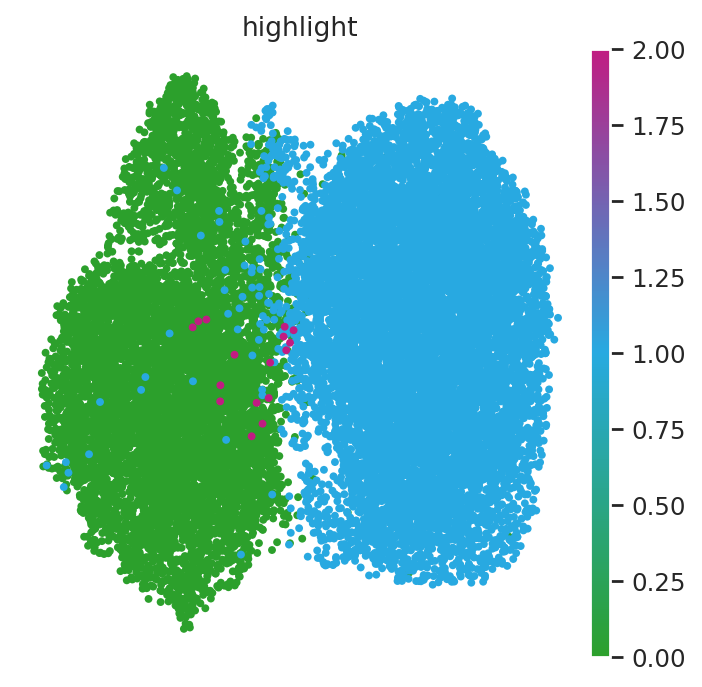

In [177]:
wk.obs['highlight'] = wk.obs['cell_type']

wk.obs['highlight'] = (
    wk.obs["highlight"]
    .map(lambda x: {"Basal_myoepithelial":"1",
                    "Luminal_Sec": "0",
                   "Cancer_epithelial": "2"}.get(x, x))
    .astype('int32')
)

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#2ca02c','#27AAE1',
                                                        '#C11C82'])
pl.rcParams["figure.figsize"] = (5,5)

sc.pl.umap(wk, color='highlight', cmap = cmap, size=50)

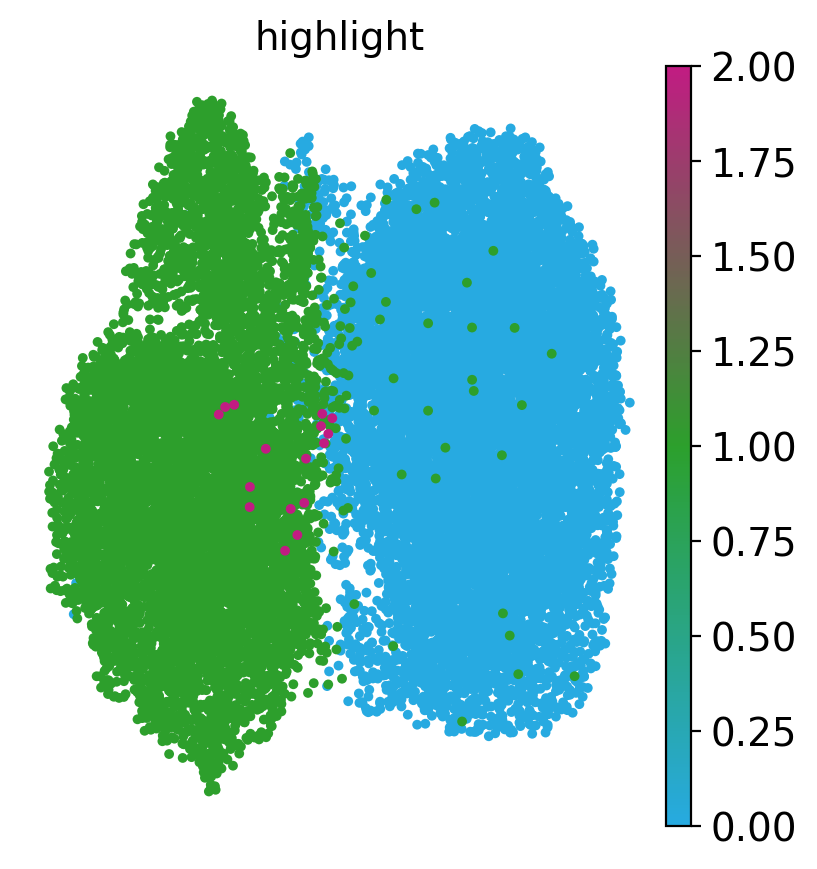

In [7]:
wk.obs['highlight'] = wk.obs['cell_type']


wk.obs['highlight'] = (
    wk.obs["highlight"]
    .map(lambda x: {"Basal_myoepithelial":"0",
                    "Cancer_epithelial": "2",
                   "Luminal_Sec": "1"}.get(x, x))
    .astype('int32')
)

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#27AAE1','#2ca02c','#C11C82'])
pl.rcParams["figure.figsize"] = (4.5,5)

sc.pl.umap(wk, color='highlight', cmap = cmap, size=50)

In [201]:
wk.obs['cell_type'].value_counts()

cell_type
Basal_myoepithelial    11140
Luminal_Sec             8203
Cancer_epithelial         16
Name: count, dtype: int64

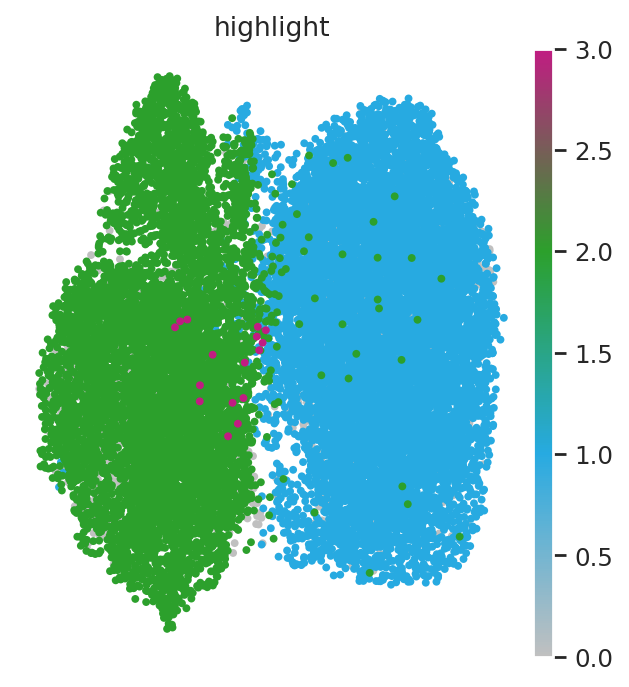

In [185]:
c

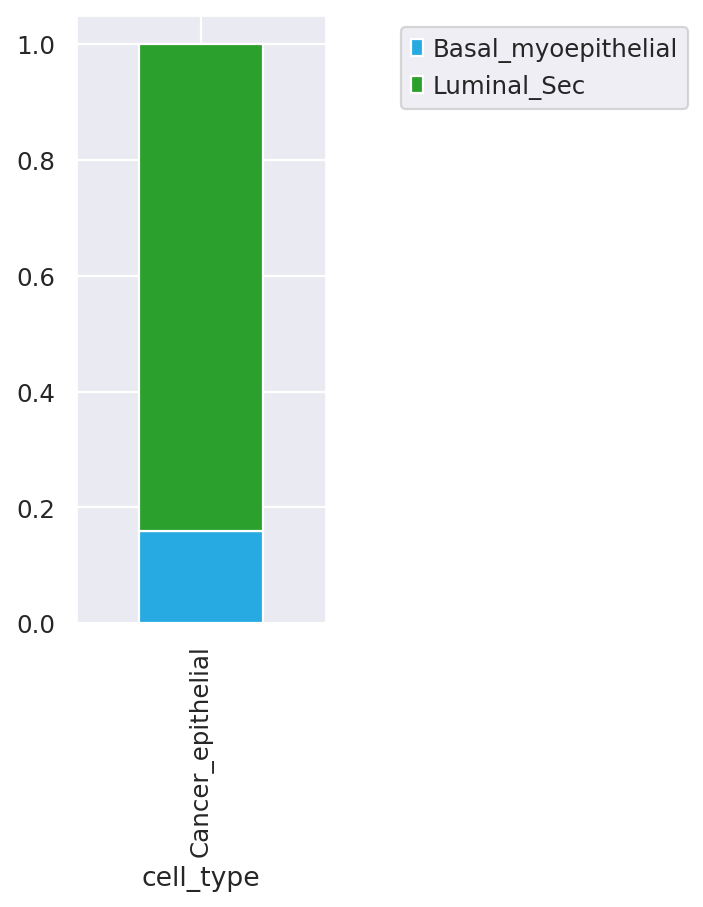

In [180]:
highlight = epi[epi.obs['cell_type'].isin(['Cancer_epithelial'])].copy()

tmp = pd.crosstab(highlight.obs['cell_type_epi_individual'],highlight.obs['cell_type'], 
                  normalize='columns').T.plot(kind='bar', stacked=True, color=['#27AAE1','#2ca02c'])
tmp.legend(title='', bbox_to_anchor=(2.5, 1),loc='upper right')

pl.rcParams["figure.figsize"] = (2,5)
pl.savefig('cancer_epi_basal_or_lumsec_stackedbar_plot.pdf', bbox_inches='tight')

In [33]:
wk.obs["cell_state_epi_with_tumor"]=epi.obs["cell_state_epi_with_tumor"]

In [205]:
scores = pd.read_csv("blg_scaled_combined_lumsec_basal.csv", index_col=0)

In [206]:
wk.obs["scaled_combined_lumsec_basal"]=scores["scaled_combined_lumsec_basal"]

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


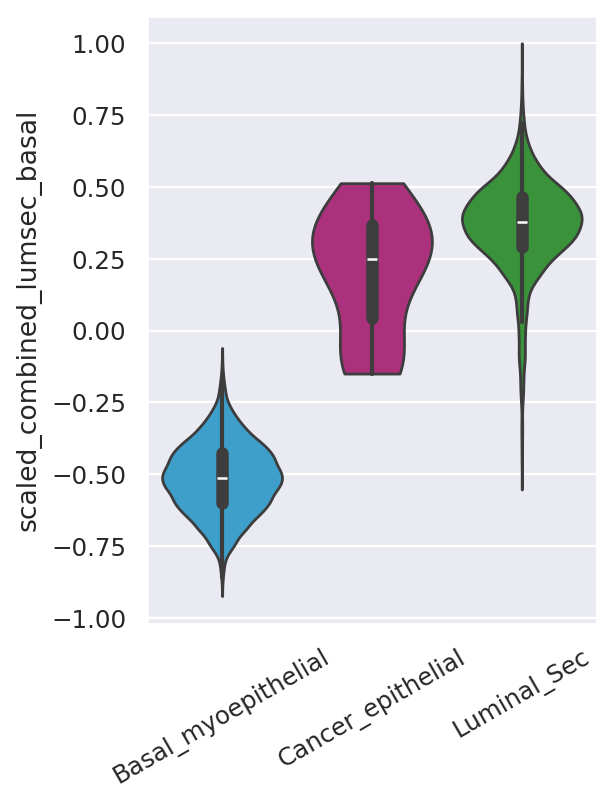

In [208]:
highlight = wk[wk.obs['Group'].isin(['WKBR_MG'])]

pl.rcParams["figure.figsize"] = (4,5)

sc.pl.violin(highlight, ["scaled_combined_lumsec_basal"], groupby="cell_type", 
             rotation=30, palette = {'Basal_myoepithelial':'#27AAE1','Cancer_epithelial':'#C11C82','Luminal_Sec':'#2ca02c'},
             stripplot=False,order=['Basal_myoepithelial','Cancer_epithelial','Luminal_Sec'],
             inner='box',save='violin_scaled_combined_lumsec_basal_cell_state_epi_with_tumor.pdf')

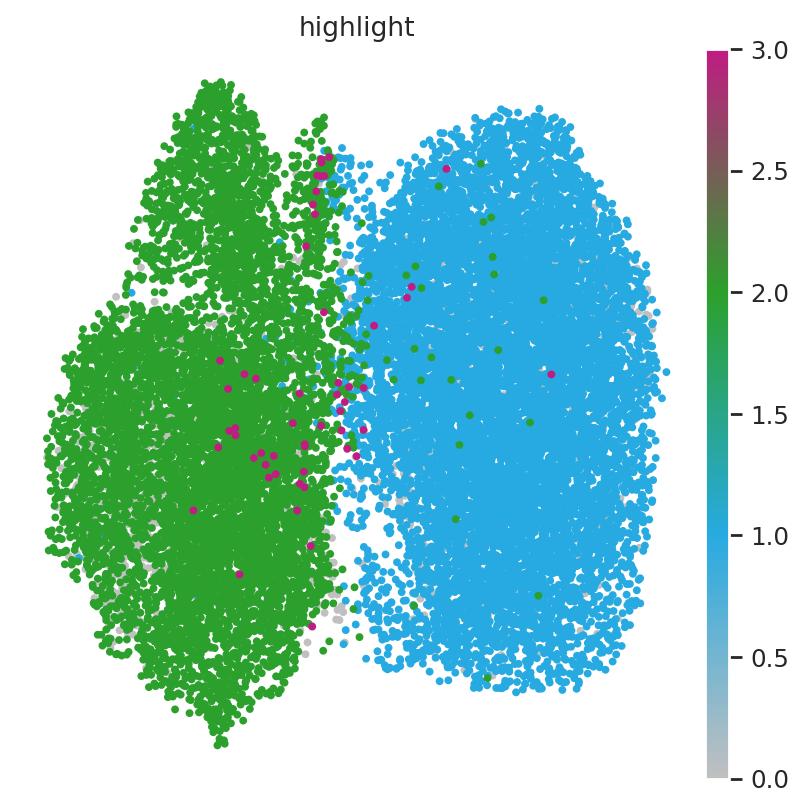

In [64]:
highlight = wk[wk.obs['Group'].isin(['WKBR_MG'])]

wk.obs['highlight'] = highlight.obs['cell_state_epi_with_tumor']

categories = np.array(
     ['Basal_myoepithelial', 'Cancer_epithelial', 'Luminal_Sec', 'other'])

wk.obs['highlight'] = pd.Categorical(
   wk.obs['highlight'], categories=categories, ordered=True)

wk.obs['highlight'].fillna("other", inplace=True)

wk.obs['highlight'] = (
    wk.obs["highlight"]
    .map(lambda x: {"Basal_myoepithelial":"1",
                    "Cancer_epithelial": "3",
                   "Luminal_Sec": "2",
                   "other": "0"}.get(x, x))
    .astype('int32')
)

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["silver",'#27AAE1','#2ca02c','#C11C82'])

sc.pl.umap(wk, color='highlight', cmap = cmap, size=50)

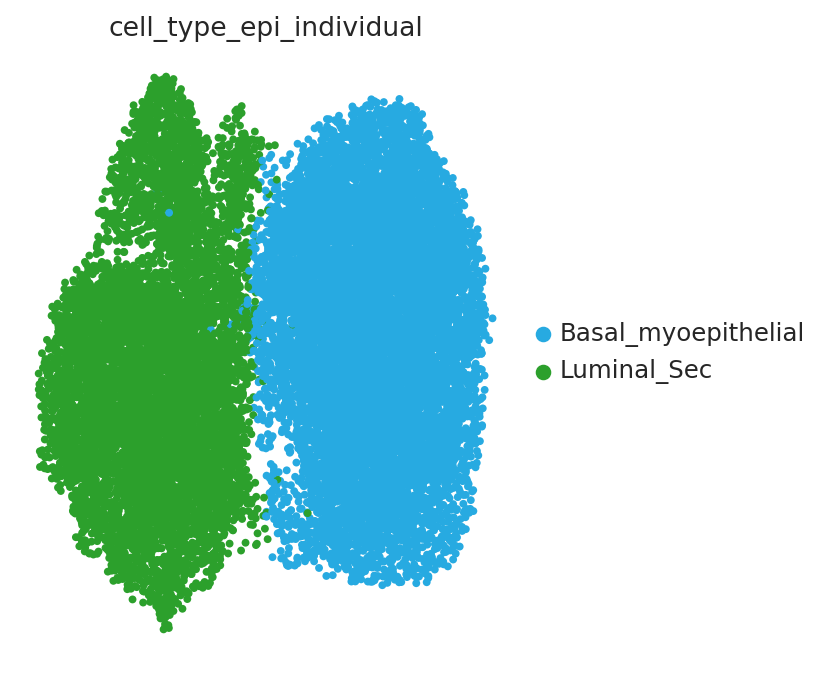

In [167]:
sc.pl.umap(wk, color=["cell_type_epi_individual"],
           s=50,palette = {'Basal_myoepithelial':'#27AAE1',
                                                        'Luminal_Sec':'#2ca02c'},save='indiv_cell_type_epi_individual.pdf')

In [33]:
pickle.dump(wk,
            open(os.path.join(work_dir, 'epithelial_mut_wt_LumHR_bigsur_scvi_from_all.pkl'), 'wb'))

In [4]:
wk.obs['Group'].value_counts()

Group
WKBR_MG    17729
Control     1630
Name: count, dtype: int64

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


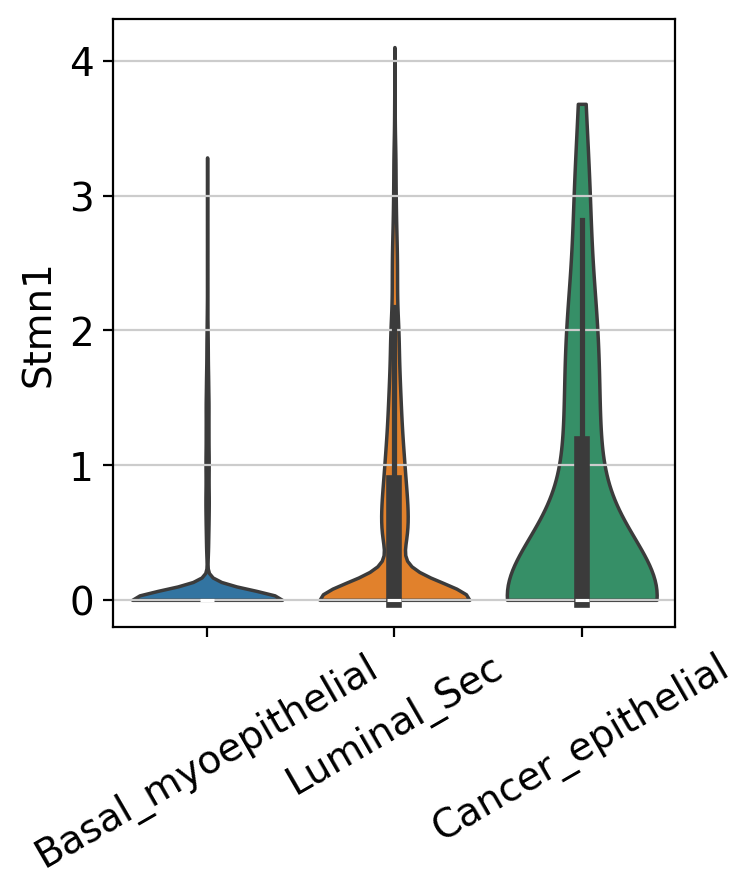

In [8]:
sub = wk[wk.obs['Group'].isin(["WKBR_MG"])]
sc.pl.violin(sub, ["Stmn1"], groupby="cell_state_epi_with_tumor", 
             rotation=30, 
             stripplot=False,
             inner='box')

In [16]:
s = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/s_phase_genes.csv", index_col=0)
s = s['x'].to_list()
g2m = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/g2m_phase_genes.csv", index_col=0)
g2m = g2m['x'].to_list()

In [17]:
sc.tl.score_genes_cell_cycle(wk, s_genes=s, g2m_genes=g2m)

In [19]:
wk.obs.columns

Index(['orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample',
       'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums',
       'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore',
       'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups',
       'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin',
       'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       '_scvi_batch', '_scvi_labels', 'leiden', 'scaled_combined_lumsec_basal',
       'subtype', 'p.value', 'correlation', 'subtype_tumor_only',
       'cell_type_epi_individual', 'highlight

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


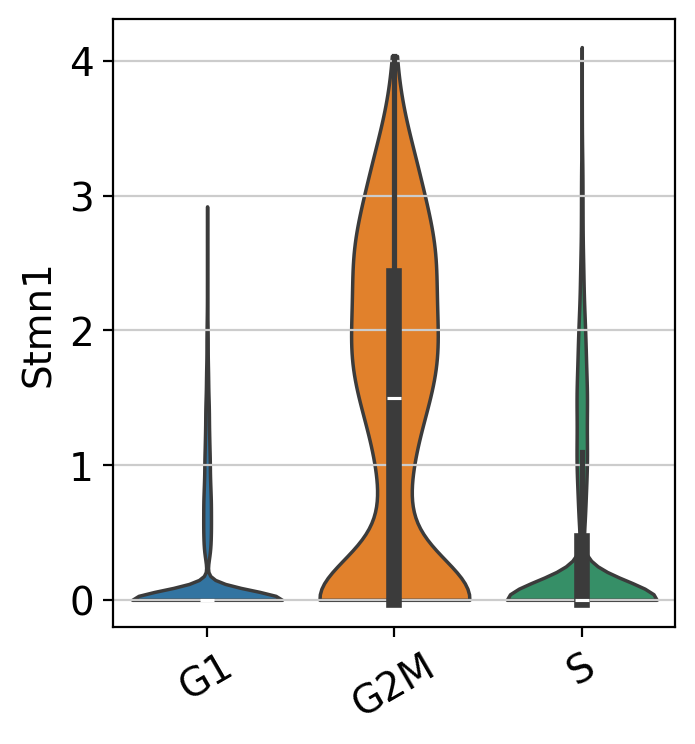

In [20]:
sub = wk[wk.obs['Group'].isin(["WKBR_MG"])]


sc.pl.violin(sub, ["Stmn1"], groupby="phase", 
             rotation=30, 
             stripplot=False,
             inner='box')

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


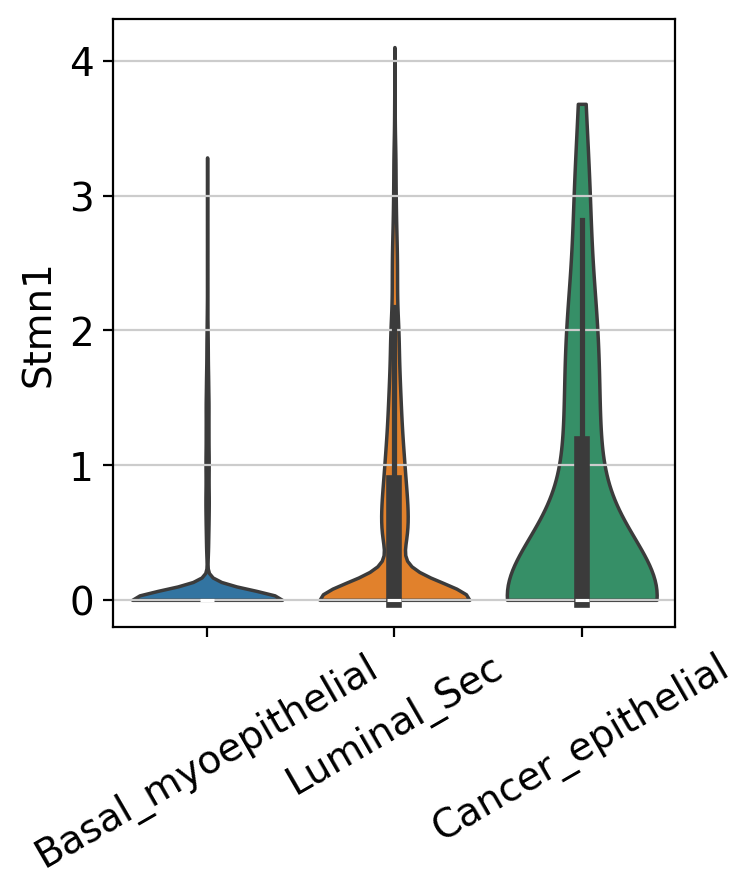

In [25]:
sub = wk[wk.obs['Group'].isin(["WKBR_MG"])]


sc.pl.violin(sub, ["Stmn1"], groupby="cell_state_epi_with_tumor", 
             rotation=30, 
             stripplot=False,
             inner='box')

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


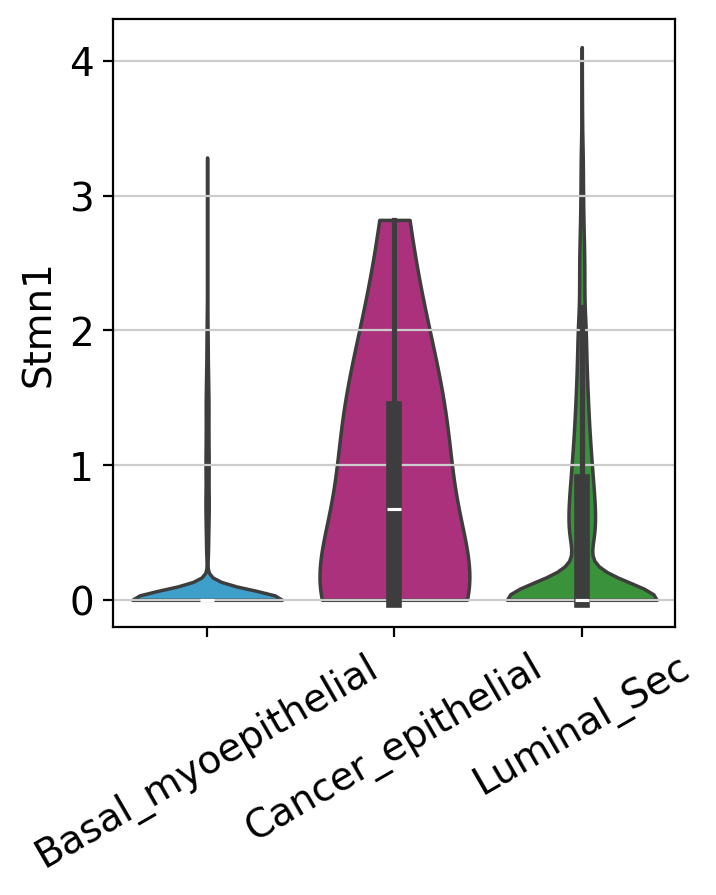

In [26]:
sub = wk[wk.obs['Group'].isin(["WKBR_MG"])]


sc.pl.violin(sub, ["Stmn1"], groupby="cell_type", 
             rotation=30, 
             stripplot=False,
             inner='box')

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


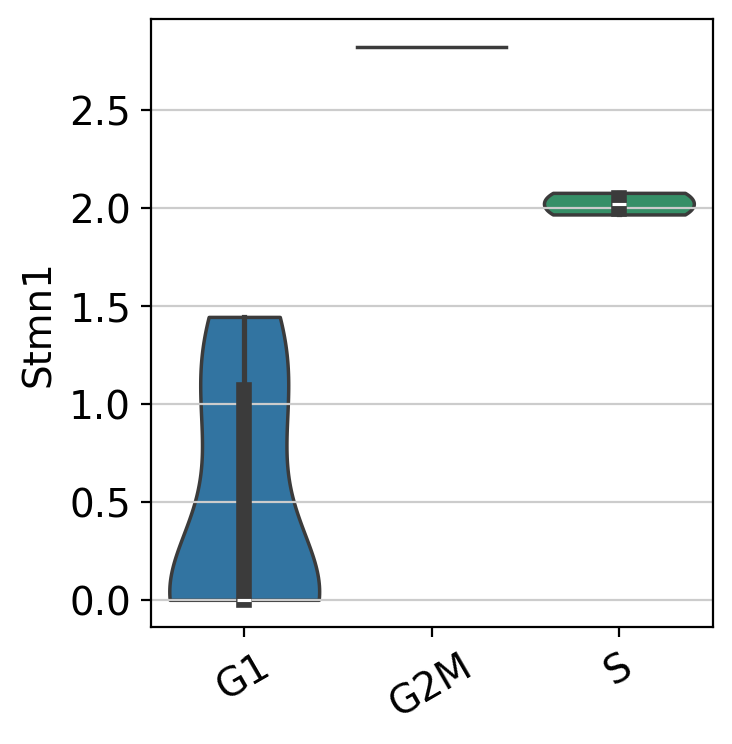

In [27]:
sub = wk[wk.obs['Group'].isin(["WKBR_MG"])]
sub = sub[sub.obs['cell_type'].isin(["Cancer_epithelial"])]

sc.pl.violin(sub, ["Stmn1"], groupby="phase", 
             rotation=30, 
             stripplot=False,
             inner='box')

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


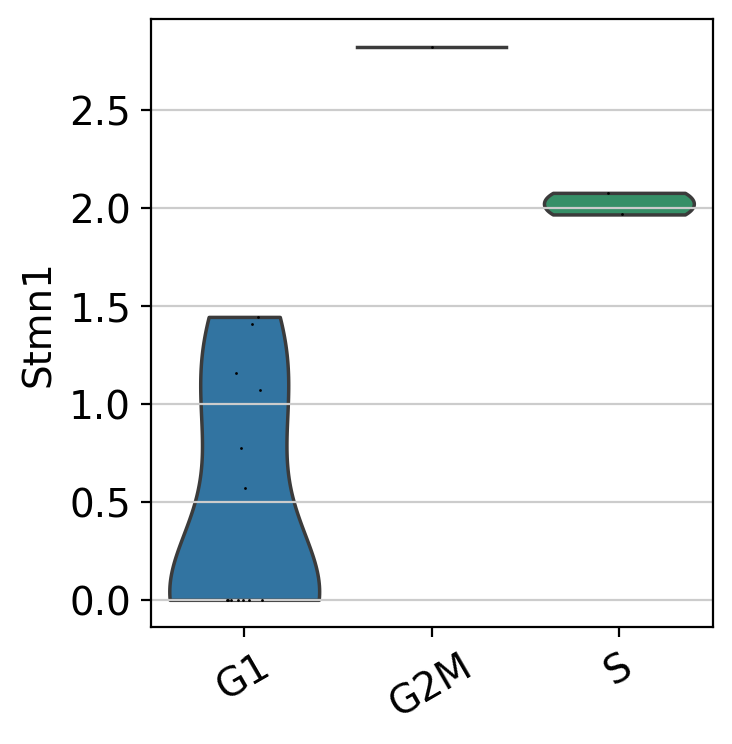

In [29]:
sub = wk[wk.obs['Group'].isin(["WKBR_MG"])]
sub = sub[sub.obs['cell_type'].isin(["Cancer_epithelial"])]

sc.pl.violin(sub, ["Stmn1"], groupby="phase", 
             rotation=30)

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


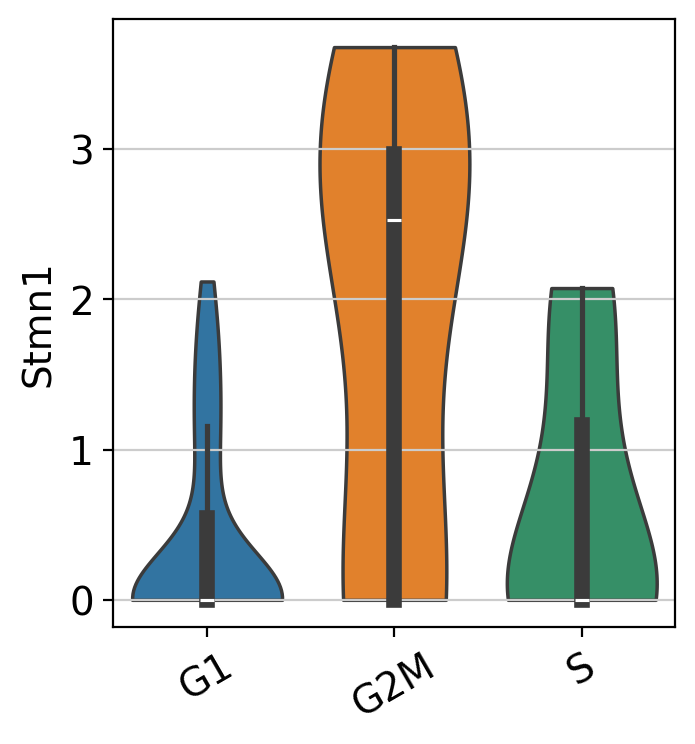

In [31]:
sub = wk[wk.obs['Group'].isin(["WKBR_MG"])]
sub = sub[sub.obs['cell_state_epi_with_tumor'].isin(["Cancer_epithelial"])]

sc.pl.violin(sub, ["Stmn1"], groupby="phase", 
             rotation=30, 
             stripplot=False,
             inner='box')

In [32]:
sub

AnnData object with n_obs × n_vars = 53 × 703
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums', 'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore', 'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups', 'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin', 'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', 'scaled_combined_lumsec_basal', 'subtype', 'p.value', 'correlation', 'subtype_tumor_only', 'cell_type_epi_individual', 'highlight', 'cell_state_epi_with_tumor', 'S_score', 

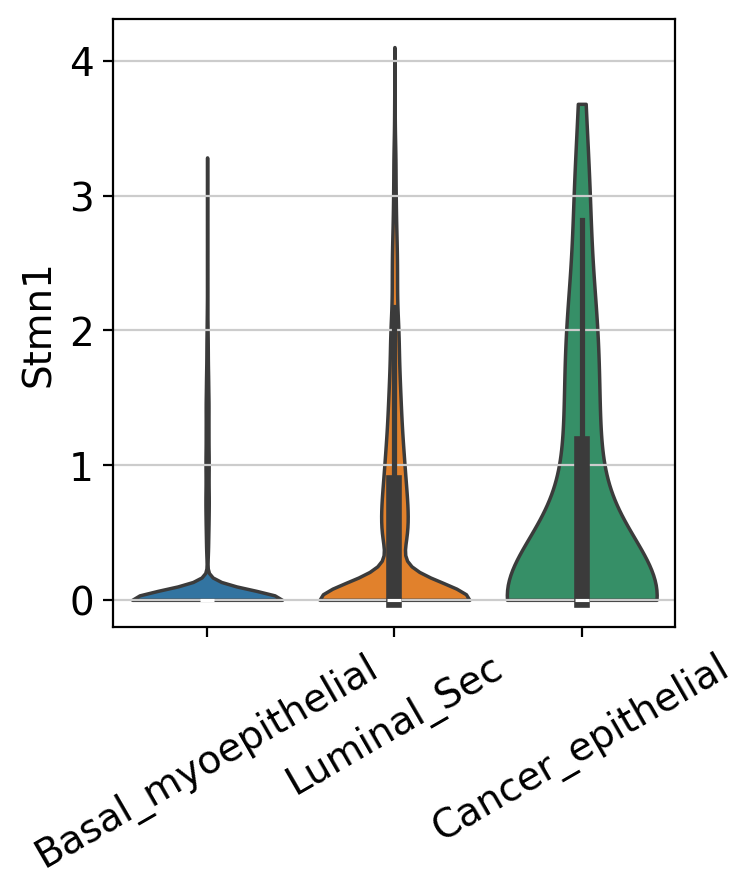

In [21]:
sc.pl.violin(sub, ["Stmn1"], groupby="cell_state_epi_with_tumor", 
             rotation=30, 
             stripplot=False,
             inner='box')

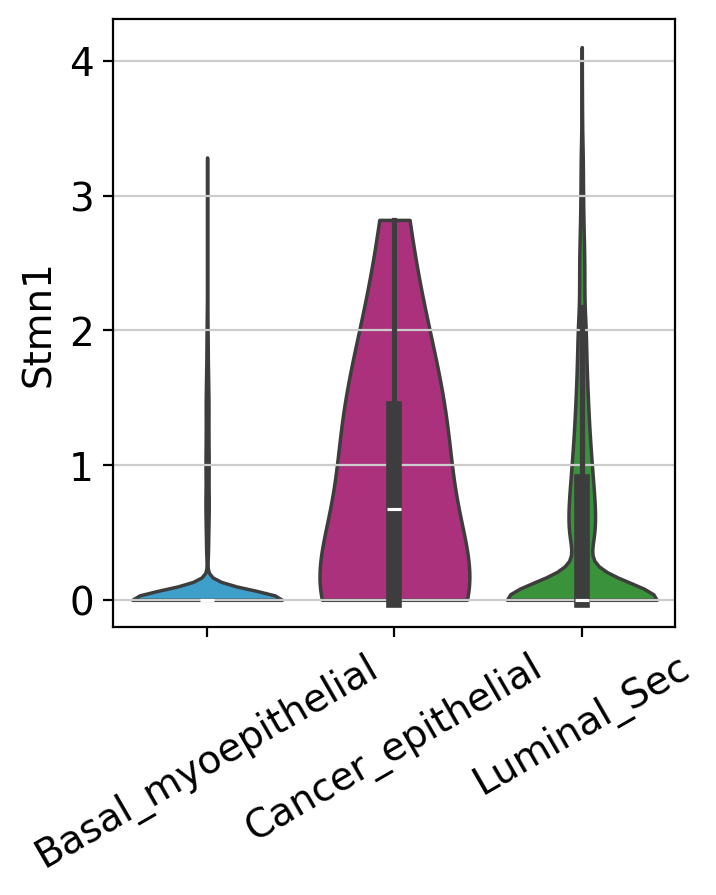

In [23]:
sc.pl.violin(sub, ["Stmn1"], groupby="cell_type", 
             rotation=30, 
             stripplot=False,
             inner='box')

In [11]:
work_dir = ''

wk = pickle.load(open(os.path.join(work_dir, 'epithelial_mut_wt_LumHR_bigsur_scvi_from_all.pkl'), 'rb'))

In [18]:
wk

AnnData object with n_obs × n_vars = 19359 × 703
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums', 'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore', 'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups', 'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin', 'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', 'scaled_combined_lumsec_basal', 'subtype', 'p.value', 'correlation', 'subtype_tumor_only', 'cell_type_epi_individual', 'highlight'
    var: 'n_cells', 'mc_Fano', 'FDR_ad

In [107]:
backup = wk
wk = wk[wk.obs['Group'].isin(['WKBR_MG'])]

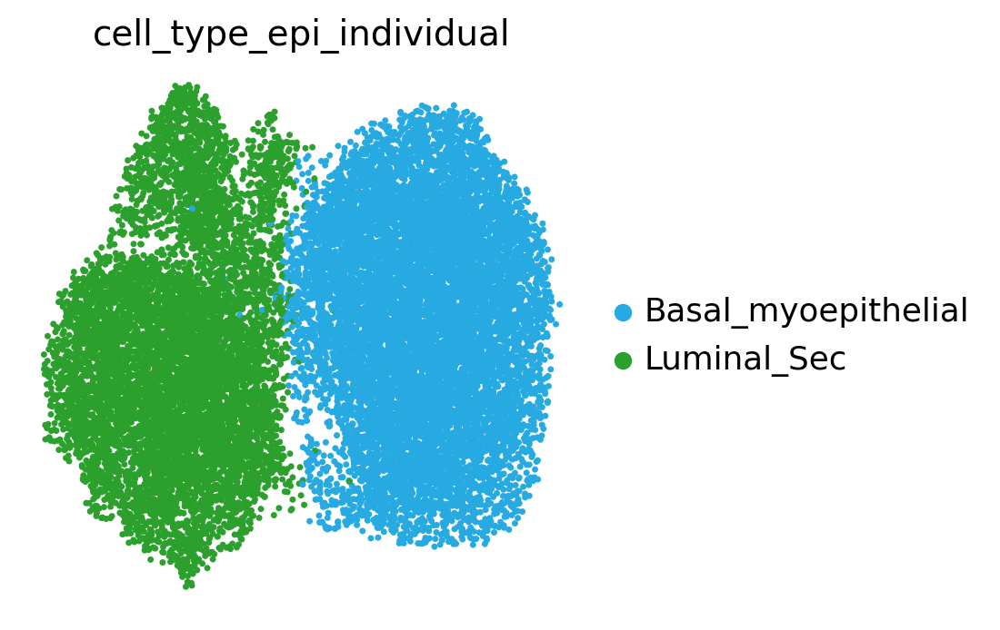

In [12]:
sc.pl.umap(wk, color=["cell_type_epi_individual"],
           s=25,palette = {'Basal_myoepithelial':'#27AAE1',
                                                        'Luminal_Sec':'#2ca02c'},save='indiv_cell_type_epi_individual.pdf')

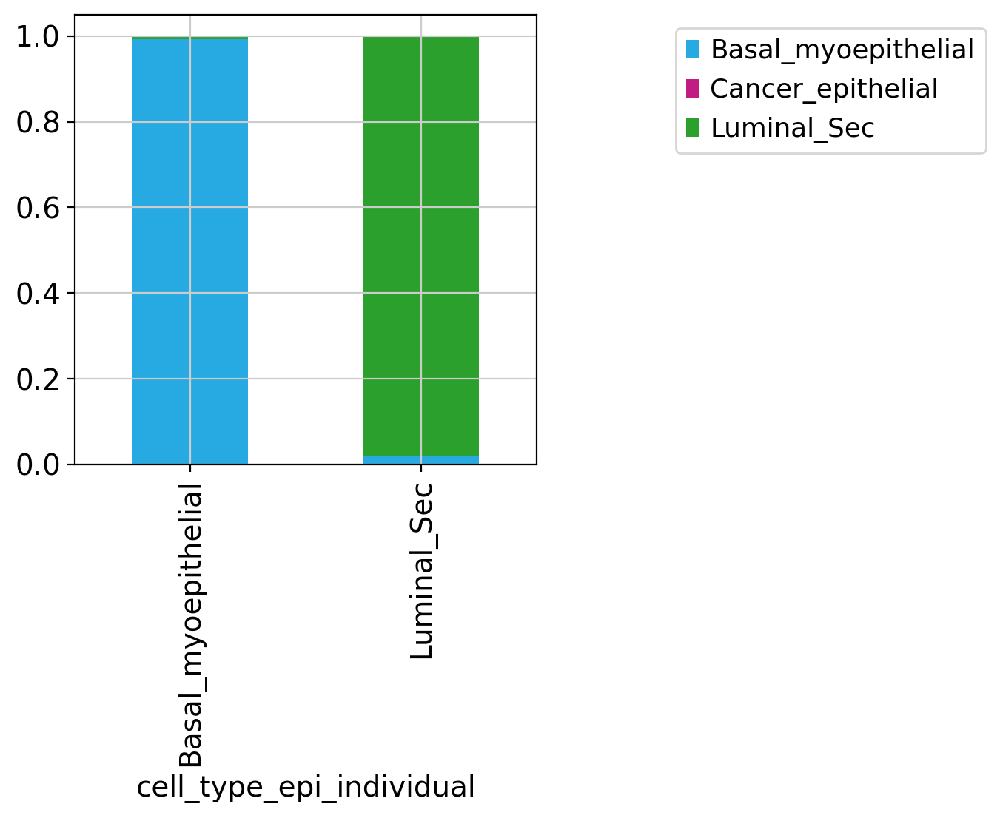

In [39]:
tmp = pd.crosstab(wk.obs['cell_type'],wk.obs['cell_type_epi_individual'], normalize='columns').T.plot(kind='bar', stacked=True,color=['#27AAE1',
                                                        '#C11C82','#2ca02c'])
tmp.legend(title='', bbox_to_anchor=(2.0, 1.0),loc='upper right')

pl.savefig('leiden_celltype_epi__mutant_stackedbar_plot.pdf', bbox_inches='tight')

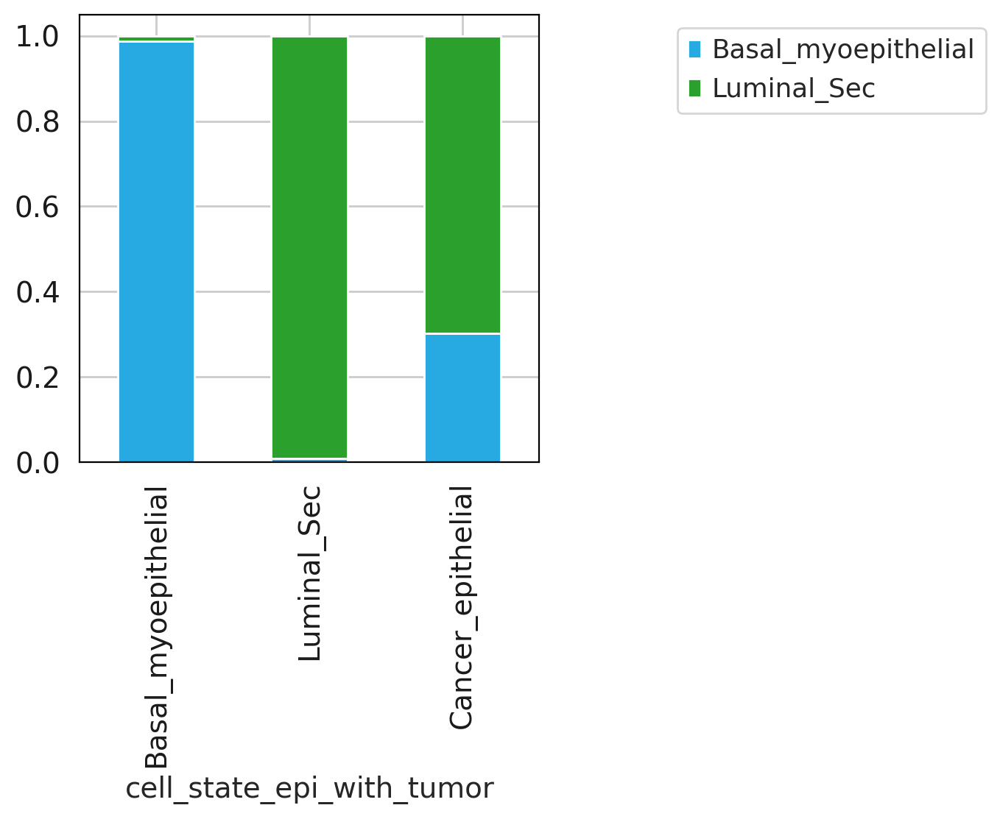

In [109]:
tmp = pd.crosstab(wk.obs['cell_type_epi_individual'],wk.obs['cell_state_epi_with_tumor'], 
                  normalize='columns').T.plot(kind='bar', stacked=True,color=['#27AAE1','#2ca02c','#C11C82'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('celltype_all_by_celltype_mut_stackedbar_plot.pdf', bbox_inches='tight')

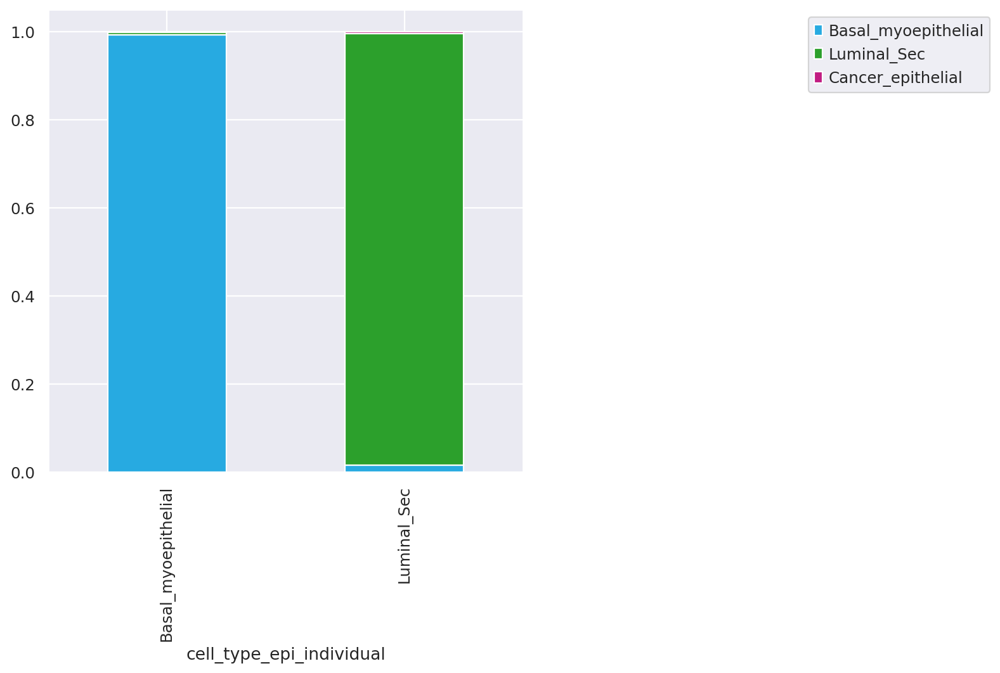

In [84]:
tmp = pd.crosstab(wk.obs['cell_state_epi_with_tumor'],wk.obs['cell_type_epi_individual'], 
                  normalize='columns')[["Basal_myoepithelial","Luminal_Sec"]].T.plot(kind='bar', stacked=True,color=['#27AAE1','#2ca02c','#C11C82'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

#pl.savefig('celltype_all_by_celltype_mut_stackedbar_plot.pdf', bbox_inches='tight')

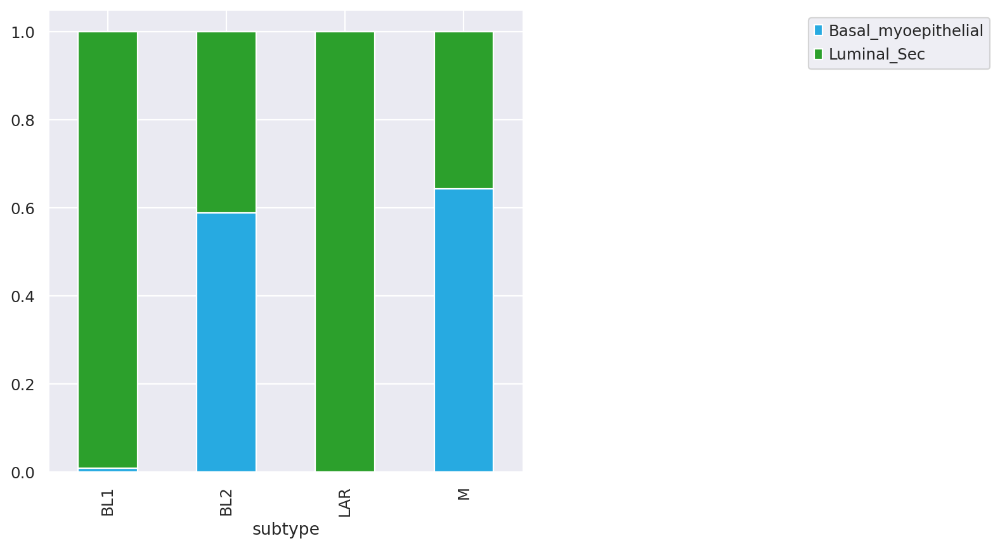

In [108]:
#wt=wk[~wk.obs['Group'].isin(["WKBR_MG"])]
tmp = pd.crosstab(wk.obs['cell_type_epi_individual'],wk.obs['subtype'], 
                  normalize='columns').T.plot(kind='bar', stacked=True,color=['#27AAE1','#2ca02c'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

#pl.savefig('subtype_by_celltype_stackedbar_plot.pdf', bbox_inches='tight')

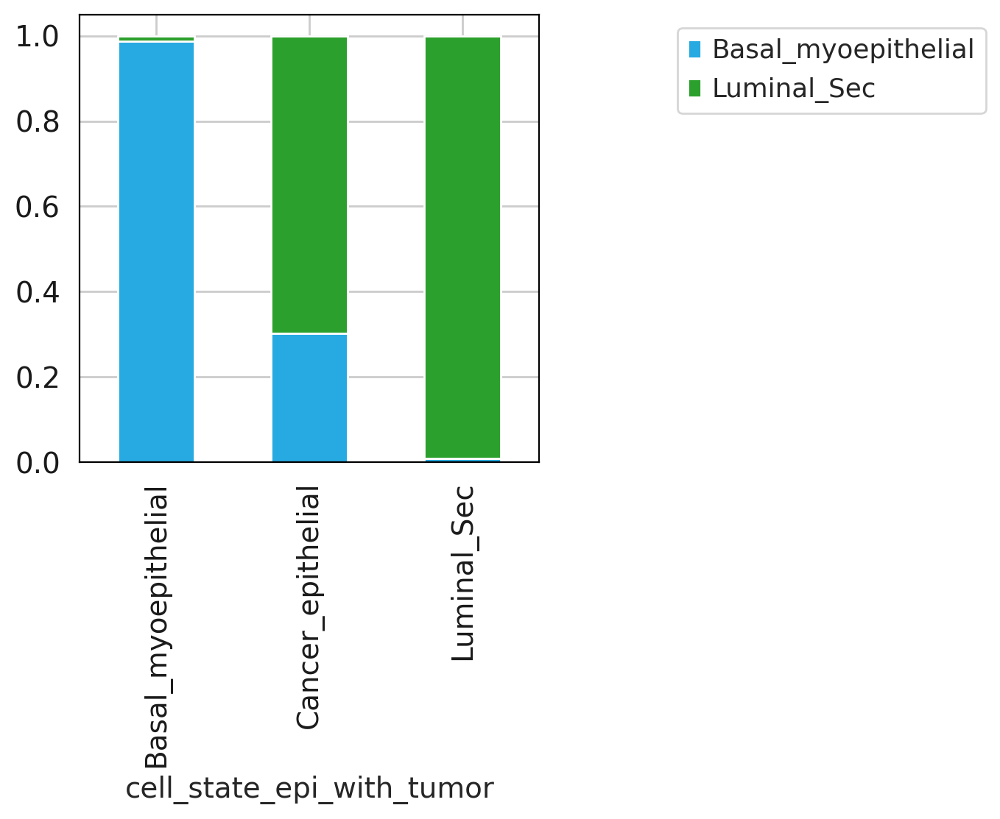

In [110]:
tmp = pd.crosstab(wk.obs['cell_state_epi_with_tumor'],wk.obs['cell_type_epi_individual'], 
                  normalize='columns')[["Basal_myoepithelial","Cancer_epithelial","Luminal_Sec"]].T.plot(kind='bar', stacked=True,color=['#27AAE1','#2ca02c'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('celltype_all_by_celltype_mut_stackedbar_plot.pdf', bbox_inches='tight')

In [94]:
pickle.dump(sub,
            open(os.path.join(work_dir, 'mut_tumor_like.pkl'), 'wb'))

In [13]:
pred = pd.read_csv("ctrl2ctrl3_asnorm_from_all_copykat_prediction.txt",sep='\t')

In [14]:
pred.set_index("cell.names", inplace=True)

In [15]:
wk.obs['cnv'] = pred['copykat.pred']

In [16]:
wk.obs['cnv'].value_counts()

cnv
diploid        14943
aneuploid       4391
not.defined       25
Name: count, dtype: int64

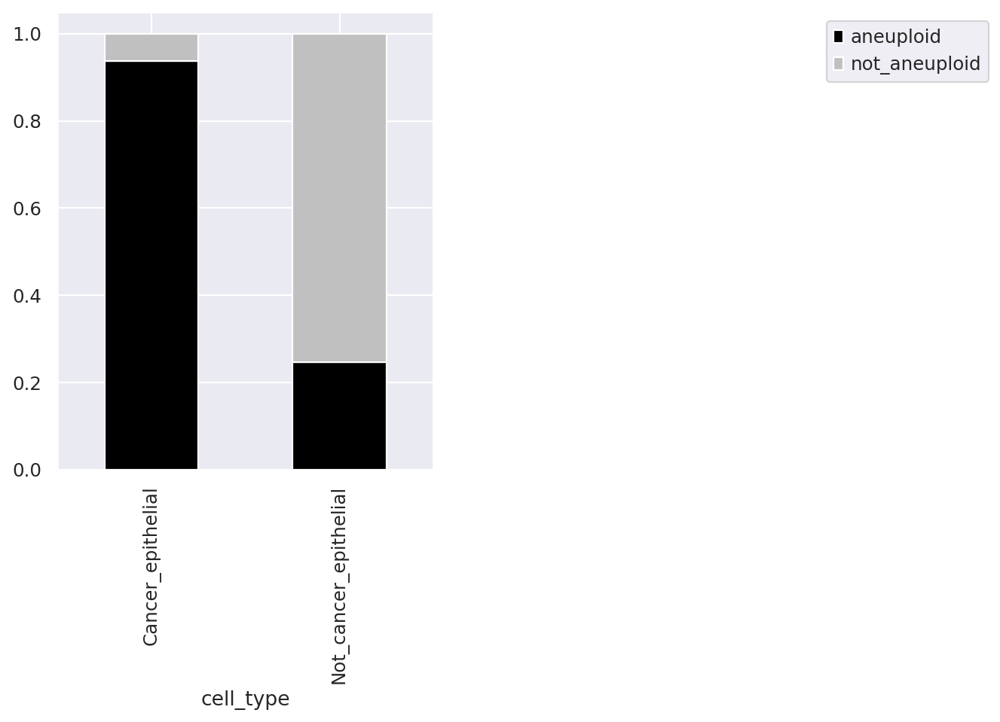

In [214]:
wk.obs['x1']=wk.obs['cnv_final'].copy()
wk.obs['x2']=wk.obs['cell_type'].copy()

no_facs=wk[wk.obs['Group'].isin(["WKBR_MG"])].copy()


no_facs.obs['cnv_final'] = (
    no_facs.obs["cnv"]
    .map(lambda x: {"not.defined": "not_aneuploid",
                    "diploid": "not_aneuploid"}.get(x, x))
    .astype("category")
)


no_facs.obs['cell_type'] = (
    no_facs.obs["cell_type"]
    .map(lambda x: {"Basal_myoepithelial": "Not_cancer_epithelial",
                   "Luminal_Sec": "Not_cancer_epithelial"}.get(x, x))
    .astype("category")
)

tmp = pd.crosstab(no_facs.obs['cnv_final'],no_facs.obs['cell_type'], 
                  normalize='columns').T.plot(kind='bar', stacked=True, color=['black','silver'])
tmp.legend(title='', bbox_to_anchor=(2.5, 1),loc='upper right')

#pl.rcParams["figure.figsize"] = (2,5)
pl.savefig('cnv_cancerlike_stackedbar_plot.pdf', bbox_inches='tight')

In [18]:
wk.obs['cnv_final'] = (
    wk.obs["cnv"]
    .map(lambda x: {"not.defined": "diploid",
                    "diploid": "diploid"}.get(x, x))
    .astype("category")
)

In [198]:
wk.obs['x1']=wk.obs['cnv'].copy()
wk.obs['x2']=wk.obs['cell_type'].copy()

wk.obs['x1'] = (
    wk.obs["x1"]
    .map(lambda x: {"aneuploid": "1",
                   "diploid": "0",
                   "not.defined": "0"}.get(x, x))
    .astype('int32')
)


wk.obs['x2'] = (
    wk.obs["x2"]
    .map(lambda x: {"Basal_myoepithelial": "0",
                   "Luminal_Sec": "0",
                   "Cancer_epithelial": "1"}.get(x, x))
    .astype('int32')
)


df=wk.obs
x1=df['x1'].to_list()
x2=df['x2'].to_list()

In [200]:
from scipy.stats import pearsonr, spearmanr, kendalltau

pearson_corr, _ = pearsonr(x2, x1)
spearman_corr, _ = spearmanr(x2, x1)
kendall_corr, _ = kendalltau(x2, x1)

correlation_coefficient, p_value = pearsonr(x1, x2)
print(f"Correlation coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

correlation_coefficient, p_value = spearmanr(x1, x2)
print(f"Correlation coefficient: {correlation_coefficient}")
print(f"P-value: {p_value}")

Correlation coefficient: 0.04880808267743976
P-value: 1.086114021917571e-11
Correlation coefficient: 0.048808082677439725
P-value: 1.0861140219176043e-11


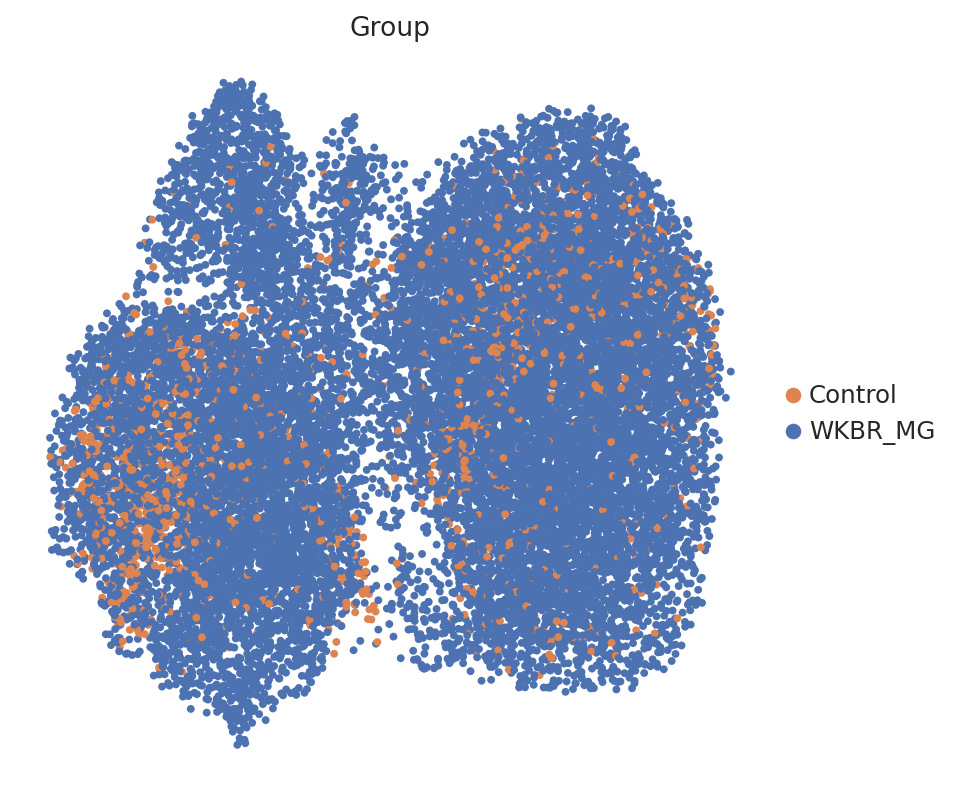

In [95]:
sc.pl.umap(
    wk,
    color=["Group"],
    wspace=0.5,palette=['#dd8451','#4c72b1'],
    size=50,save='_condition.pdf')

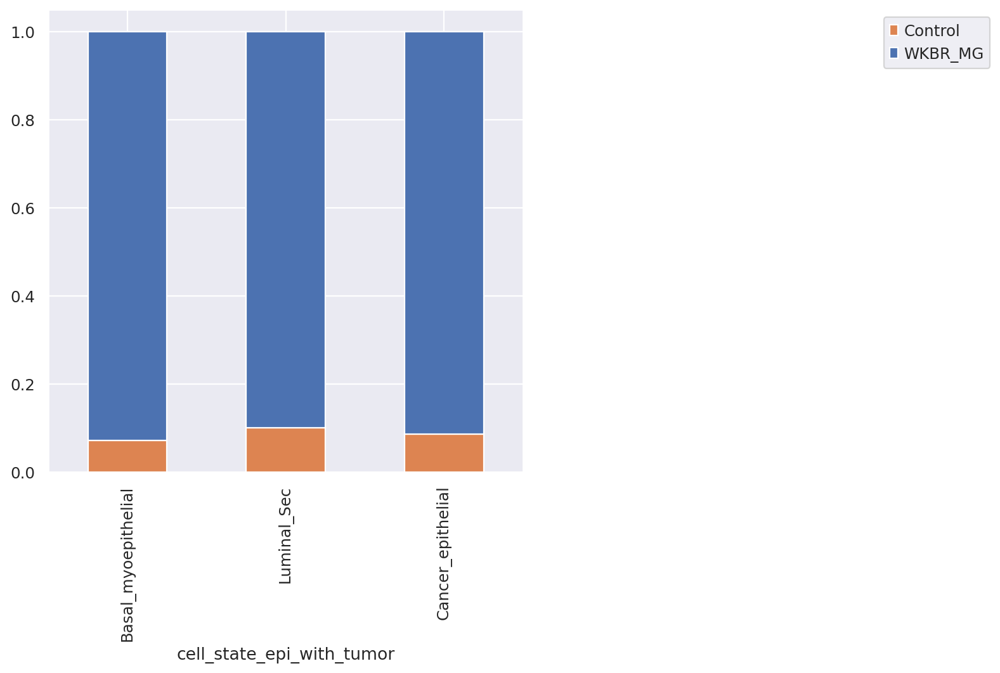

In [96]:
tmp = pd.crosstab(wk.obs['Group'],wk.obs['cell_state_epi_with_tumor'], 
                  normalize='columns').T.plot(kind='bar', stacked=True,color=['#dd8451','#4c72b1'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('condition_by_cellstate_with_tumor_stackedbar_plot.pdf', bbox_inches='tight')

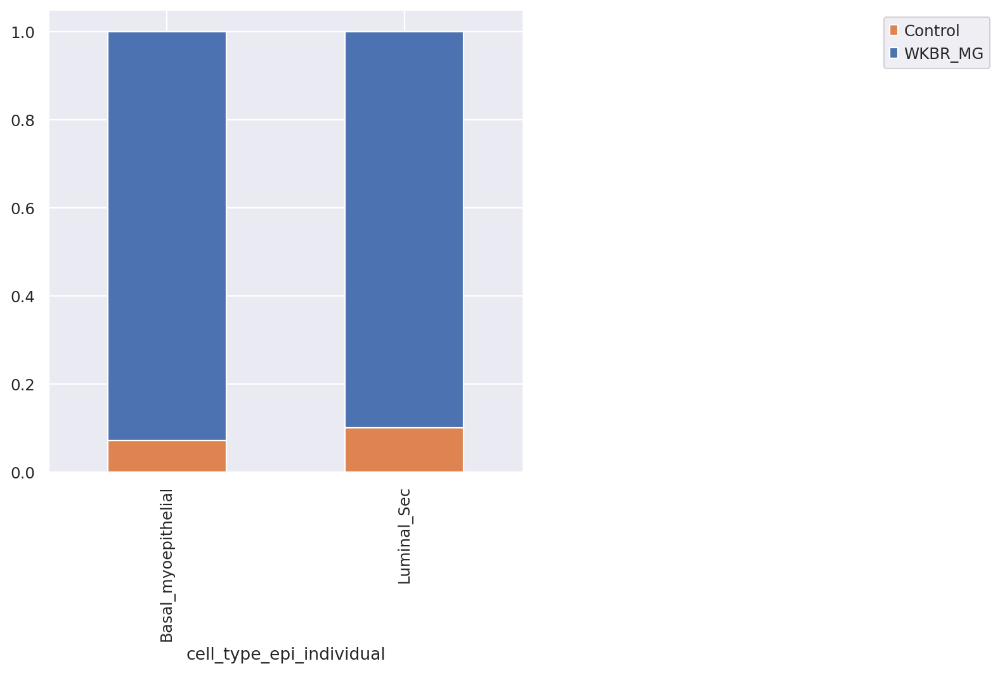

In [99]:
tmp = pd.crosstab(wk.obs['Group'],wk.obs['cell_type_epi_individual'], 
                  normalize='columns').T.plot(kind='bar', stacked=True,color=['#dd8451','#4c72b1'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('condition_all_by_celltype_stackedbar_plot.pdf', bbox_inches='tight')

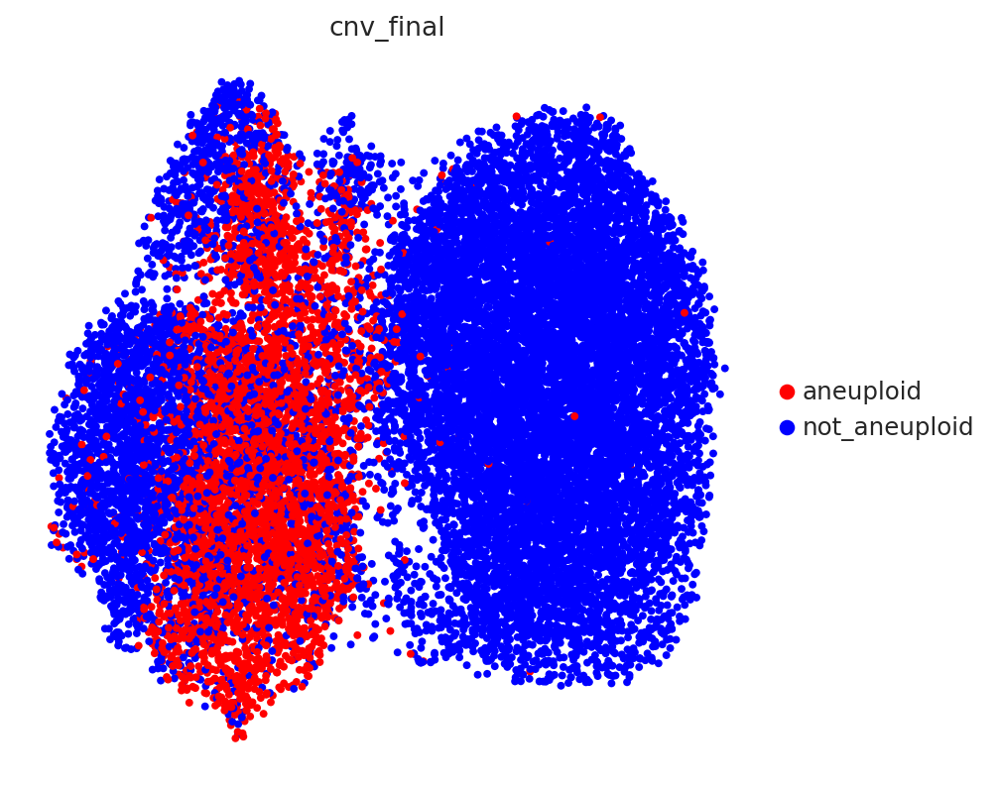

In [39]:
sc.pl.umap(
    wk,
    color=["cnv_final"],
    wspace=0.5,
    size=50,palette={'aneuploid':'red',
                    'not_aneuploid':'blue'})

In [41]:
wk.obs['SampleID'].value_counts()

SampleID
WKBR65.2f      3319
WKBR65.2g      2541
WKBR75.4bMG    1943
WKBR61.4dMG    1630
WKBR65.3h      1369
WKBR91.1f      1307
WKBR90.3g      1214
WKBR91.1e      1023
WKBR65.3g       962
CTRL_2          864
WKBR90.3i       821
WKBR76.4f       706
WKBR65.3i       569
CTRL_1          453
WKBR91.3j       325
CTRL_3          313
Name: count, dtype: int64

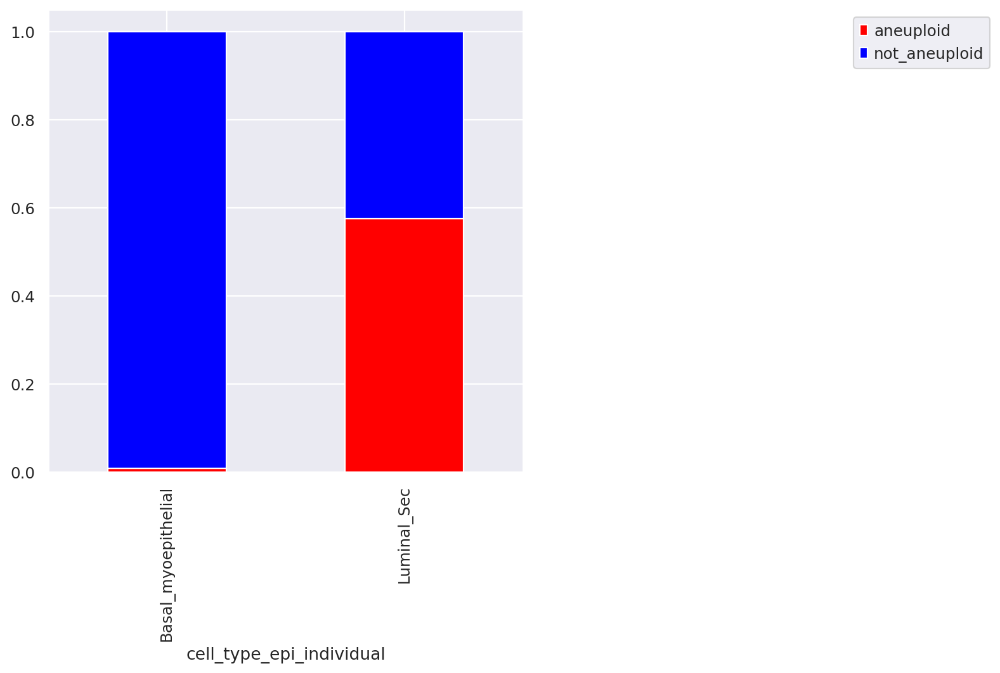

In [42]:
mut = wk[wk.obs['Group'].isin(['WKBR_MG'])]

tmp = pd.crosstab(mut.obs['cnv_final'],mut.obs['cell_type_epi_individual'], 
                  normalize='columns').reindex()[["Basal_myoepithelial","Luminal_Sec"]].T.plot(kind='bar', stacked=True, color=["red","blue"])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

#pl.savefig('celltype_by_cnv_stackedbar_plot.pdf', bbox_inches='tight')

In [77]:
mut.obs.columns

Index(['orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample',
       'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums',
       'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore',
       'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups',
       'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin',
       'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       '_scvi_batch', '_scvi_labels', 'leiden', 'scaled_combined_lumsec_basal',
       'subtype', 'p.value', 'correlation', 'subtype_tumor_only',
       'cell_type_epi_individual', 'highlight

In [218]:
mut = wk[wk.obs['Group'].isin(['WKBR_MG'])]
df=mut.obs.copy()
df['Match_aneu'] = (df['cnv_final'] == "aneuploid").astype(int)
category_match = df.groupby('cell_type')['Match_aneu'].mean() * 100
rep_match = df.groupby(['cell_type','SampleID'])['Match_aneu'].mean() * 100
rep_match=pd.DataFrame(rep_match)
rep_match
#print(category_match)

Match_aneu
cell_type           SampleID               
Basal_myoepithelial WKBR61.4dMG    2.127660
                    WKBR65.2f      0.662252
                    WKBR65.2g      0.175029
                    WKBR65.3g      0.000000
                    WKBR65.3h      0.414938
                    WKBR65.3i      2.380952
                    WKBR75.4bMG    0.769231
                    WKBR76.4f      0.923788
                    WKBR90.3g      0.315126
                    WKBR90.3i      0.000000
                    WKBR91.1e      0.267738
                    WKBR91.1f      0.179533
                    WKBR91.3j      0.000000
Cancer_epithelial   WKBR61.4dMG  100.000000
                    WKBR65.2f      0.000000
                    WKBR65.2g           NaN
                    WKBR65.3g           NaN
                    WKBR65.3h           NaN
                    WKBR65.3i           NaN
                    WKBR75.4bMG         NaN
                    WKBR76.4f    100.000000
                    WKBR90.3g           NaN
                    WKBR90.3i           NaN
                    WKBR91.1e           NaN
                    WKBR91.1f    100.000000
                    WKBR91.3j           NaN
Luminal_Sec         WKBR61.4dMG   83.570750
                    WKBR65.2f     61.752988
                    WKBR65.2g     49.939541
                    WKBR65.3g     32.971014
                    WKBR65.3h     38.271605
                    WKBR65.3i     74.094708
                    WKBR75.4bMG   68.448165
                    WKBR76.4f     76.102941
                    WKBR90.3g     39.694656
                    WKBR90.3i     13.765182
                    WKBR91.1e     43.478261
                    WKBR91.1f     15.104167
                    WKBR91.3j     14.765101

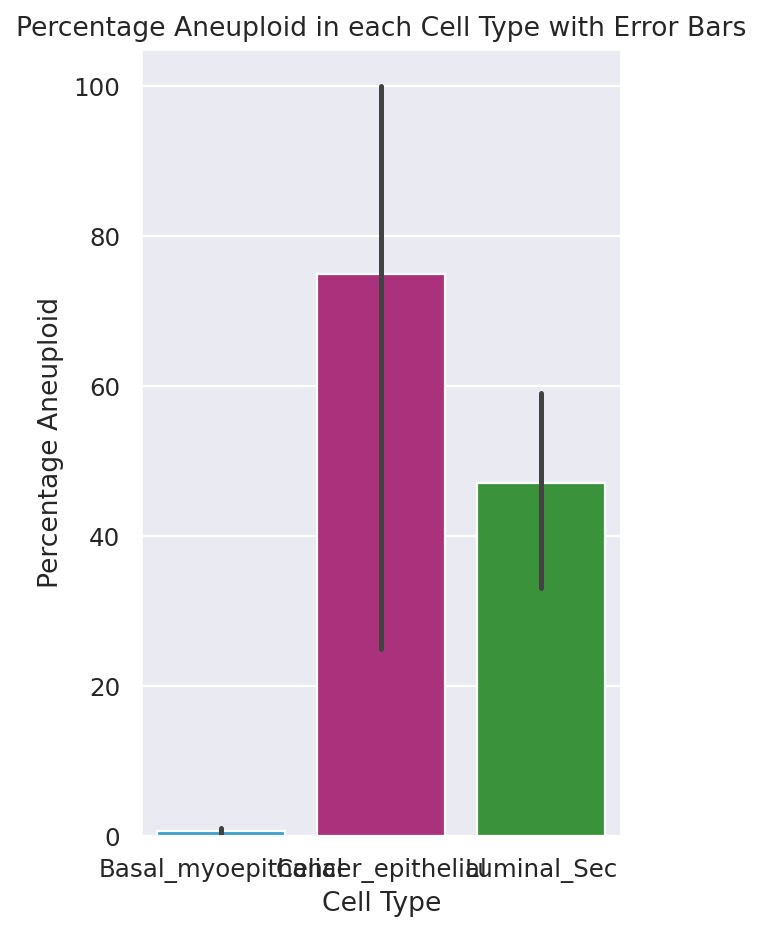

In [220]:
colors=['#27AAE1','#C11C82','#2ca02c']

plt.figure(figsize=(4, 6))
sns.barplot(x='cell_type', y='Match_aneu', data=rep_match, palette=colors)#, order=category_order)
plt.xlabel('Cell Type')
plt.ylabel('Percentage Aneuploid')
plt.title('Percentage Aneuploid in each Cell Type with Error Bars')
plt.tight_layout()
plt.savefig('percent_aneuploid_per_celltype.pdf', format='pdf')
plt.show()

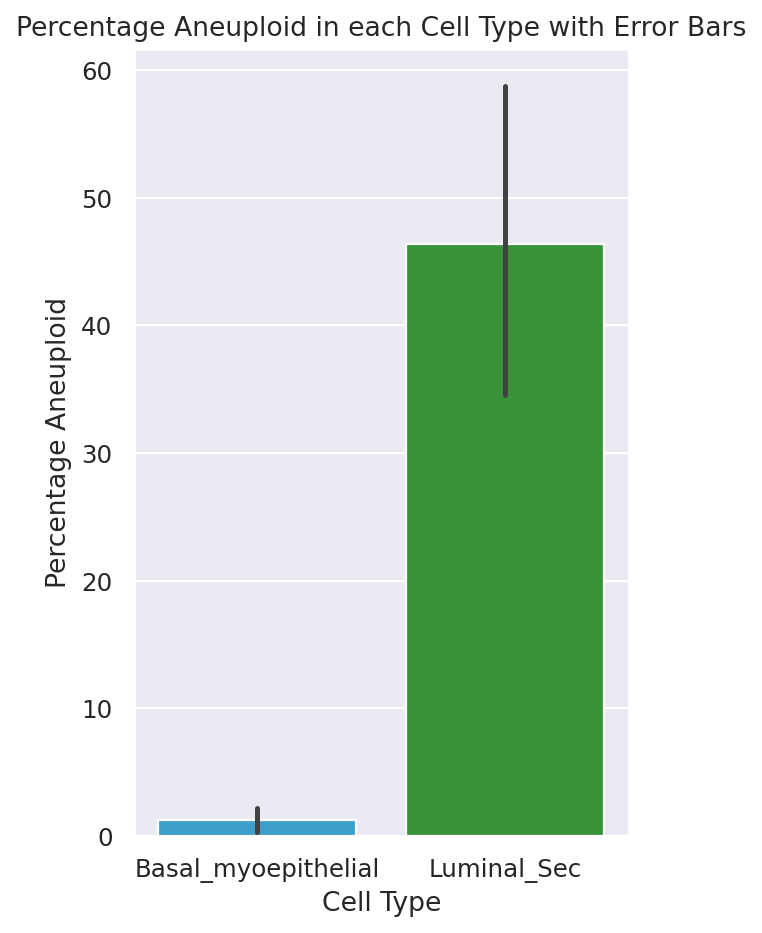

In [82]:
colors=['#27AAE1','#2ca02c']

plt.figure(figsize=(4, 6))
sns.barplot(x='cell_type_epi_individual', y='Match_aneu', data=rep_match, palette=colors)#, order=category_order)
plt.xlabel('Cell Type')
plt.ylabel('Percentage Aneuploid')
plt.title('Percentage Aneuploid in each Cell Type with Error Bars')
plt.tight_layout()
plt.savefig('percent_aneuploid_per_celltype.pdf', format='pdf')
plt.show()

In [215]:
df=wk.obs.copy()
df['Match_aneu'] = (df['cnv_final'] == "aneuploid").astype(int)
category_match = df.groupby('Group')['Match_aneu'].mean() * 100
rep_match = df.groupby(['Group','SampleID'])['Match_aneu'].mean() * 100
rep_match=pd.DataFrame(rep_match)
rep_match
#print(category_match)

Match_aneu
Group   SampleID               
Control CTRL_1         1.324503
        CTRL_2         0.231481
        CTRL_3         1.277955
        WKBR61.4dMG         NaN
        WKBR65.2f           NaN
        WKBR65.2g           NaN
        WKBR65.3g           NaN
        WKBR65.3h           NaN
        WKBR65.3i           NaN
        WKBR75.4bMG         NaN
        WKBR76.4f           NaN
        WKBR90.3g           NaN
        WKBR90.3i           NaN
        WKBR91.1e           NaN
        WKBR91.1f           NaN
        WKBR91.3j           NaN
WKBR_MG CTRL_1              NaN
        CTRL_2              NaN
        CTRL_3              NaN
        WKBR61.4dMG   55.521472
        WKBR65.2f     28.382043
        WKBR65.2g     16.371507
        WKBR65.3g      9.459459
        WKBR65.3h     11.614317
        WKBR65.3i     47.627417
        WKBR75.4bMG   54.863613
        WKBR76.4f     30.028329
        WKBR90.3g      8.813839
        WKBR90.3i      4.141291
        WKBR91.1e     11.925709
        WKBR91.1f      2.448355
        WKBR91.3j      6.769231

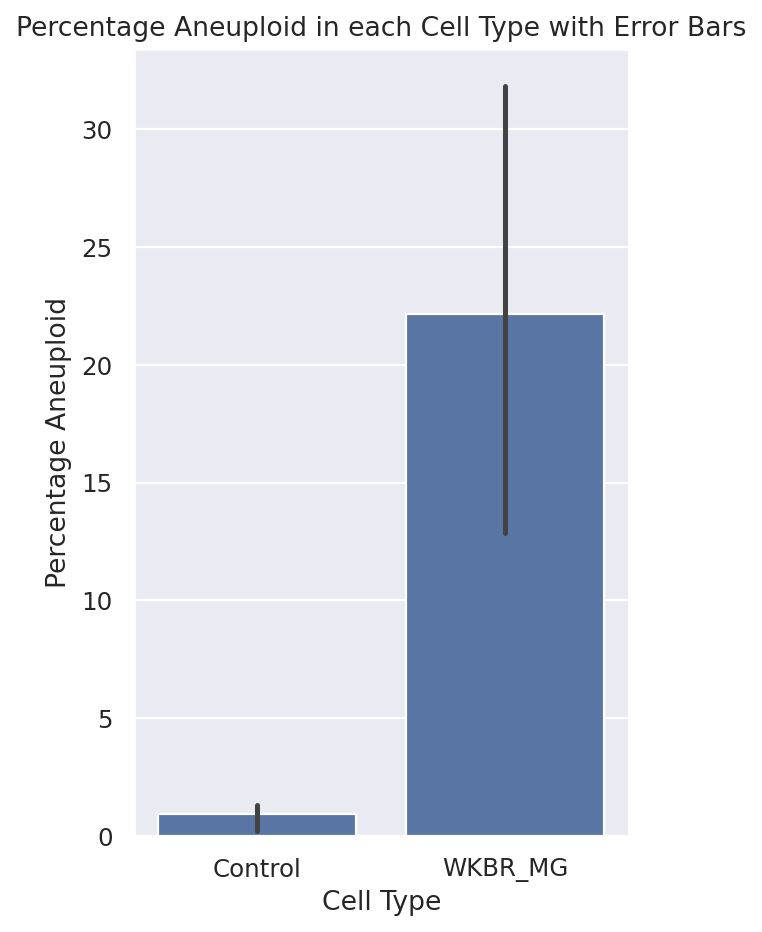

In [216]:
#colors=['#27AAE1','#2ca02c']

plt.figure(figsize=(4, 6))
sns.barplot(x='Group', y='Match_aneu', data=rep_match)#, palette=colors)#, order=category_order)
plt.xlabel('Cell Type')
plt.ylabel('Percentage Aneuploid')
plt.title('Percentage Aneuploid in each Cell Type with Error Bars')
plt.tight_layout()
plt.savefig('percent_aneuploid_per_celltype.pdf', format='pdf')
plt.show()

In [100]:
df=mut.obs.copy()
df['Match_aneu'] = (df['cnv_final'] == "aneuploid").astype(int)
category_match = df.groupby('cell_state_epi_with_tumor')['Match_aneu'].mean() * 100
rep_match = df.groupby(['cell_state_epi_with_tumor','SampleID'])['Match_aneu'].mean() * 100
rep_match=pd.DataFrame(rep_match)
rep_match
#print(category_match)

Match_aneu
cell_state_epi_with_tumor SampleID               
Basal_myoepithelial       WKBR61.4dMG    3.157895
                          WKBR65.2f      0.611111
                          WKBR65.2g      0.175850
                          WKBR65.3g      0.145773
                          WKBR65.3h      0.316456
                          WKBR65.3i      3.301887
                          WKBR75.4bMG    3.482587
                          WKBR76.4f      0.919540
                          WKBR90.3g      0.317460
                          WKBR90.3i      0.000000
                          WKBR91.1e      0.134771
                          WKBR91.1f      0.269542
                          WKBR91.3j      0.000000
Luminal_Sec               WKBR61.4dMG   83.634634
                          WKBR65.2f     61.290323
                          WKBR65.2g     49.461078
                          WKBR65.3g     32.608696
                          WKBR65.3h     37.054632
                          WKBR65.3i     74.157303
                          WKBR75.4bMG   69.022457
                          WKBR76.4f     77.735849
                          WKBR90.3g     39.080460
                          WKBR90.3i     13.709677
                          WKBR91.1e     43.214286
                          WKBR91.1f     15.025907
                          WKBR91.3j     14.765101
Cancer_epithelial         WKBR61.4dMG   88.888889
                          WKBR65.2f           NaN
                          WKBR65.2g           NaN
                          WKBR65.3g           NaN
                          WKBR65.3h           NaN
                          WKBR65.3i      0.000000
                          WKBR75.4bMG   25.925926
                          WKBR76.4f     33.333333
                          WKBR90.3g     25.000000
                          WKBR90.3i           NaN
                          WKBR91.1e      0.000000
                          WKBR91.1f      0.000000
                          WKBR91.3j           NaN

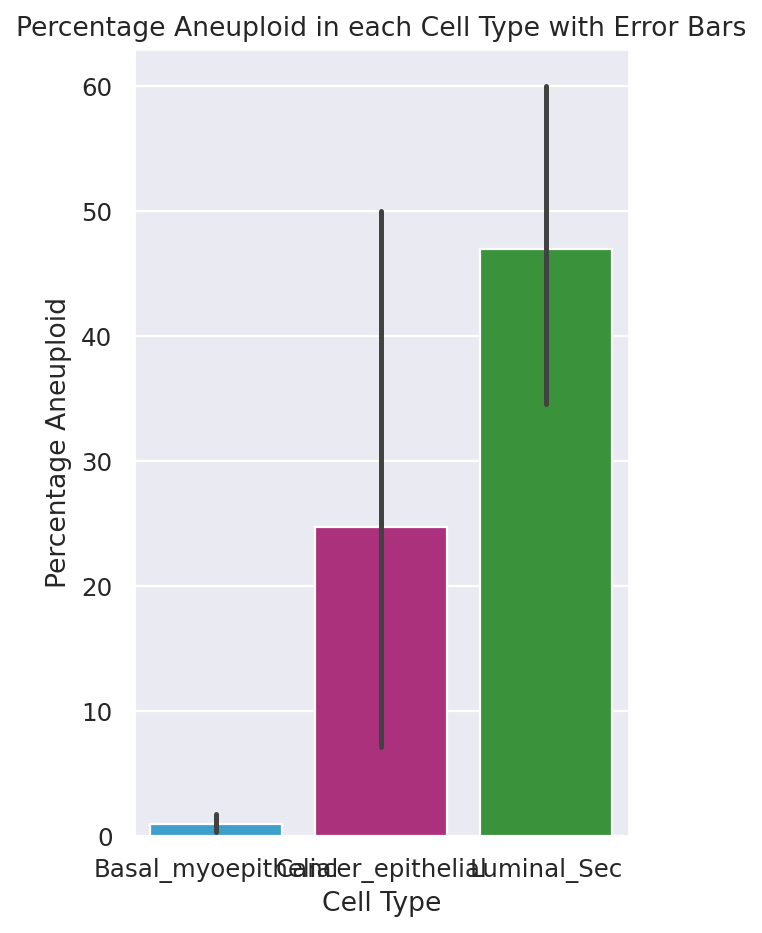

In [103]:
colors=['#27AAE1','#C11C82','#2ca02c']
category_order=["Basal_myoepithelial","Cancer_epithelial","Luminal_Sec"]

plt.figure(figsize=(4, 6))
sns.barplot(x='cell_state_epi_with_tumor', y='Match_aneu', data=rep_match, palette=colors, order=category_order)
plt.xlabel('Cell Type')
plt.ylabel('Percentage Aneuploid')
plt.title('Percentage Aneuploid in each Cell Type with Error Bars')
plt.tight_layout()
plt.savefig('percent_aneuploid_per_celltype.pdf', format='pdf')
plt.show()

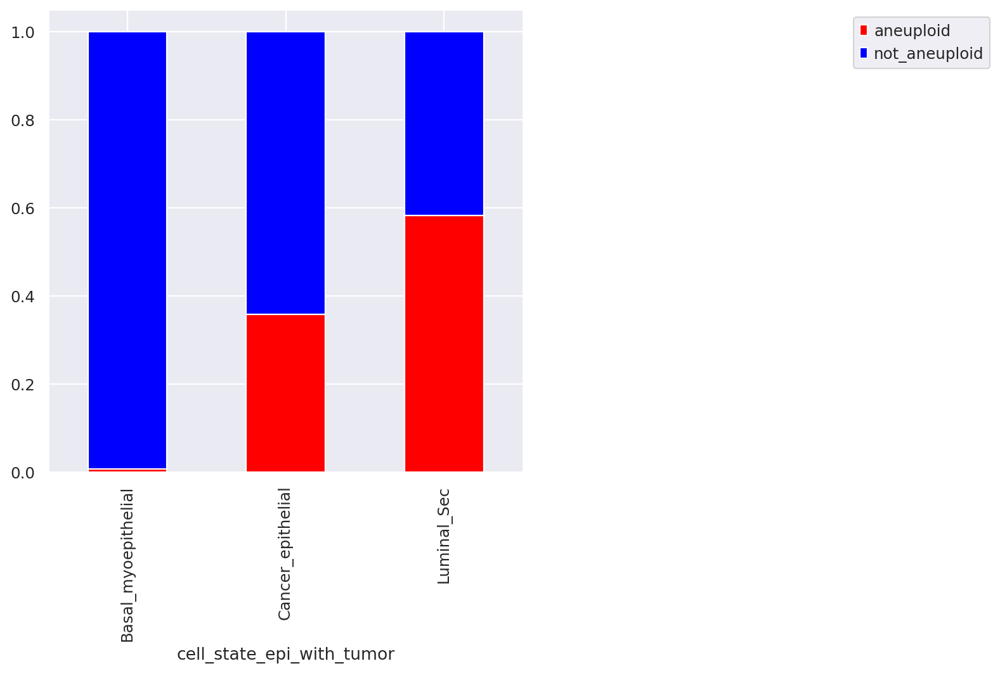

In [43]:
#mut = wk[wk.obs['cnv'].isin(['aneuploid', 'diploid', 'not.defined'])]

tmp = pd.crosstab(mut.obs['cnv_final'],mut.obs['cell_state_epi_with_tumor'], 
                  normalize='columns').reindex()[["Basal_myoepithelial","Cancer_epithelial","Luminal_Sec"]].T.plot(kind='bar', stacked=True, color=["red","blue"])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

#pl.savefig('celltype_by_cnv_stackedbar_plot.pdf', bbox_inches='tight')

In [14]:
res1 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_singlecell.csv")

In [19]:
res1 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_singlecell.csv")

res1 = res1[res1['Unnamed: 0'].str.startswith('wk')]
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('wk_', '')
res1['Unnamed: 0'] = res1['Unnamed: 0'].str.replace('.', '-')

res1.set_index("Unnamed: 0", inplace=True)



res2 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_mouse_single_cell_lumhr_noESR.csv")

res2 = res2[res2['Unnamed: 0'].str.startswith('wk')]
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('wk_', '')
res2['Unnamed: 0'] = res2['Unnamed: 0'].str.replace('.', '-')

res2.set_index("Unnamed: 0", inplace=True)



res3 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_mouse_single_cell_normal_epithelial_without_lumhr.csv")

res3 = res3[res3['Unnamed: 0'].str.startswith('wk')]
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('wk_', '')
res3['Unnamed: 0'] = res3['Unnamed: 0'].str.replace('.', '-')

res3.set_index("Unnamed: 0", inplace=True)



res4 = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/TNBC_subtyper/result_singlecell_basal_lumsec.csv")

res4 = res4[res4['Unnamed: 0'].str.startswith('wk')]
res4['Unnamed: 0'] = res4['Unnamed: 0'].str.replace('wk_', '')
res4['Unnamed: 0'] = res4['Unnamed: 0'].str.replace('.', '-')

res4.set_index("Unnamed: 0", inplace=True)



res = pd.concat([res1, res2, res3, res4], axis=0)

In [20]:
res4.shape

(0, 9)

In [21]:
wk.obs['subtype'] = res['subtype']

In [142]:
tum = wk[wk.obs['cell_state_epi_with_tumor'].isin(['Cancer_epithelial'])]

In [143]:
bc = tum.obs_names
new_res = res[res.index.isin(bc)]

In [144]:
wk.obs['subtype_tumor_only'] = new_res['subtype']

In [145]:
categories = np.array(
     ['BL1', 'BL2', 'LAR', 'M', 'UNS', 'not_typed'])

wk.obs['subtype_tumor_only'] = pd.Categorical(
   wk.obs['subtype_tumor_only'], categories=categories, ordered=True)

wk.obs['subtype_tumor_only'].fillna("not_typed", inplace=True)

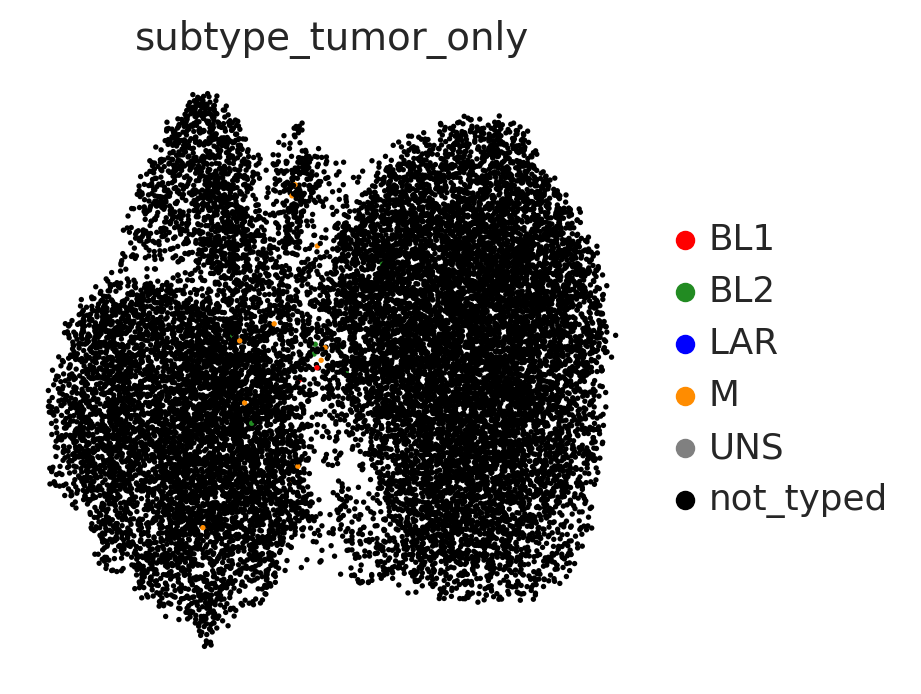

In [146]:
sc.pl.umap(wk, color=["subtype_tumor_only"], palette = {'BL1':'red',
                                                'BL2':'forestgreen',
                                                'LAR':'blue',
                                               'M':'darkorange',
                                               'UNS':'grey',
                                            'not_typed':'black'},
          s = 15)

In [148]:
sub.obs['subtype_tumor_only'].value_counts()

subtype_tumor_only
not_typed    19337
M               12
BL2              7
BL1              3
LAR              0
UNS              0
Name: count, dtype: int64

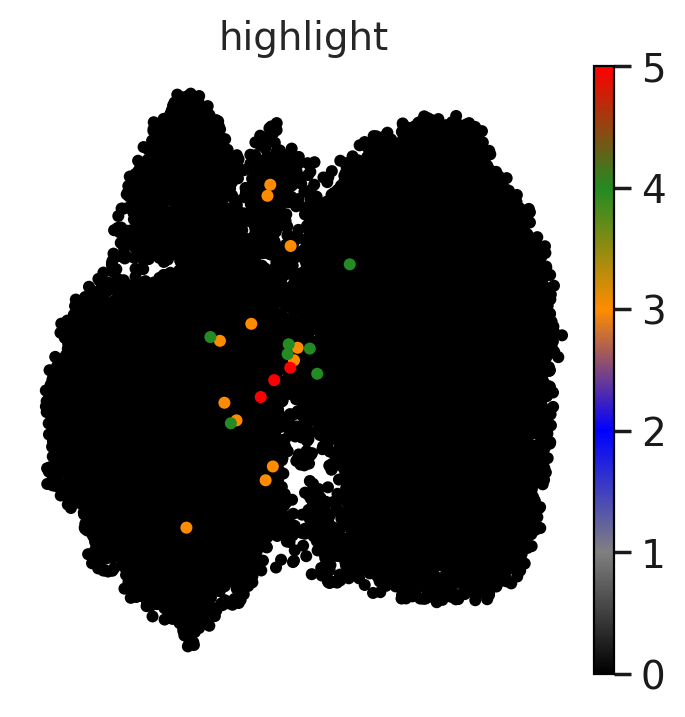

In [147]:
sub = wk
sub.obs['highlight'] = sub.obs['subtype_tumor_only']

sub.obs['highlight'] = (
    sub.obs["highlight"]
    .map(lambda x: {"BL1":"5",
                    "BL2": "4",
                   "LAR": "2",
                    "M":"3",
                   "UNS": "1",
                   "not_typed": "0"}.get(x, x))
    .astype('int32')
)

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["black","grey","blue","darkorange","forestgreen","red"])

sc.pl.umap(sub, color='highlight', cmap = cmap, size=75)

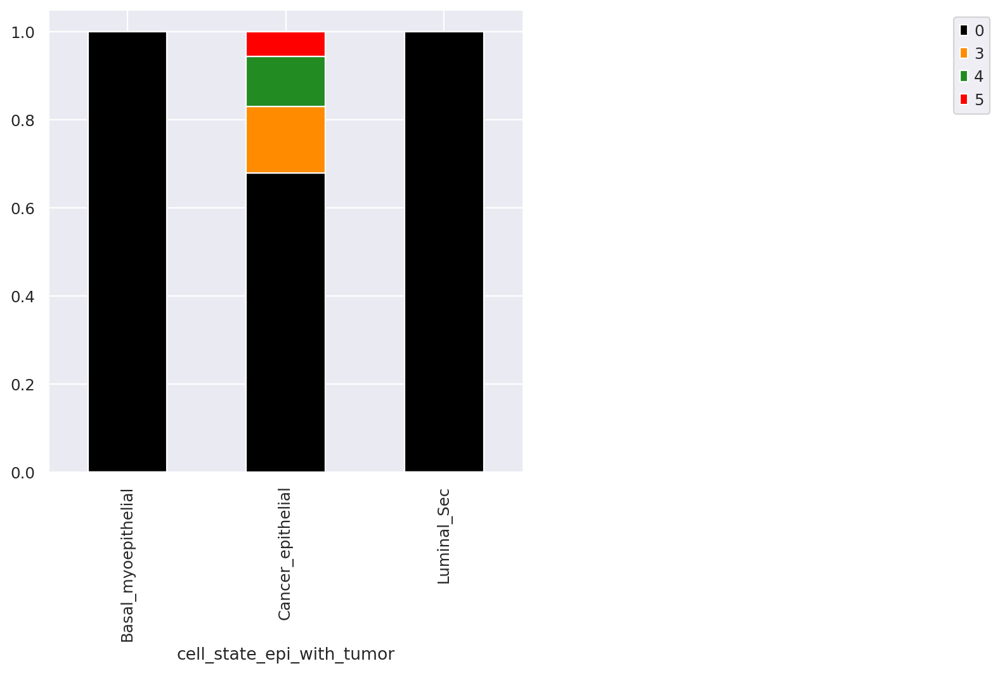

In [117]:
tmp = pd.crosstab(sub.obs['highlight'],sub.obs['cell_state_epi_with_tumor'], 
                  normalize='columns').reindex()[["Basal_myoepithelial","Cancer_epithelial","Luminal_Sec"]].T.plot(kind='bar', stacked=True,color=['black','darkorange','forestgreen','red'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('celltype_all_by_subtype_tumorlike_stackedbar_plot.pdf', bbox_inches='tight')

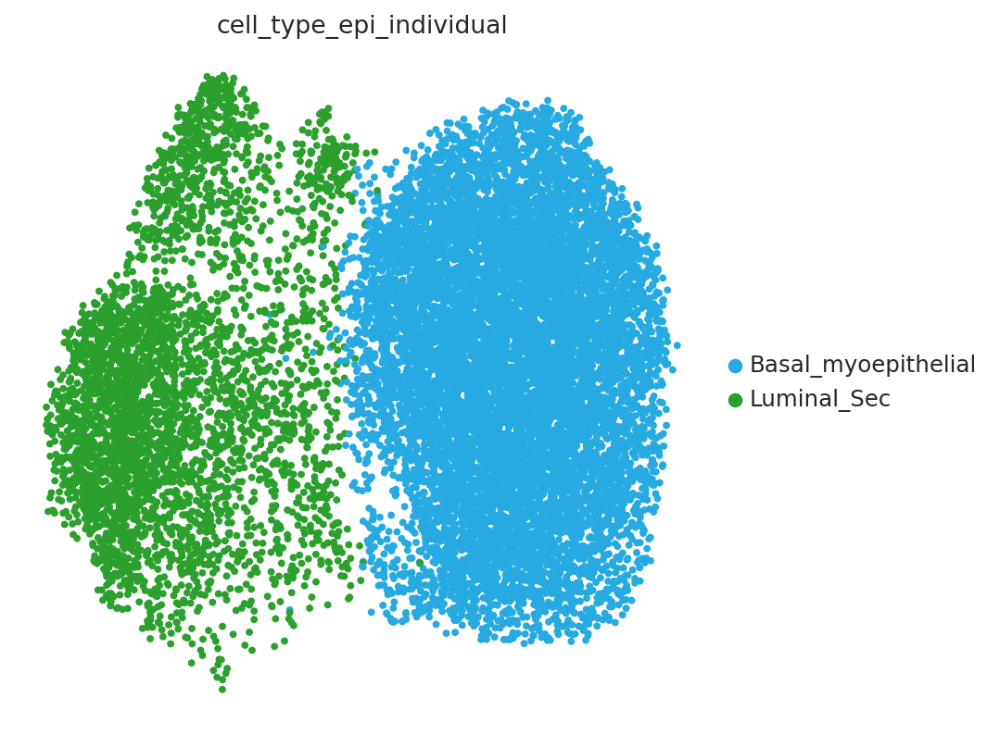

In [65]:
sc.pl.umap(not_mutant_cnv, color='cell_type_epi_individual',size=50)

In [18]:
not_mutant_cnv=wk[~wk.obs['cnv'].isin(['aneuploid'])]
not_mutant_cnv

View of AnnData object with n_obs × n_vars = 14968 × 703
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums', 'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore', 'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups', 'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin', 'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', 'scaled_combined_lumsec_basal', 'subtype', 'p.value', 'correlation', 'subtype_tumor_only', 'cell_type_epi_individual', 'highlight', 'cnv'
    var: 'n_cells', 'mc

In [19]:
not_mutant_cnv.obs['Group'].value_counts()

Group
WKBR_MG    13350
Control     1618
Name: count, dtype: int64

In [24]:
not_mutant_cnv.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cell_type_epi_individual']

wk.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cnv_or_cell_type']

categories = np.array(
     ['Basal_myoepithelial', 'Aneuploid', 'Luminal_Sec'])

wk.obs['cnv_or_cell_type'] = pd.Categorical(
   wk.obs['cnv_or_cell_type'], categories=categories, ordered=True)

wk.obs['cnv_or_cell_type'].fillna("Aneuploid", inplace=True,)

/tmp/ipykernel_3659643/136945095.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  not_mutant_cnv.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cell_type_epi_individual']


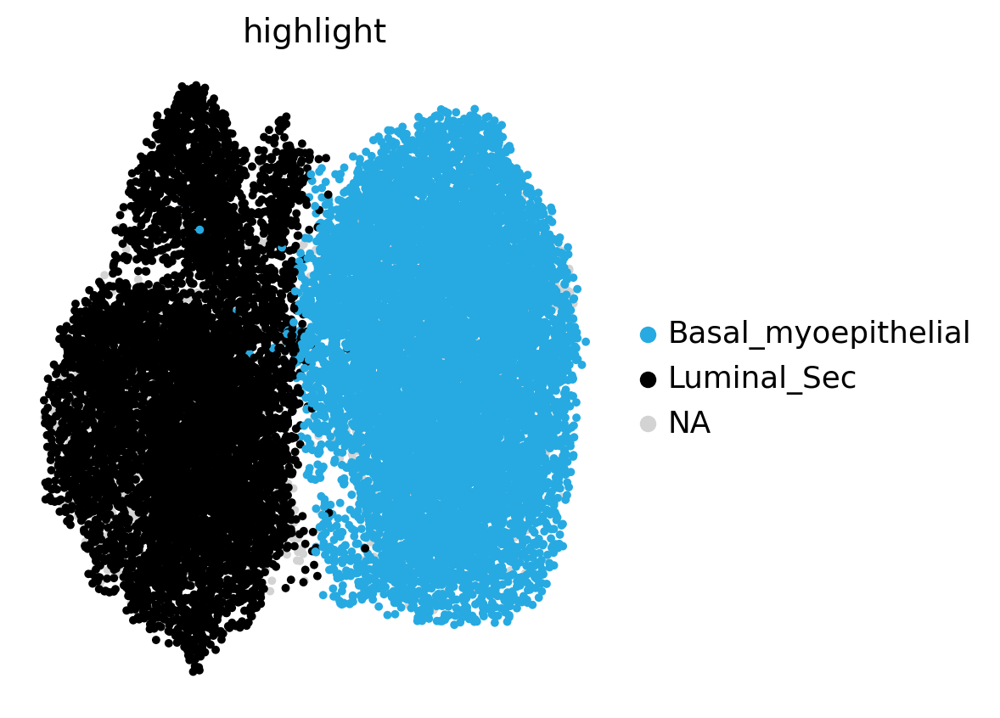

In [25]:
highlight=wk[wk.obs['Group'].isin(['WKBR_MG'])]
wk.obs['highlight'] = highlight.obs['cnv_or_cell_type']

pl.rcParams["figure.figsize"] = (4.5,5)
#plt.figure(figsize=(4.5, 5))

sc.pl.umap(wk, color='highlight',size=50,palette=['#27AAE1','black','#2ca02c'])



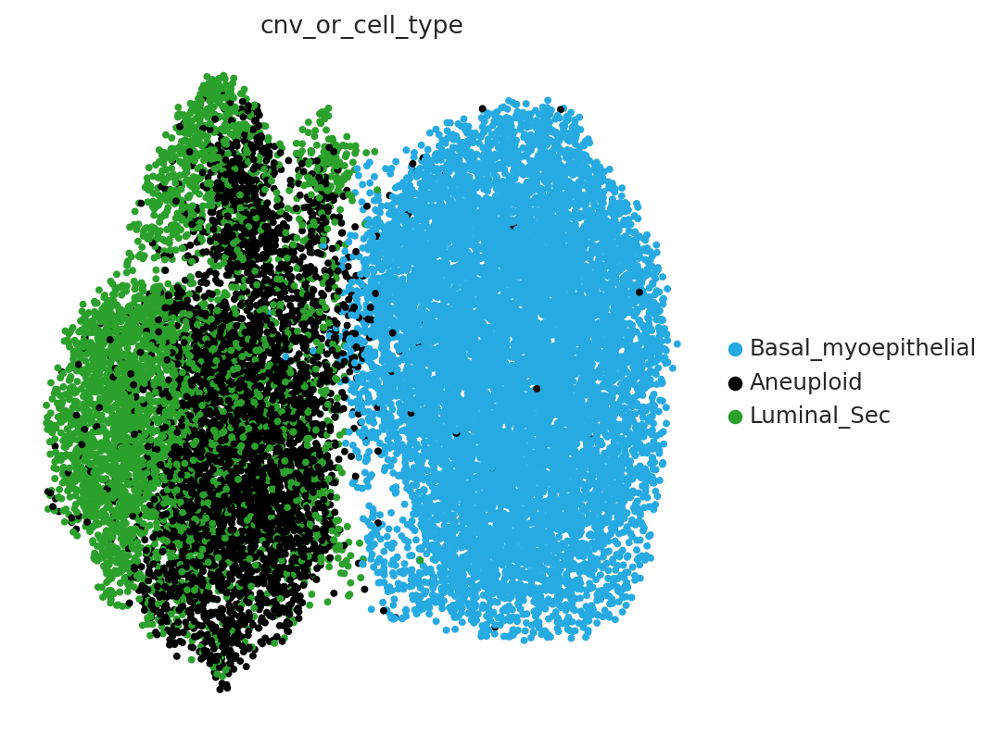

In [118]:
sc.pl.umap(wk, color='cnv_or_cell_type',size=50,palette=['#27AAE1','black','#2ca02c'],save='_cnv_or_celltype.pdf')

In [30]:
wk.obs.columns

Index(['orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample',
       'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums',
       'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore',
       'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups',
       'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin',
       'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       '_scvi_batch', '_scvi_labels', 'leiden', 'scaled_combined_lumsec_basal',
       'subtype', 'p.value', 'correlation', 'subtype_tumor_only',
       'cell_type_epi_individual', 'highlight

In [34]:
pd.crosstab(wk.obs['cnv'],wk.obs['cell_state_epi_with_tumor'])

cell_state_epi_with_tumor,Basal_myoepithelial,Luminal_Sec,Cancer_epithelial
cnv,,,
aneuploid,72,4300,19
diploid,11028,3878,37
not.defined,10,13,2


In [15]:
mut=wk[wk.obs['Group'].isin(['WKBR_MG'])]

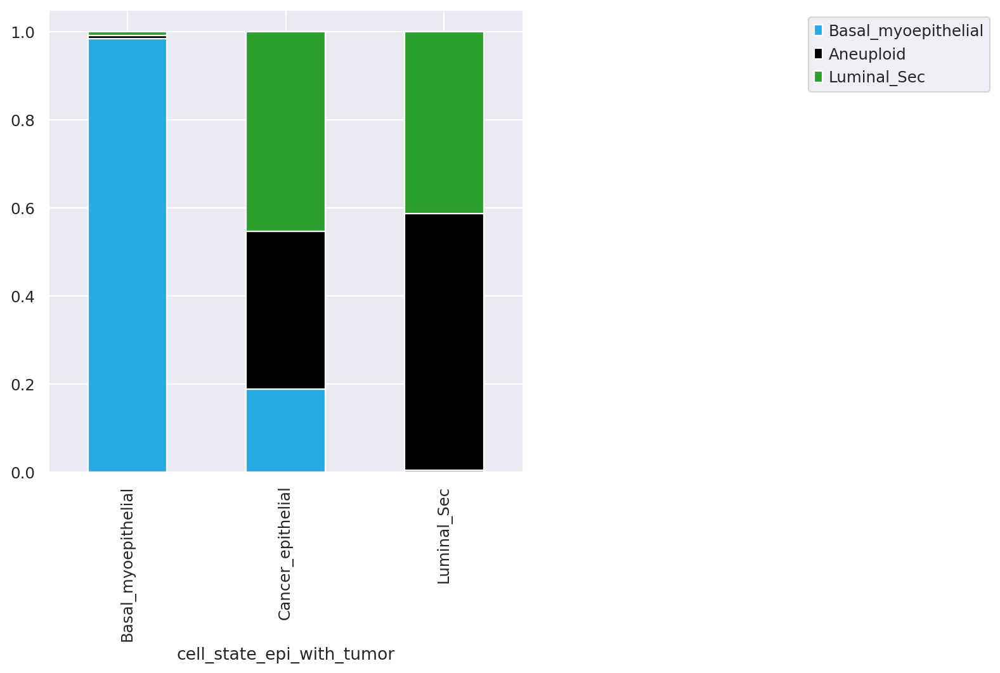

In [120]:
tmp = pd.crosstab(mut.obs['cnv_or_cell_type'],mut.obs['cell_state_epi_with_tumor'], 
                  normalize='columns').reindex()[["Basal_myoepithelial","Cancer_epithelial","Luminal_Sec"]].T.plot(kind='bar', stacked=True,
                                                                                                                  color=['#27AAE1','black','#2ca02c'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('celltype_with_tumor_by_cnv_stackedbar_plot.pdf', bbox_inches='tight')

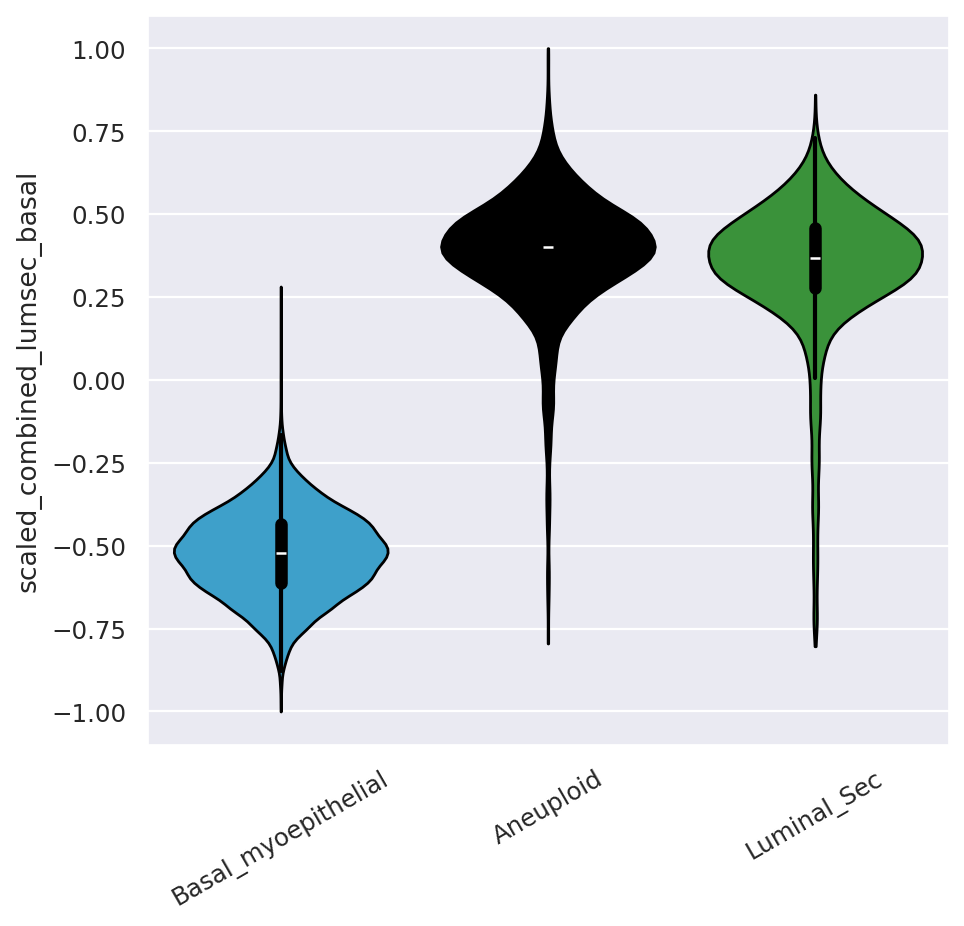

In [ ]:
#mut = wk[wk.obs['Group'].isin(['WKBR_MG'])]
sc.pl.violin(wk, ["scaled_combined_lumsec_basal"], groupby="cnv_or_cell_type", 
             rotation=30, palette = {'Basal_myoepithelial':'#27AAE1','Aneuploid':'black','Luminal_Sec':'#2ca02c'},
             stripplot=False,order=['Basal_myoepithelial','Aneuploid','Luminal_Sec'],
             inner='box',save='violin_scaled_combined_cnv_or_cell_type.pdf')

In [ ]:
sc.pl.violin(wk, ["scaled_combined_lumsec_basal"], groupby="cnv_or_cell_type", 
             rotation=30, palette = {'Basal_myoepithelial':'#27AAE1','aneuploid':'black','Luminal_Sec':'#2ca02c'},
             stripplot=False,order=['Basal_myoepithelial','aneuploid','Luminal_Sec'],
             inner='box',save='violin_scaled_combined_cnv_or_cell_type.pdf')

In [17]:
scanvi_labels = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/ref_map_waps_together/metadata_full_scanvi.csv", 
                            index_col=0)

/tmp/ipykernel_2036729/3959796683.py:1: DtypeWarning: Columns (27,28,29,30) have mixed types. Specify dtype option on import or set low_memory=False.
  scanvi_labels = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/ref_map_waps_together/metadata_full_scanvi.csv",


In [18]:
scanvi_labels=scanvi_labels[scanvi_labels['dataset'].isin(['blg_cre'])]

In [19]:
mut.obs['scanvi_cell']=scanvi_labels['integrated_cell']

/tmp/ipykernel_2036729/2129935499.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  mut.obs['scanvi_cell']=scanvi_labels['integrated_cell']


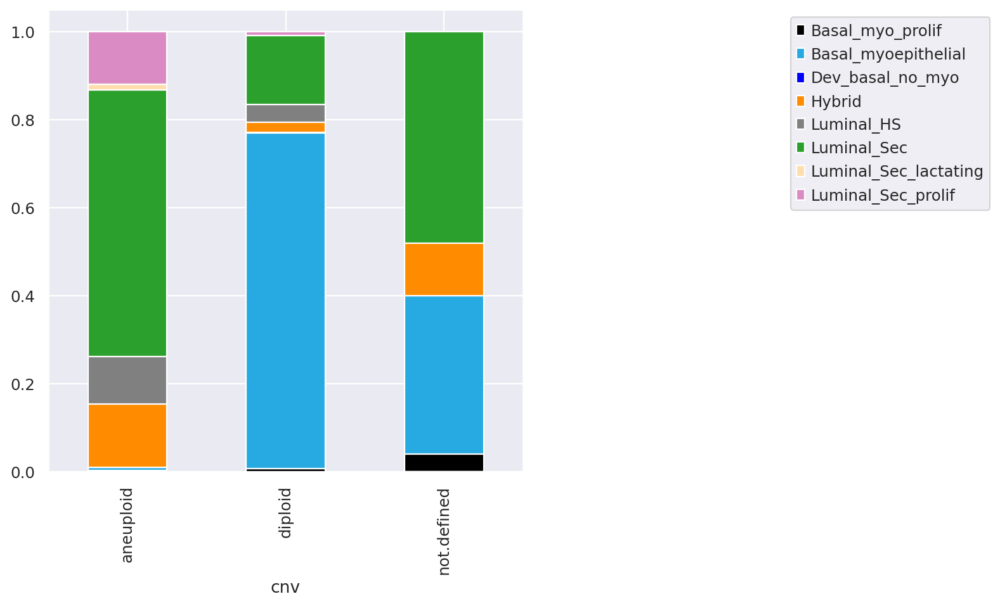

In [22]:
tmp = pd.crosstab(mut.obs['scanvi_cell'],mut.obs['cnv'], 
                  normalize='columns').reindex().T.plot(kind='bar', stacked=True,
                                                                                                           color=['black','#27AAE1','blue','darkorange','grey','#2ca02c','navajowhite','#da8bc3'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

In [20]:
aneuploid=mut[mut.obs['cnv'].isin(['aneuploid'])]

NameError: name 'mut' is not defined

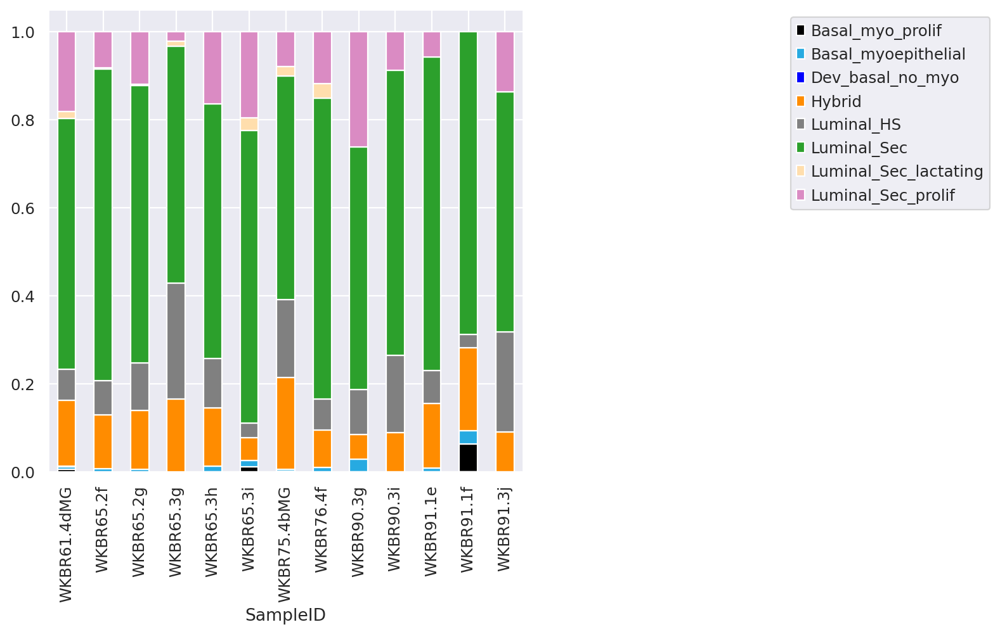

In [25]:
tmp = pd.crosstab(aneuploid.obs['scanvi_cell'],aneuploid.obs['SampleID'], 
                  normalize='columns').reindex().T.plot(kind='bar', stacked=True,
                                                        color=['black','#27AAE1','blue','darkorange','grey','#2ca02c','navajowhite','#da8bc3'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

In [26]:
aneuploid.obs['SampleID'].value_counts()

SampleID
WKBR75.4bMG    1066
WKBR65.2f       942
WKBR61.4dMG     905
WKBR65.2g       416
WKBR65.3i       271
WKBR76.4f       212
WKBR65.3h       159
WKBR91.1e       122
WKBR90.3g       107
WKBR65.3g        91
WKBR90.3i        34
WKBR91.1f        32
WKBR91.3j        22
Name: count, dtype: int64

/opt/apps/python/3.10.2/lib/python3.10/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


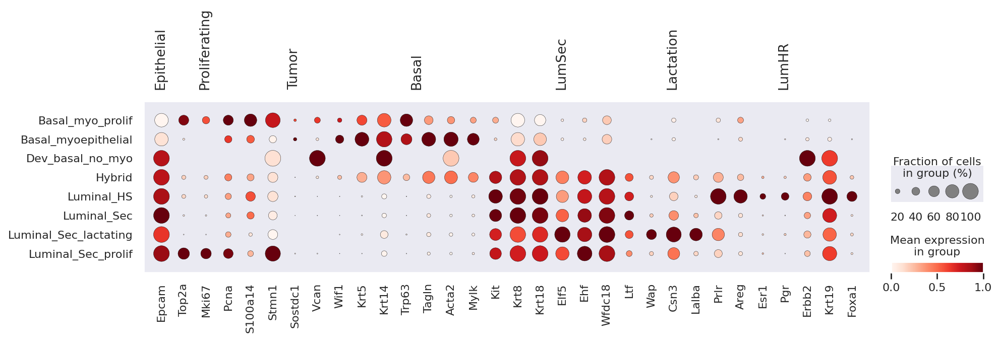

In [27]:
marker_genes = {
    "Epithelial": ["Epcam"],
    "Proliferating": ["Top2a", "Mki67","Pcna"],
    "Tumor": ["S100a14","Stmn1","Sostdc1","Vcan","Wif1"],
    "Basal": ["Krt5", "Krt14", "Trp63", "Tagln", "Acta2", "Mylk"],
    "LumSec": ["Kit", "Krt8", "Krt18","Elf5","Ehf","Wfdc18","Ltf"],
    "Lactation": ["Wap","Csn3","Lalba"],
    "LumHR": ["Prlr", "Areg", "Esr1", "Pgr", "Erbb2", "Krt19","Foxa1"]
}

sc.pl.dotplot(aneuploid, marker_genes, groupby="scanvi_cell", standard_scale="var")

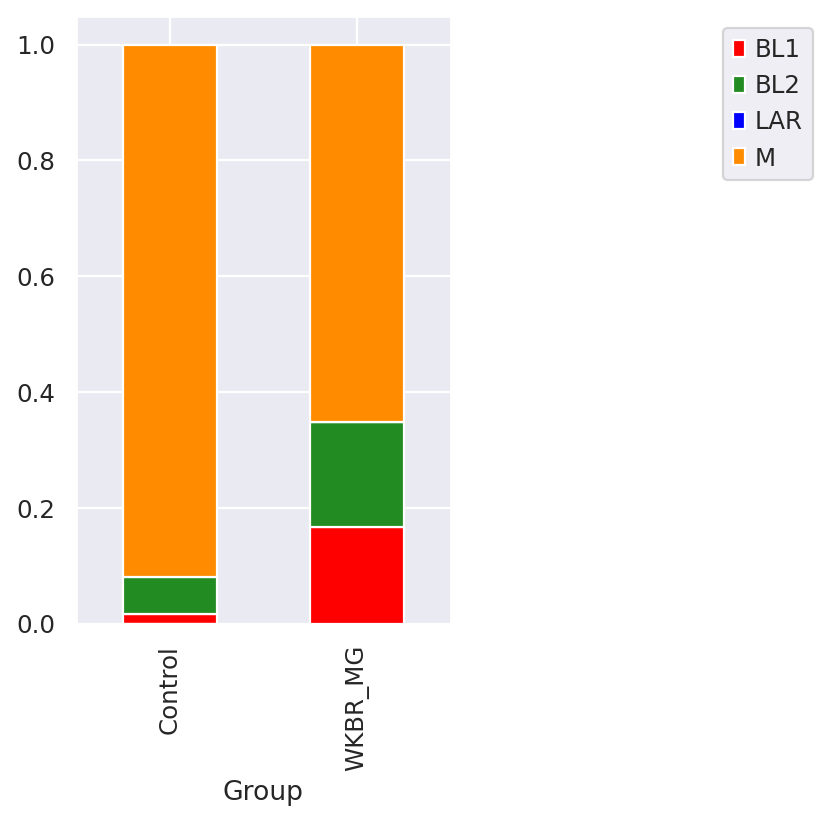

In [119]:
pl.rcParams["figure.figsize"] = (3,5)

tmp = pd.crosstab(wk.obs['subtype'],wk.obs['Group'], 
                  normalize='columns').reindex().T.plot(kind='bar', stacked=True,
                                                        color=['red','forestgreen','blue','darkorange'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('condition_by_subtype_stackedbar_plot.pdf', bbox_inches='tight')

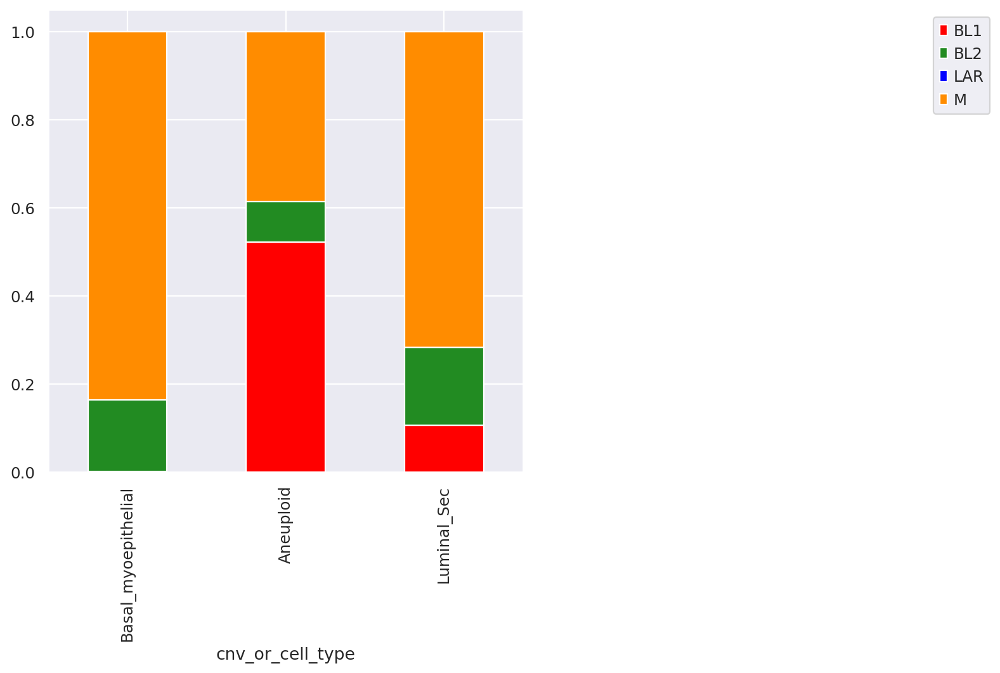

In [117]:
tmp = pd.crosstab(wk.obs['subtype'],wk.obs['cnv_or_cell_type'], 
                  normalize='columns').reindex()[["Basal_myoepithelial","Aneuploid","Luminal_Sec"]].T.plot(kind='bar', stacked=True,
                                                                                                           color=['red','forestgreen','blue','darkorange'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('cnv_by_subtype_tumorlike_stackedbar_plot.pdf', bbox_inches='tight')

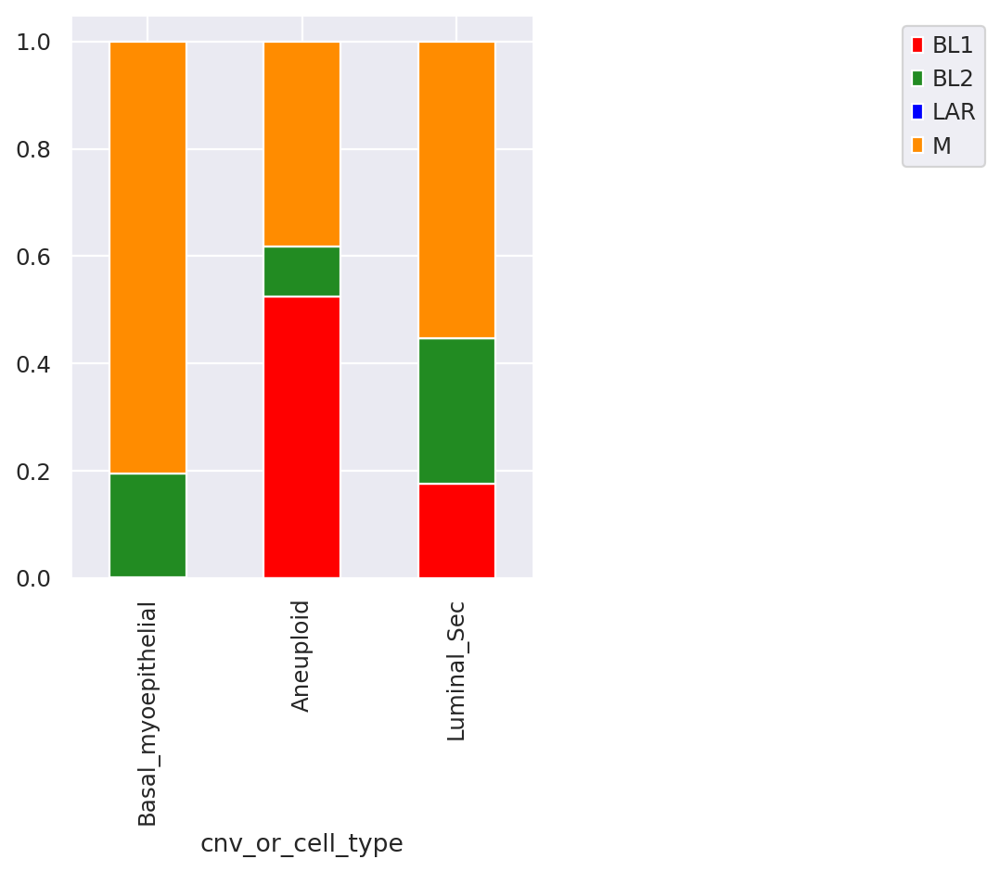

In [235]:
pl.rcParams["figure.figsize"] = (4,5)

mut=wk[wk.obs['Group'].isin(['WKBR_MG'])]

tmp = pd.crosstab(mut.obs['subtype'],mut.obs['cnv_or_cell_type'], 
                  normalize='columns').reindex()[["Basal_myoepithelial","Aneuploid","Luminal_Sec"]].T.plot(kind='bar', stacked=True,
                                                                                                           color=['red','forestgreen','blue','darkorange'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('cnv_by_subtype_tumorlike_stackedbar_plot.pdf', bbox_inches='tight')

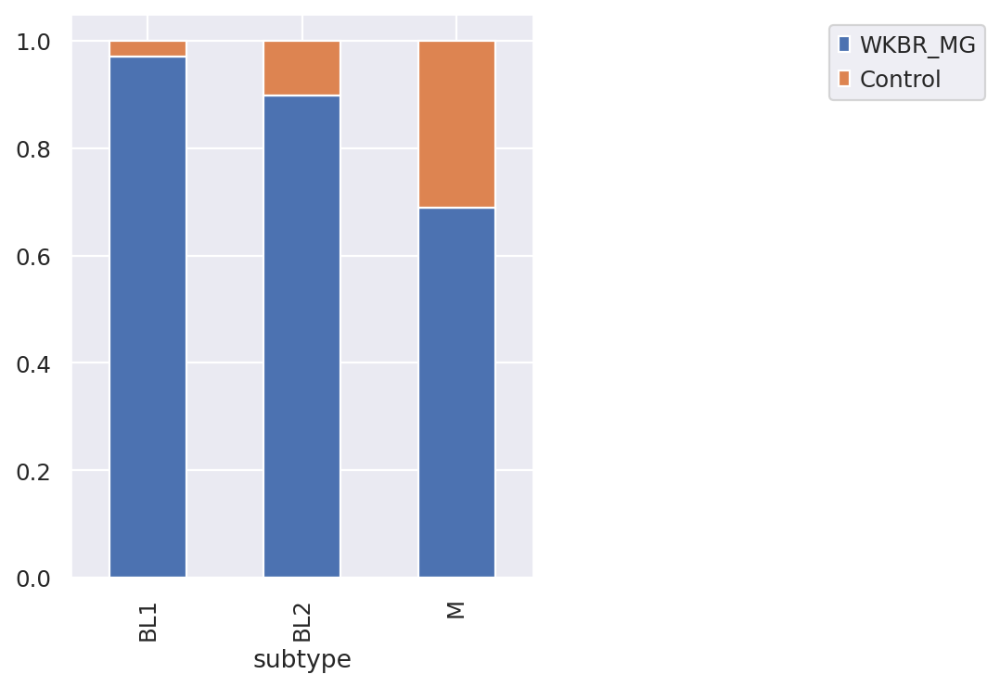

In [124]:
#wt=backup[~backup.obs['condition'].isin(["tumtant"])]
no_rare_subtypes=wk[~wk.obs['subtype'].isin(["LAR","UNS"])]
tmp = pd.crosstab(no_rare_subtypes.obs['Group'],no_rare_subtypes.obs['subtype'], 
                  normalize='columns').reindex(['WKBR_MG','Control']).T.plot(kind='bar', stacked=True,color=['#4c72b1','#dd8451'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

#pl.savefig('celltype_all_by_celltype_mut_stackedbar_plot.pdf', bbox_inches='tight')

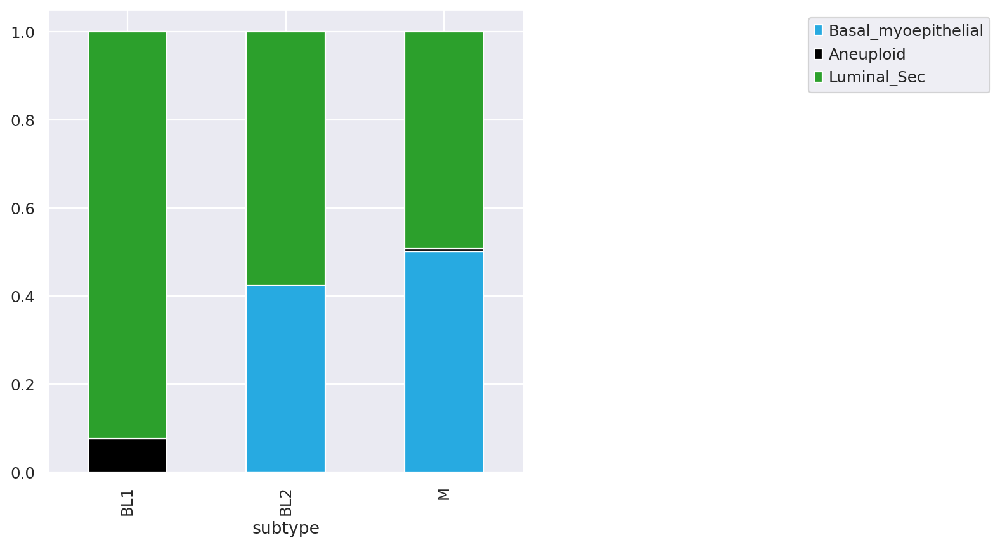

In [81]:
tmp = pd.crosstab(mut.obs['cnv_or_cell_type'],mut.obs['subtype'], 
                  normalize='columns').T.plot(kind='bar', stacked=True,color=['#27AAE1','black','#2ca02c'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('subtype_by_cnv_tumorlike_stackedbar_plot.pdf', bbox_inches='tight')

In [71]:
wk.obs['Group'].value_counts()

Group
WKBR_MG    17729
Control     1630
Name: count, dtype: int64

In [50]:
wk.obs.columns

Index(['orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample',
       'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums',
       'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore',
       'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups',
       'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin',
       'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       '_scvi_batch', '_scvi_labels', 'leiden', 'scaled_combined_lumsec_basal',
       'subtype', 'p.value', 'correlation', 'subtype_tumor_only',
       'cell_type_epi_individual', 'highlight

In [34]:
wk.obs['cell_type_epi_individual'].value_counts()

cell_type_epi_individual
Basal_myoepithelial    11066
Luminal_Sec             8293
Name: count, dtype: int64

In [24]:
wk.obs.columns

Index(['orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample',
       'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums',
       'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore',
       'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups',
       'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin',
       'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       '_scvi_batch', '_scvi_labels', 'leiden', 'scaled_combined_lumsec_basal',
       'subtype', 'p.value', 'correlation', 'subtype_tumor_only',
       'cell_type_epi_individual', 'highlight

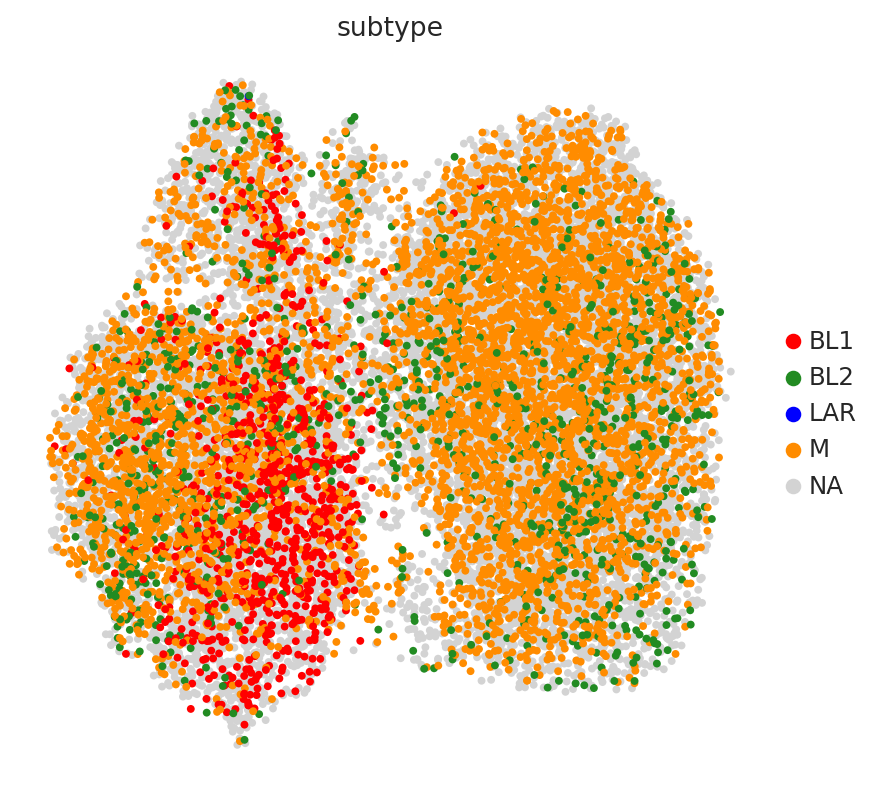

In [78]:
sc.pl.umap(wk, color='subtype',size=50,palette = {'BL1':'red',
                                                'BL2':'forestgreen',
                                                'LAR':'blue',
                                               'M':'darkorange',
                                               'UNS':'grey',
                                            'not_typed':'black'})

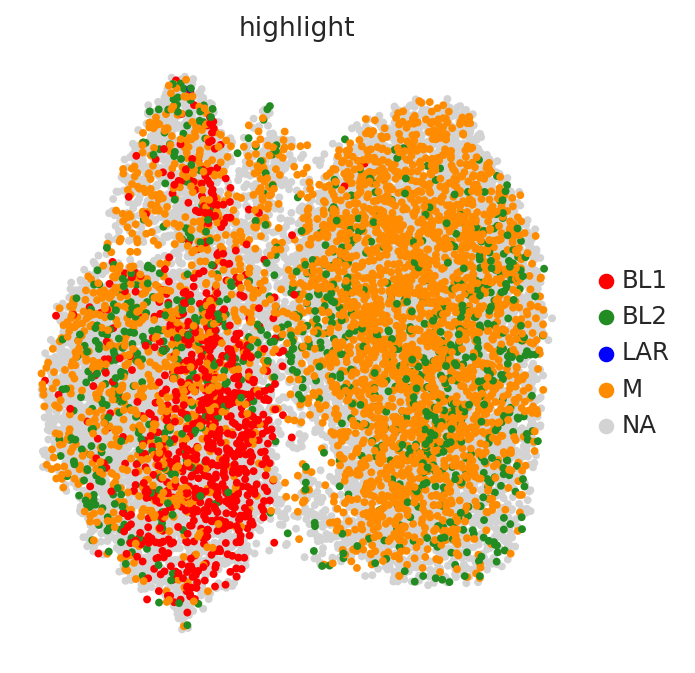

In [225]:
highlight=wk[wk.obs['Group'].isin(['WKBR_MG'])]
wk.obs['highlight'] = highlight.obs['subtype']

pl.rcParams["figure.figsize"] = (4.5,5)
#plt.figure(figsize=(4.5, 5))

sc.pl.umap(wk, color='highlight',size=50,palette = {'BL1':'red',
                                                'BL2':'forestgreen',
                                                'LAR':'blue',
                                               'M':'darkorange',
                                               'UNS':'grey',
                                            'not_typed':'grey'})



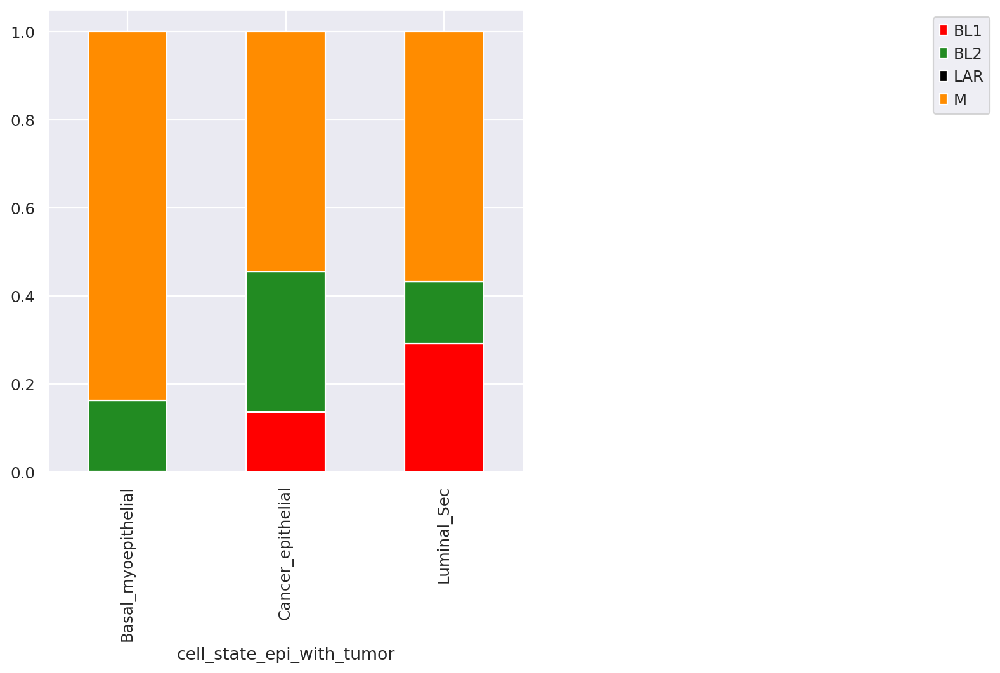

In [97]:
tmp = pd.crosstab(wk.obs['subtype'],wk.obs['cell_state_epi_with_tumor'], 
                  normalize='columns').reindex()[["Basal_myoepithelial","Cancer_epithelial","Luminal_Sec"]].T.plot(kind='bar', stacked=True,color=['red','forestgreen','black','darkorange'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('celltype_all_by_subtype_tumorlike_stackedbar_plot.pdf', bbox_inches='tight')

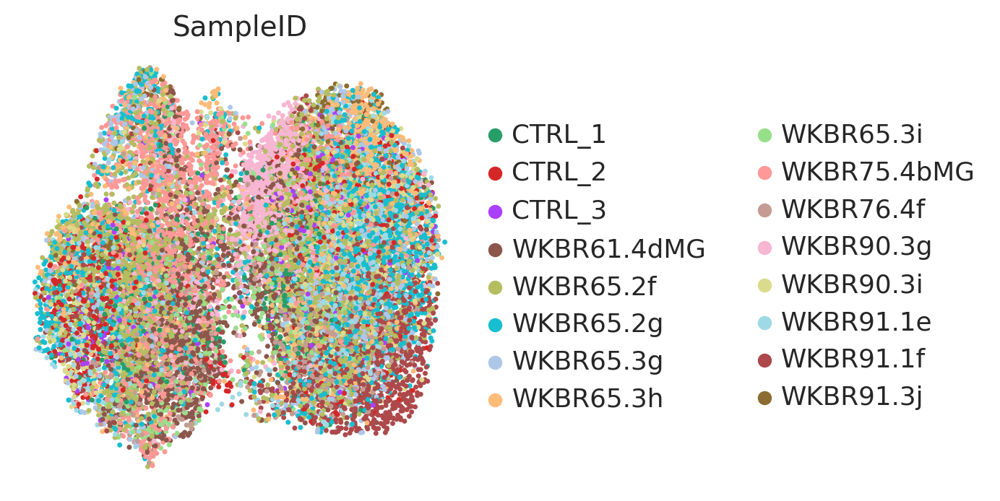

In [106]:
sc.pl.umap(
    wk,
    color=["SampleID"],
    wspace=0.5,
    size=25,save='_sampleID.pdf')

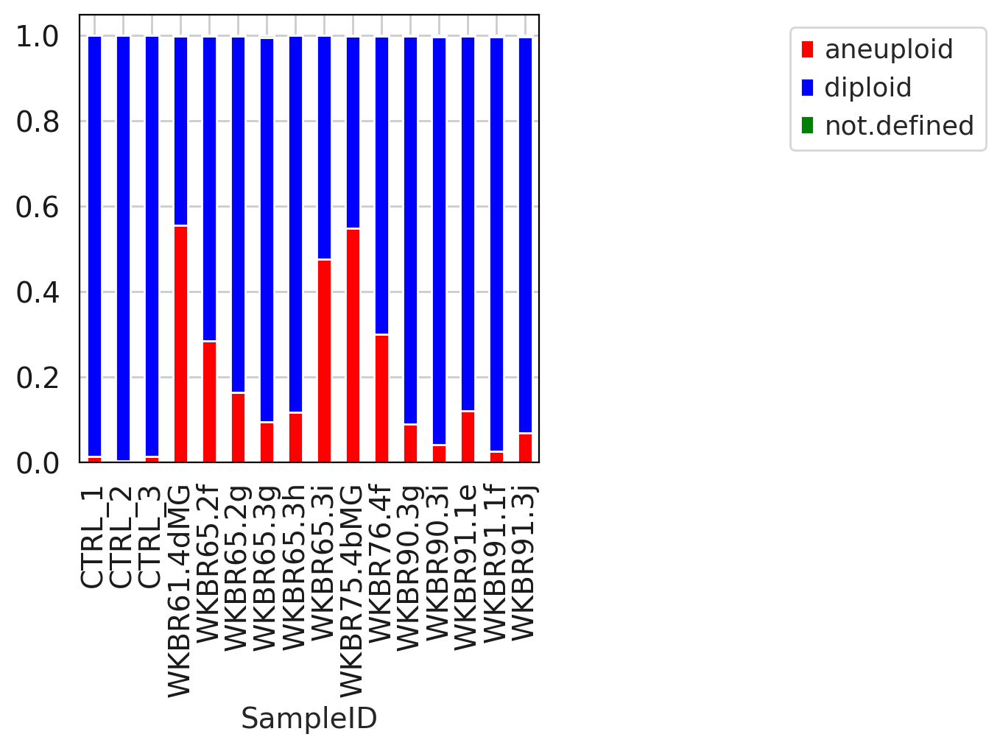

In [130]:
tmp = pd.crosstab(wk.obs['cnv'],wk.obs['SampleID'], 
                  normalize='columns').T.plot(kind='bar', stacked=True,color=['red','blue','green'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('orig_ident_by_cnv_stackedbar_plot.pdf', bbox_inches='tight')

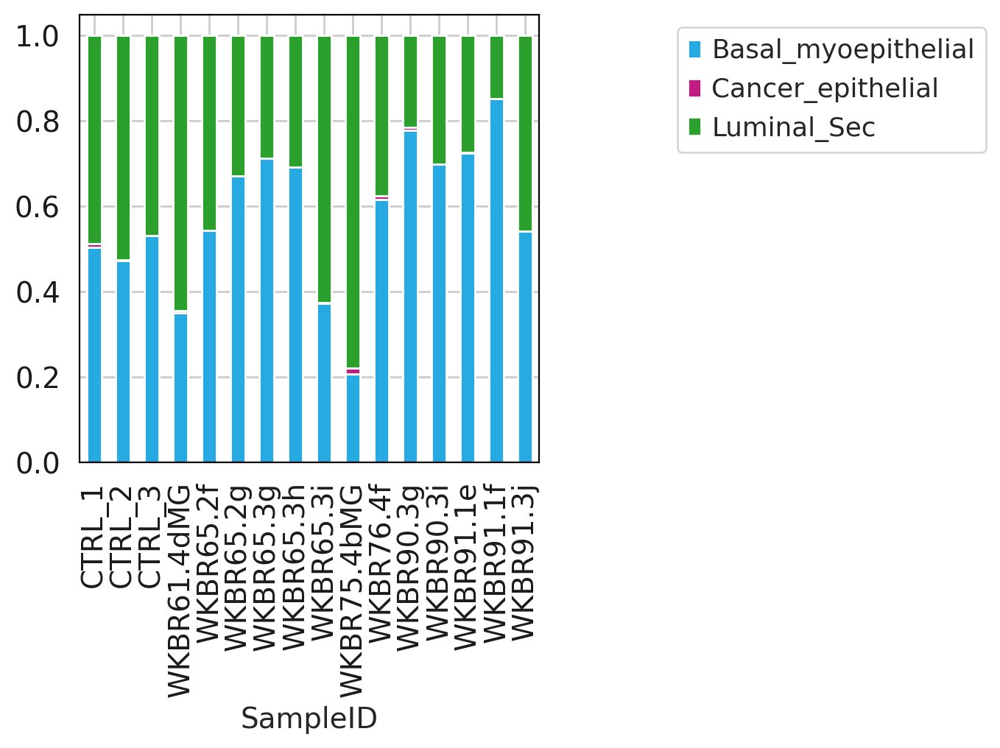

In [141]:
tmp = pd.crosstab(wk.obs['cell_state_epi_with_tumor'],wk.obs['SampleID'], 
                  normalize='columns').reindex(["Basal_myoepithelial","Cancer_epithelial","Luminal_Sec"]).T.plot(kind='bar', stacked=True,color=['#27AAE1',
                           '#C11C82','#2ca02c'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('orig_ident_by_celltype_mut_stackedbar_plot.pdf', bbox_inches='tight')

In [149]:
sub.obs['highlight'].value_counts()

highlight
0    19337
3       12
4        7
5        3
Name: count, dtype: int64

In [159]:
tum.obs['SampleID'].value_counts()

SampleID
WKBR61.4dMG    8
WKBR75.4bMG    4
WKBR76.4f      2
WKBR90.3g      2
WKBR91.1e      1
Name: count, dtype: int64

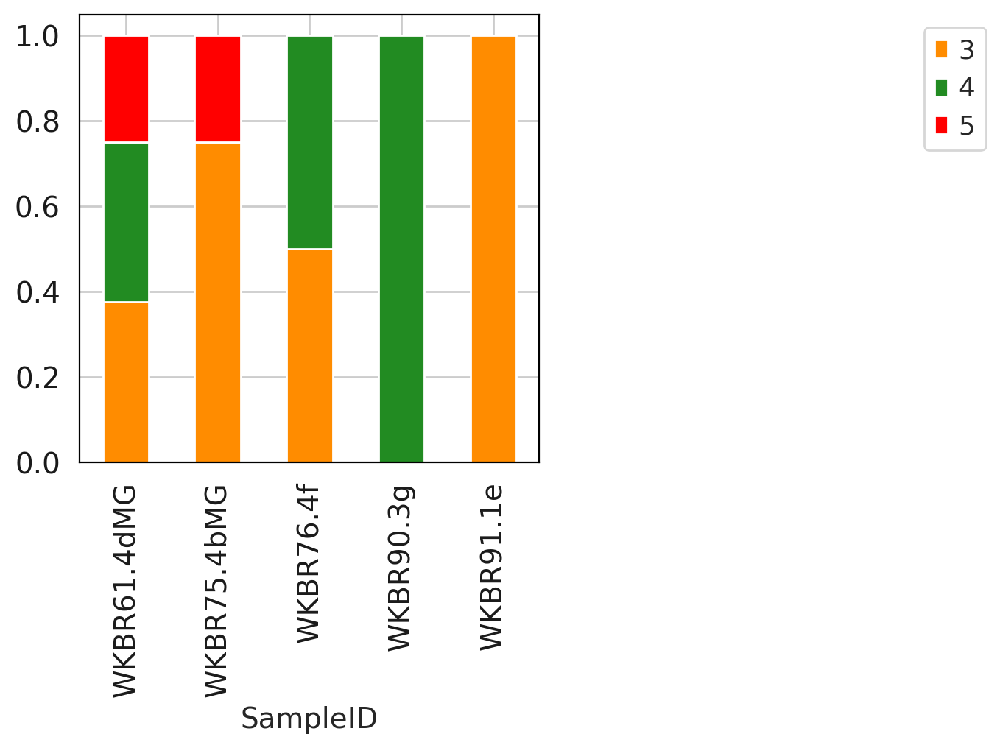

In [157]:
tum = sub[sub.obs['highlight'].isin([3,4,5])]
tum = tum[tum.obs['Group'].isin(["WKBR_MG"])]

tmp = pd.crosstab(tum.obs['highlight'],tum.obs['SampleID'], 
                  normalize='columns').T.plot(kind='bar', stacked=True,color=['darkorange','forestgreen','red'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('orig_ident_by_subtype_tumorlike_stackedbar_plot.pdf', bbox_inches='tight')

In [100]:
wk=wk.raw.to_adata()

In [101]:
wk

AnnData object with n_obs × n_vars = 19359 × 20224
    obs: 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums', 'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore', 'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups', 'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin', 'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', 'scaled_combined_lumsec_basal', 'subtype', 'p.value', 'correlation', 'subtype_tumor_only', 'cell_type_epi_individual', 'highlight', 'cnv', 'cell_state_epi_with_tumor'


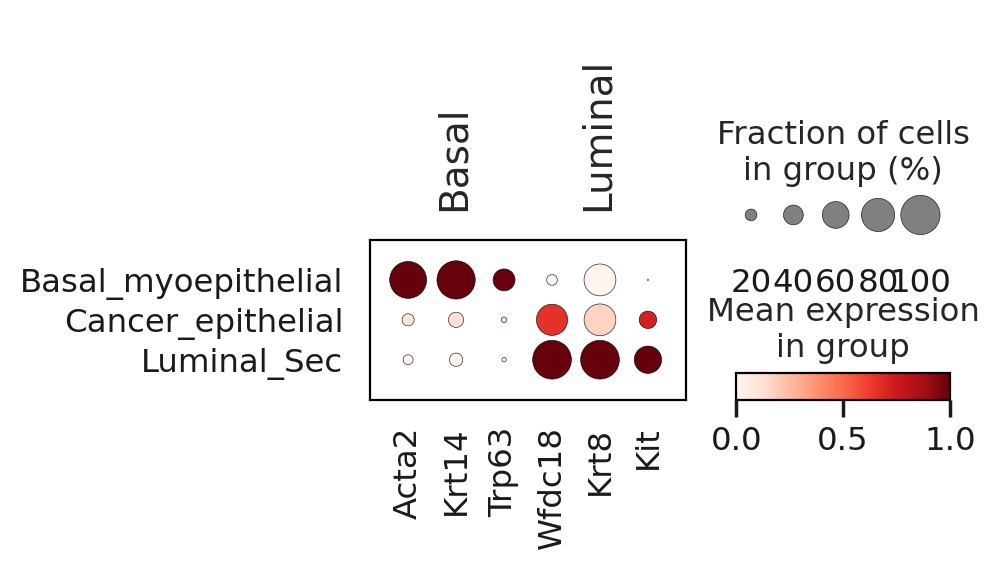

In [123]:
marker_genes = {
    "Basal": ["Acta2", "Krt14", "Trp63"],
    "Luminal": ["Wfdc18", "Krt8", "Kit"]
}

sc.pl.dotplot(wk, marker_genes, groupby="cell_state_epi_with_tumor",standard_scale="var",
             categories_order=["Basal_myoepithelial","Cancer_epithelial","Luminal_Sec"],save='dotplot_canonical_WAP.pdf')

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:640: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


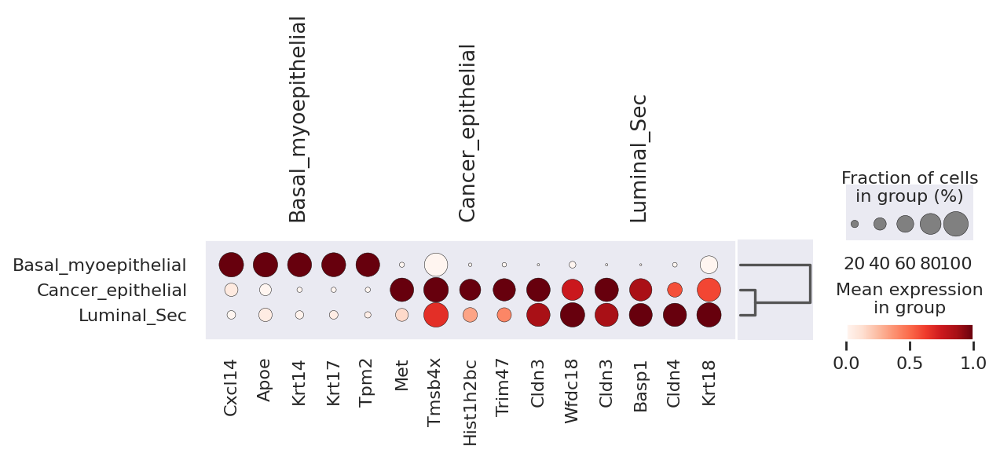

In [187]:
highlight = wk[wk.obs['Group'].isin(['WKBR_MG'])]
sc.tl.rank_genes_groups(highlight, groupby="cell_type", method="wilcoxon")
sc.tl.dendrogram(highlight, groupby='cell_type')
sc.pl.rank_genes_groups_dotplot(
    highlight, groupby="cell_type", standard_scale="var", n_genes=5,
    save='mut_unbiased_tumorlike_celltypes_dotplot.pdf'
)

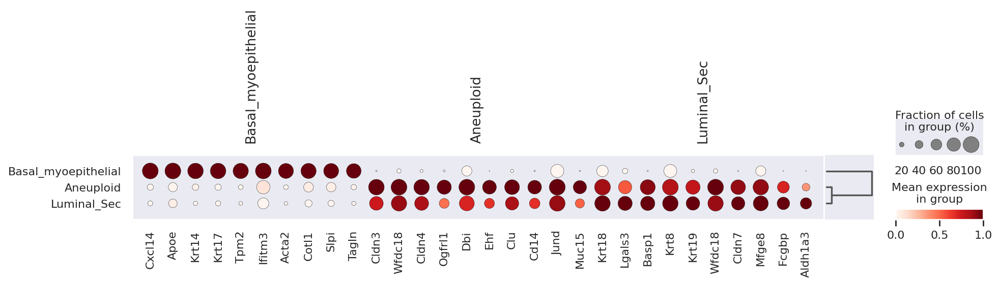

In [86]:
sc.tl.rank_genes_groups(mut, groupby="cnv_or_cell_type", method="wilcoxon")
sc.tl.dendrogram(mut, groupby='cnv_or_cell_type')
sc.pl.rank_genes_groups_dotplot(
    mut, groupby="cnv_or_cell_type", standard_scale="var", n_genes=10,
    save='unbiased_cnv_or_cell_type_dotplot.pdf'
)

# score

In [21]:
lumsec = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/normal_epi/LumSec_sig_degs.csv", index_col = 0)
basal = pd.read_csv("/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/normal_epi/Basal_sig_degs.csv", index_col = 0)

In [142]:
lumsec = lumsec['names'][:100].to_list()
basal = basal['names'][:100].to_list()

In [169]:
del_lumsec = ['Itm2b', 'Tcf7l2', 'Cd81', 'Fxyd3', 'Ctsh', 'Ramp1', 'Inhbb', 'Aldoc',
       'Cracr2b', 'Nfib', 'Dapk1', 'Rps9', 'Rplp1', 'Scml4', 'Deptor', 'Dapp1',
       'Itpr2', 'Gas6', 'Map3k1', 'Cited4', 'Notch1', 'Tgfb3', 'Cyb5a',
       'Stk39', 'Zfp704', 'Bcl2', 'Epb41l4aos', 'Rftn1', 'Clmn', 'Hivep3',
       'Isoc1', 'Pik3r1', 'Ppp1r2', 'Spns2', 'Shroom3', 'Muc1', 'Lurap1l','BC006965','Ccn1','Itprid1','Gas5']
del_basal = ['Rbp1', 'Cald1', 'Tpm1', 'Tshz2', 'Myl6', 'Cebpb', 'Nfix', 'Pmepa1',
       'Jmjd1c', 'Lhfp', 'Tmsb10', 'Aldh2', 'Tgfbr3', 'Luzp1', 'Lmo1', 'Cotl1',
       'Flna', 'Atxn1', 'Gja1', 'Col17a1', 'Col4a2', 'Col16a1', 'Bag3',
       'Zswim6', 'Emb', 'Marcksl1', 'Pkp4', 'Ccnl1', 'Lmod1', 'Cdh3',
       'Serpinh1', 'Msn', 'Sertad1', 'Ptpre', 'Auts2', 'Rnase4', 'Wsb1',
       'Nexn', 'Prelp', 'Ptpn14','Selenom','Cebpd','Ecrg4','Rflnb']

for item in lumsec:
    if item in del_lumsec:
        lumsec.remove(item)
        
for item in basal:
    if item in del_basal:
        basal.remove(item)

In [170]:
len(lumsec)

59

In [171]:
len(basal)

56

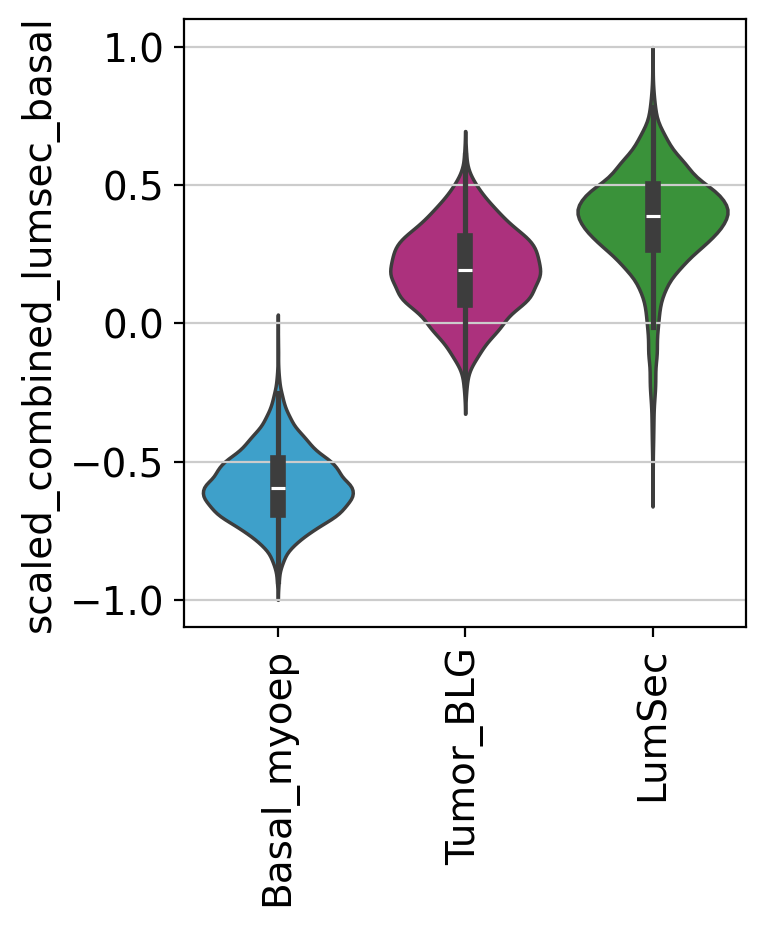

In [191]:
sc.pl.violin(wk, ["scaled_combined_lumsec_basal"], groupby="cell_type", 
             rotation=90, order=['Basal_myoep','Tumor_BLG','LumSec'], 
             stripplot=False, 
             inner='box',save='violin_scaled_combined_lumsec_basal.pdf')

In [33]:
pickle.dump(wk,
            open(os.path.join(work_dir, 'epithelial_wt_mut_tum_only_no_LumHR_bigsur_scvi.pkl'), 'wb'))

In [8]:
wk

AnnData object with n_obs × n_vars = 21731 × 779
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'batch', 'barcode', 'sample', 'sampleID', 'cluster', 'groups', 'majorGroups', 'cellTypes', 'cellTypesFinal', 'dbltScore', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.5', 'seurat_clusters', 'S.Score', 'G2M.Score', 'Phase', 'condition', 'UMAP_1', 'UMAP_2', 'cell_type_wk', 'cell_condition_wk', 'dataset', 'source', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', '_scvi_batch', '_scvi_labels', 'leiden', 'lumsec', 'basal', 'cell_type', 'scaled_lumsec', 'scaled_basal', 'combined_lumsec_basal', 'scaled_combined_lumsec_basal', 'basal_neg', 'scaled_basal_neg', 'subtype', 'subtype_only_tum', 'cell_type_epi', 'cn

In [8]:
tum = wk[wk.obs['leiden'].isin(['6','7'])]

## Figure 3

In [22]:
wk.obs['cell_type'].value_counts()

cell_type
Basal_myoepithelial    11140
Luminal_Sec             8203
Cancer_epithelial         16
Name: count, dtype: int64

In [32]:
not_mutant_cnv=wk[~wk.obs['cnv'].isin(['aneuploid'])]
not_mutant_cnv


not_mutant_cnv.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cell_type']

wk.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cnv_or_cell_type']

categories = np.array(
     ['Bmyo', 'LumSec',  'tumor', 'aneuploid'])

wk.obs['cnv_or_cell_type'] = pd.Categorical(
   wk.obs['cnv_or_cell_type'], categories=categories, ordered=True)

wk.obs['cnv_or_cell_type'].fillna("aneuploid", inplace=True,)

/tmp/ipykernel_4046017/1233153619.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  not_mutant_cnv.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cell_type']


In [34]:
not_mutant_cnv=wk[~wk.obs['cnv'].isin(['aneuploid'])]

not_mutant_cnv.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cell_type']

wk.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cnv_or_cell_type']

categories = np.array(
     ['Bmyo', 'LumSec', 'tumor', 'aneuploid'])

wk.obs['cnv_or_cell_type'] = pd.Categorical(
   wk.obs['cnv_or_cell_type'], categories=categories, ordered=True)

wk.obs['cnv_or_cell_type'].fillna("aneuploid", inplace=True,)

/tmp/ipykernel_4046017/221882276.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  not_mutant_cnv.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cell_type']


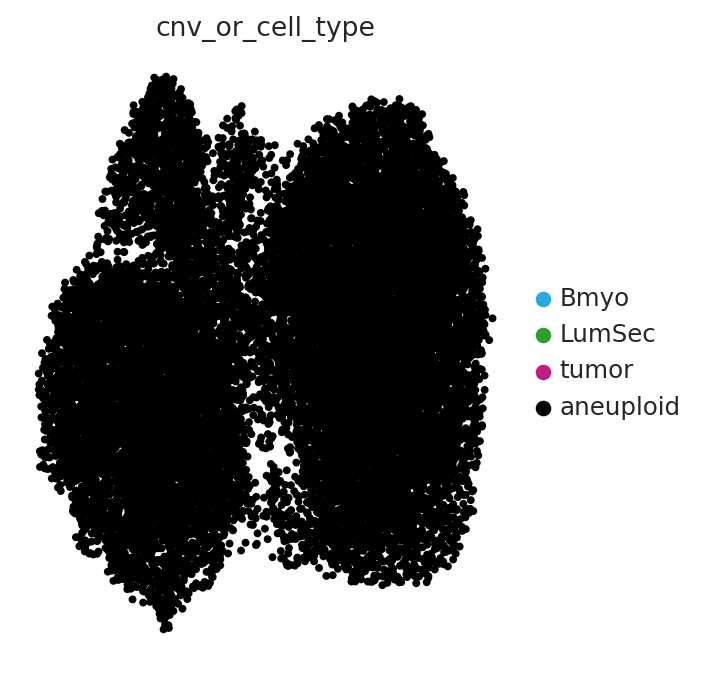

In [36]:
pl.rcParams["figure.figsize"] = (4,5)

sc.pl.umap(wk, color='cnv_or_cell_type', size=50,
          palette = {'Bmyo':'#27AAE1',
              'tumor':'#C11C82',
              'LumSec':'#2ca02c','aneuploid':'black'}
          )

In [23]:
wk.obs["cell_type_final"] = wk.obs["cell_type"].map(
    {"Basal_myoepithelial": "Bmyo",
        "Luminal_Sec": "LumSec",
        "Cancer_epithelial": "tumor"
    }
)


wk.obs["Group_final"] = wk.obs["Group"].map(
    {"Control": "normal",
        "WKBR_MG": "mutant"
    }
)

In [24]:
#sub = wk[~wk.obs['cnv'].isin(["not.defined"])]
sub = wk # after not defined became diploid

In [27]:
sub.obs['cnv'].value_counts()

cnv
diploid        14943
aneuploid       4391
not.defined       25
Name: count, dtype: int64

In [26]:
sub.obs['cnv_final'].value_counts()

cnv_final
diploid      14968
aneuploid     4391
Name: count, dtype: int64

In [28]:
sub.obs['condition'] = sub.obs["Group_final"].astype("str")
sub.obs['cnv_final'] = sub.obs["cnv_final"].astype("str")
sub.obs['cell_type_final'] = sub.obs["cell_type_final"].astype("str")

sub.obs['cell_type_condition'] = sub.obs['cell_type_final'] + ' ' + sub.obs['condition']
sub.obs['cell_type_ploidy'] = sub.obs['cell_type_final'] + ' ' + sub.obs['cnv_final']

In [29]:
sub.obs['cell_type_condition'] = sub.obs["cell_type_condition"].astype("str")
sub.obs['cnv_final'] = sub.obs["cnv_final"].astype("str")

sub.obs['cell_type_condition_ploidy'] = sub.obs['cell_type_condition'] + ' ' + sub.obs['cnv_final']

In [31]:
sub.obs.columns

Index(['orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample',
       'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums',
       'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore',
       'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups',
       'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin',
       'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       '_scvi_batch', '_scvi_labels', 'leiden', 'scaled_combined_lumsec_basal',
       'subtype', 'p.value', 'correlation', 'subtype_tumor_only',
       'cell_type_epi_individual', 'highlight

In [30]:
sub.obs['cell_type_condition'].value_counts()

cell_type_condition
Bmyo mutant      10336
LumSec mutant     7377
LumSec normal      826
Bmyo normal        804
tumor mutant        16
Name: count, dtype: int64

In [31]:
sub.obs['cell_type_condition_ploidy'].value_counts() 

cell_type_condition_ploidy
Bmyo mutant diploid        10286
LumSec mutant aneuploid     4314
LumSec mutant diploid       3063
LumSec normal diploid        818
Bmyo normal diploid          800
Bmyo mutant aneuploid         50
tumor mutant aneuploid        15
LumSec normal aneuploid        8
Bmyo normal aneuploid          4
tumor mutant diploid           1
Name: count, dtype: int64

In [34]:
no_facs = sub

In [35]:
df=no_facs.obs.copy()

category_order = ['Bmyo normal', 'Bmyo mutant',
                 'LumSec normal', 'LumSec mutant',
                 'tumor mutant']

no_facs.obs['cell_type_condition'] = pd.Categorical(
   no_facs.obs['cell_type_condition'], categories=category_order, ordered=True)

In [36]:
category_order = ['Bmyo normal diploid',
                  'Bmyo normal aneuploid',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec normal diploid',
                  'LumSec normal aneuploid',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                  'tumor mutant diploid',
                 'tumor mutant aneuploid']

no_facs.obs['cell_type_condition_ploidy'] = pd.Categorical(
   no_facs.obs['cell_type_condition_ploidy'], categories=category_order, ordered=True)

In [62]:
df['Match_aneu'] = (df['cnv'] == "aneuploid").astype(int)
category_match = df.groupby('cell_type_condition')['Match_aneu'].mean() * 100
rep_match = df.groupby(['cell_type_condition','SampleID'])['Match_aneu'].mean() * 100
rep_match=pd.DataFrame(rep_match)

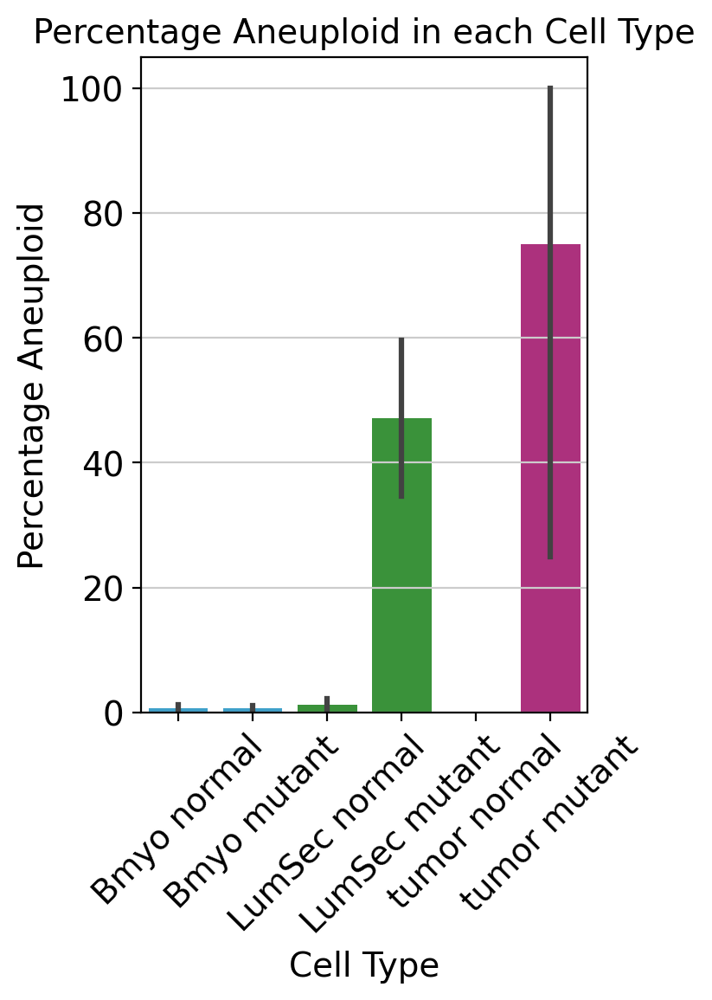

In [64]:
colors=['#27AAE1','#27AAE1','#2ca02c','#2ca02c','#C11C82','#C11C82']

category_order = ['Bmyo normal', 'Bmyo mutant',
                 'LumSec normal', 'LumSec mutant',
                 'tumor normal', 'tumor mutant']

plt.figure(figsize=(4, 6))
sns.barplot(x='cell_type_condition', y='Match_aneu', data=rep_match, palette=colors, order=category_order)
plt.xlabel('Cell Type')
plt.tick_params(axis='x', labelrotation=45)
plt.ylabel('Percentage Aneuploid')
plt.title('Percentage Aneuploid in each Cell Type')
plt.tight_layout()
plt.savefig('percent_aneuploid_per_celltype_condition.pdf', format='pdf')
plt.show()

In [145]:
sub2=sub[~sub.obs['cell_type_ploidy'].isin(['tumor diploid'])]

In [81]:
sc.tl.rank_genes_groups(sub2, groupby="cell_type_ploidy", method="wilcoxon")
sc.tl.dendrogram(sub2, groupby = "cell_type_ploidy")

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:640: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


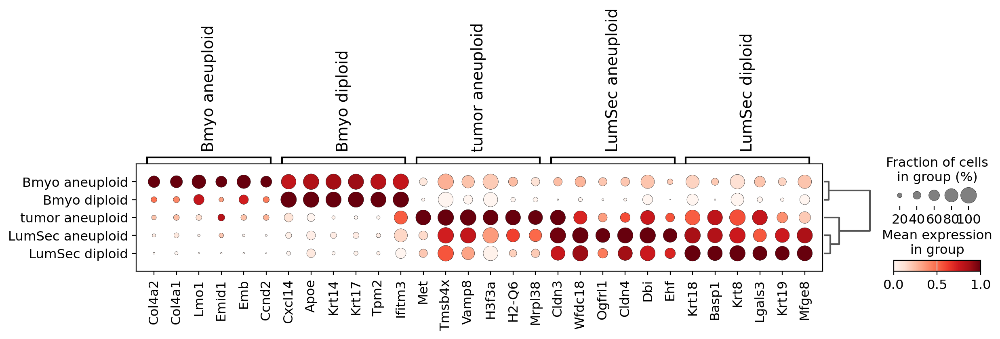

In [83]:
sc.pl.rank_genes_groups_dotplot(sub2, groupby="cell_type_ploidy", 
                                standard_scale="var", n_genes=6,
                               categories_order=['Bmyo diploid', 'Bmyo aneuploid',
                 'LumSec diploid', 'LumSec aneuploid',
                 'tumor aneuploid'])

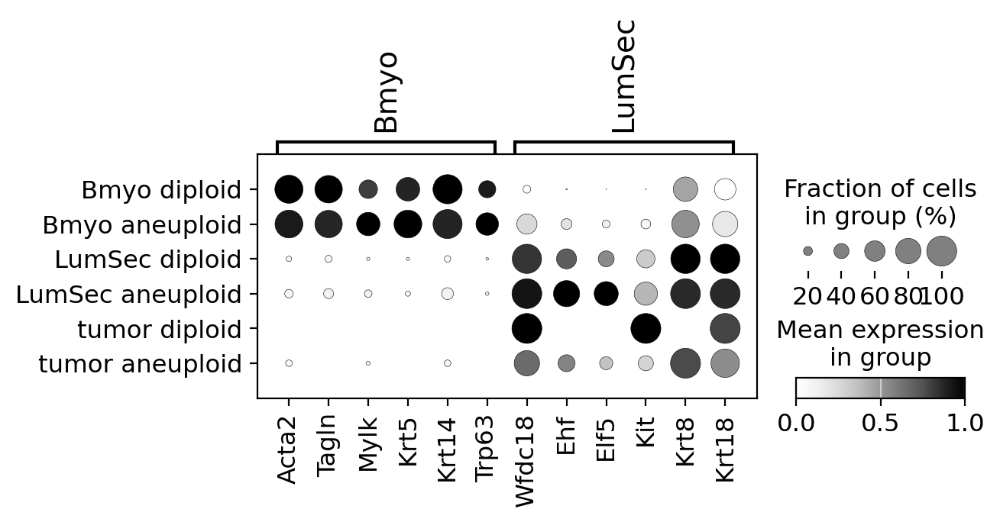

In [68]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"]
}


sc.pl.dotplot(sub, marker_genes, groupby="cell_type_ploidy",
              standard_scale="var",swap_axes=False,cmap="Grays",
             categories_order=['Bmyo diploid', 'Bmyo aneuploid',
                 'LumSec diploid', 'LumSec aneuploid','tumor diploid',
                 'tumor aneuploid'],save='dot_canonical_cell_type_ploidy.pdf')

In [32]:
sub.obs['Figure_3_id'] = (
    sub.obs["cell_type_condition_ploidy"]
    .map(lambda x: {"Bmyo normal diploid": "Bmyo WT",
                    "Bmyo mutant diploid": "Bmyo mutant diploid",
                    "LumSec normal diploid": "LumSec WT",
                    "LumSec mutant diploid": "LumSec mutant diploid",
                   "tumor mutant aneuploid": "tumor-like mutant aneuploid",
                   "Bmyo mutant aneuploid": "Bmyo mutant aneuploid",
                    "LumSec mutant aneuploid": "LumSec mutant aneuploid",
                    "tumor mutant diploid": "tumor-like mutant diploid",
                    "tumor normal diploid": "tumor-like WT",
                    "Bmyo normal aneuploid": "Bmyo WT",
                   "LumSec normal aneuploid": "LumSec WT",
                   "tumor normal aneuploid": "tumor-like WT"}.get(x, x))
    .astype("category")
)

sub.obs['Figure_3_id'].value_counts()

Figure_3_id
Bmyo mutant diploid            10286
LumSec mutant aneuploid         4314
LumSec mutant diploid           3063
LumSec WT                        826
Bmyo WT                          804
Bmyo mutant aneuploid             50
tumor-like mutant aneuploid       15
tumor-like mutant diploid          1
Name: count, dtype: int64

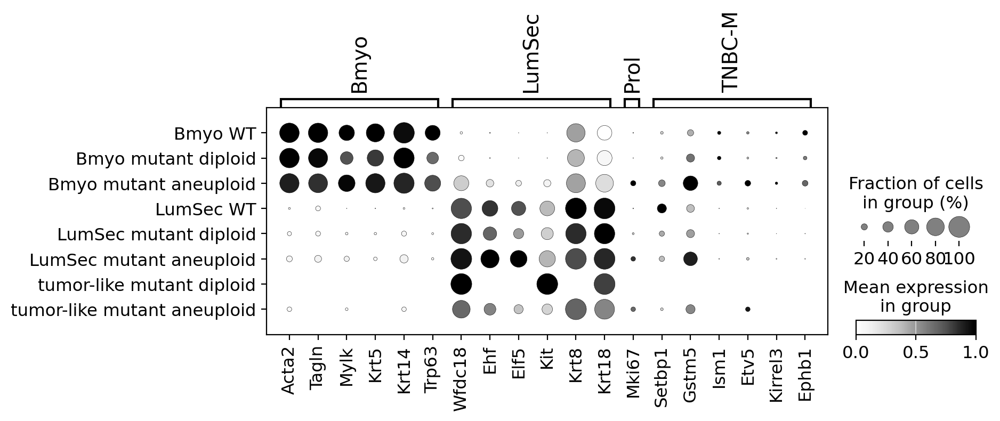

In [33]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "Prol": ["Mki67"],
    "TNBC-M":["Setbp1","Gstm5","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(sub, marker_genes, groupby="Figure_3_id",
              standard_scale="var",swap_axes=False,cmap="Grays",
             categories_order=['Bmyo WT',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec WT',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                  'tumor-like mutant diploid',
                 'tumor-like mutant aneuploid'],
              save='_Fig3_canonical_cell_type_condition_ploidy.pdf'
             )

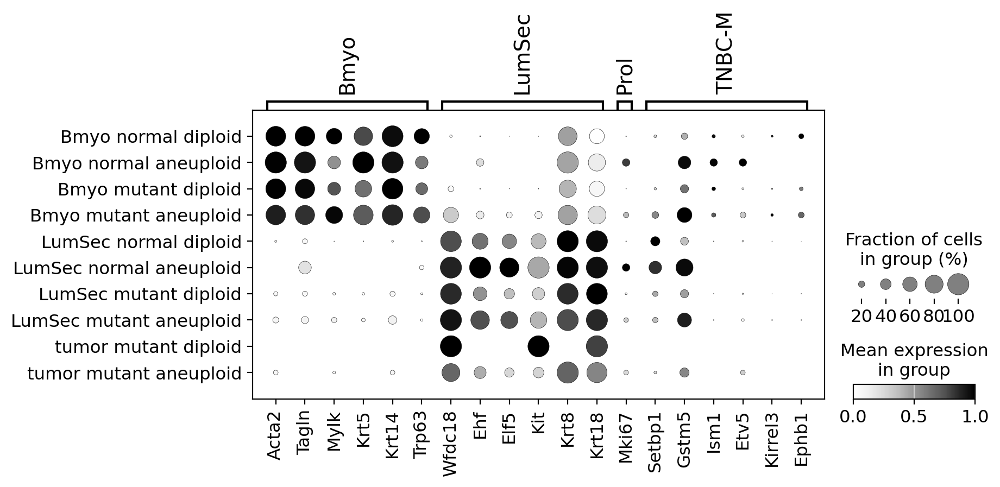

In [37]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "Prol": ["Mki67"],
    "TNBC-M":["Setbp1","Gstm5","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(sub, marker_genes, groupby="cell_type_condition_ploidy",
              standard_scale="var",swap_axes=False,cmap="Grays",
             categories_order=['Bmyo normal diploid',
                  'Bmyo normal aneuploid',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec normal diploid',
                  'LumSec normal aneuploid',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                               'tumor mutant diploid',
                 'tumor mutant aneuploid'],
              save='dot_canonical_cell_type_condition_ploidy.pdf'
             )

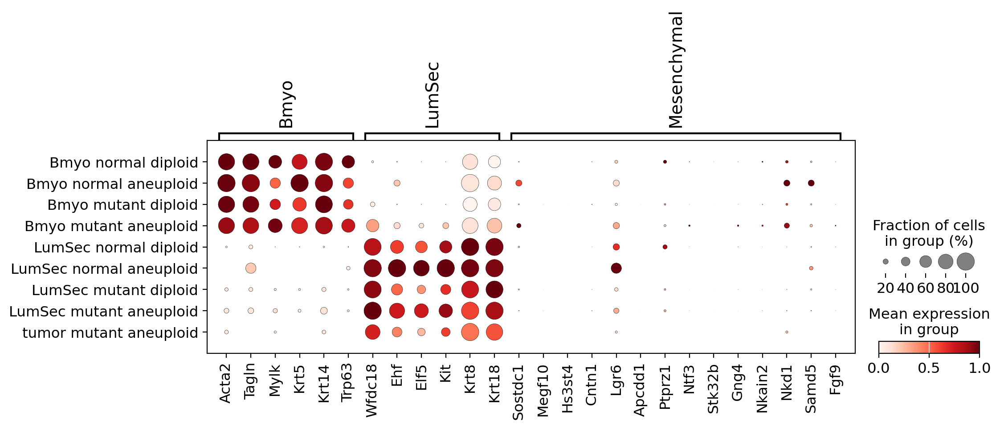

In [151]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
"Mesenchymal": ["Sostdc1","Megf10","Hs3st4","Cntn1","Lgr6",
                "Apcdd1","Ptprz1","Ntf3","Stk32b","Gng4",
                "Nkain2","Nkd1","Samd5","Fgf9"]
}


sc.pl.dotplot(sub2, marker_genes, groupby="cell_type_condition_ploidy",
              standard_scale="var",swap_axes=False,
             categories_order=['Bmyo normal diploid',
                  'Bmyo normal aneuploid',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec normal diploid',
                  'LumSec normal aneuploid',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                 'tumor mutant aneuploid'])

In [ ]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
"Mesenchymal": ["Sostdc1","Megf10","Hs3st4","Cntn1","Lgr6",
                "Apcdd1","Ptprz1","Ntf3","Stk32b","Gng4",
                "Nkain2","Nkd1","Samd5","Fgf9"]
}


sc.pl.dotplot(sub2, marker_genes, groupby="cell_type_ploidy",
              standard_scale="var",swap_axes=False,
             categories_order=['Bmyo diploid', 'Bmyo aneuploid',
                 'LumSec diploid', 'LumSec aneuploid',
                 'tumor aneuploid'])

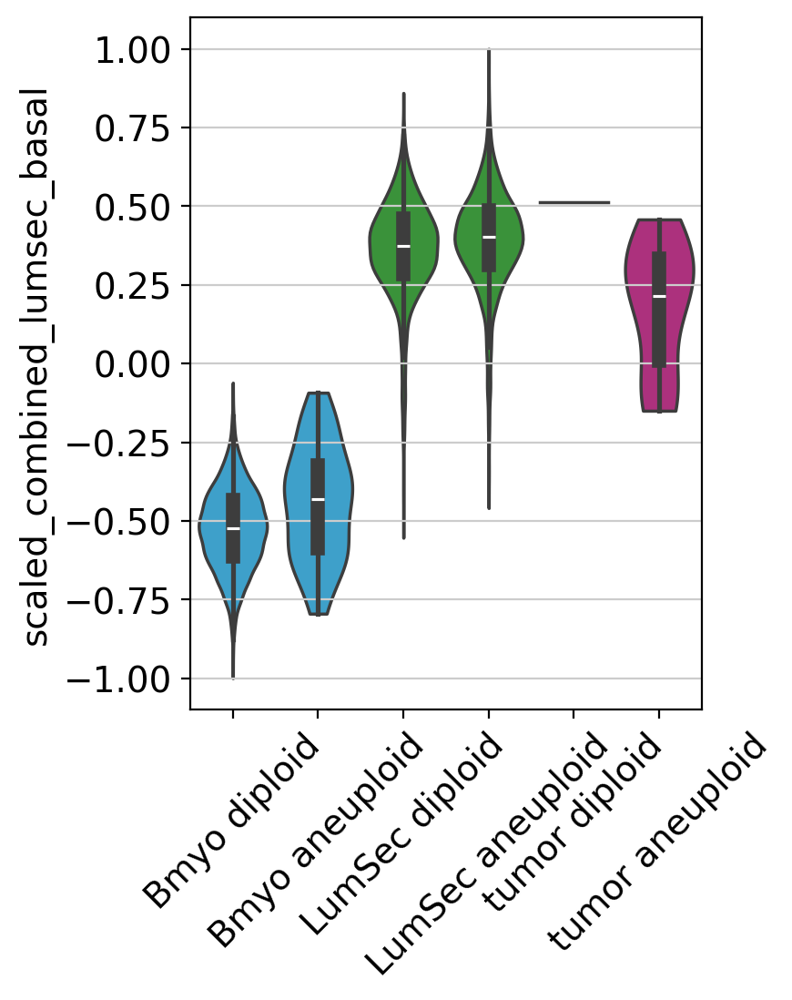

In [74]:
sc.pl.violin(sub, ["scaled_combined_lumsec_basal"], groupby="cell_type_ploidy", 
             rotation=45, palette = ['#27AAE1','#27AAE1','#2ca02c','#2ca02c','#C11C82','#C11C82'],
             stripplot=False,order=['Bmyo diploid', 'Bmyo aneuploid',
                 'LumSec diploid', 'LumSec aneuploid','tumor diploid',
                 'tumor aneuploid'],
             inner='box',save='violin_scaled_scores_cell_type_ploidy.pdf'
            )

In [91]:
sub.obs['cell_type_condition_ploidy'].value_counts() 

cell_type_condition_ploidy
Bmyo mutant diploid        10278
LumSec mutant aneuploid     4314
LumSec mutant diploid       3046
LumSec normal diploid        818
Bmyo normal diploid          800
Bmyo mutant aneuploid         50
tumor mutant aneuploid        15
LumSec normal aneuploid        8
Bmyo normal aneuploid          4
tumor mutant diploid           1
Name: count, dtype: int64

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:907: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


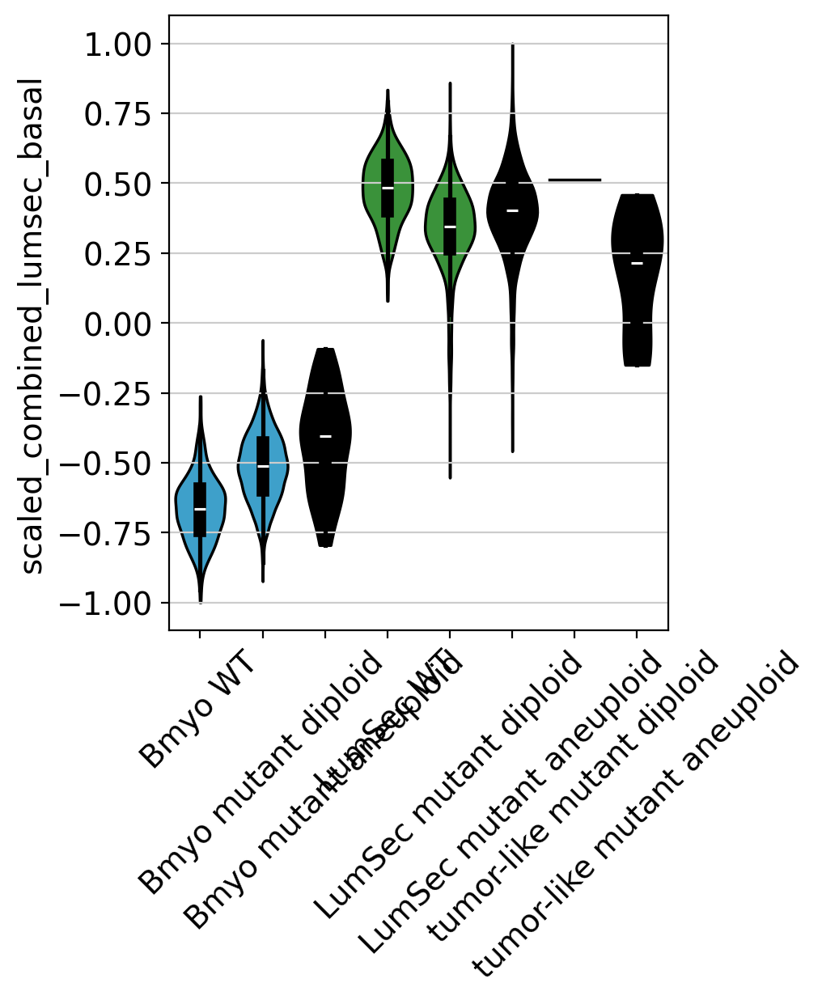

In [34]:
pl.rcParams["figure.figsize"] = (4.25,5)

sc.pl.violin(sub, ["scaled_combined_lumsec_basal"], groupby="Figure_3_id", 
             rotation=45, palette = ['#27AAE1','#27AAE1','black',
                                     '#2ca02c','#2ca02c','black',
                                     '#C11C82','black'],
             stripplot=False,order=['Bmyo WT',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec WT',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                  'tumor-like mutant diploid',
                 'tumor-like mutant aneuploid'],
             inner='box',
             save='_fig3_violin_scaled_scores_cell_type_ploidy.pdf'
            )

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:907: UserWarning: The palette list has more values (12) than needed (10), which may not be intended.
  ax = sns.violinplot(


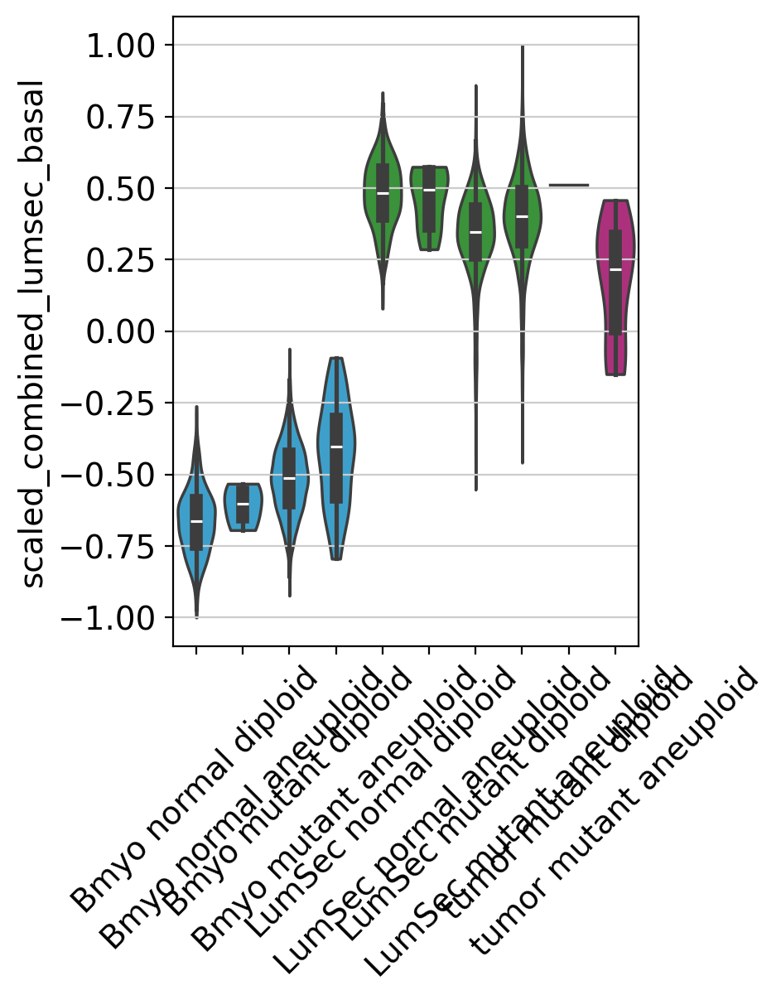

In [77]:
sc.pl.violin(sub, ["scaled_combined_lumsec_basal"], groupby="cell_type_condition_ploidy", 
             rotation=45, palette = ['#27AAE1','#27AAE1','#27AAE1','#27AAE1',
                                     '#2ca02c','#2ca02c','#2ca02c','#2ca02c',
                                     '#C11C82','#C11C82','#C11C82','#C11C82'],
             stripplot=False,order=['Bmyo normal diploid',
                  'Bmyo normal aneuploid',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec normal diploid',
                  'LumSec normal aneuploid',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                                    'tumor mutant diploid',
                 'tumor mutant aneuploid'],
             inner='box',
             save='violin_scaled_scores_cell_type_ploidy.pdf'
            )

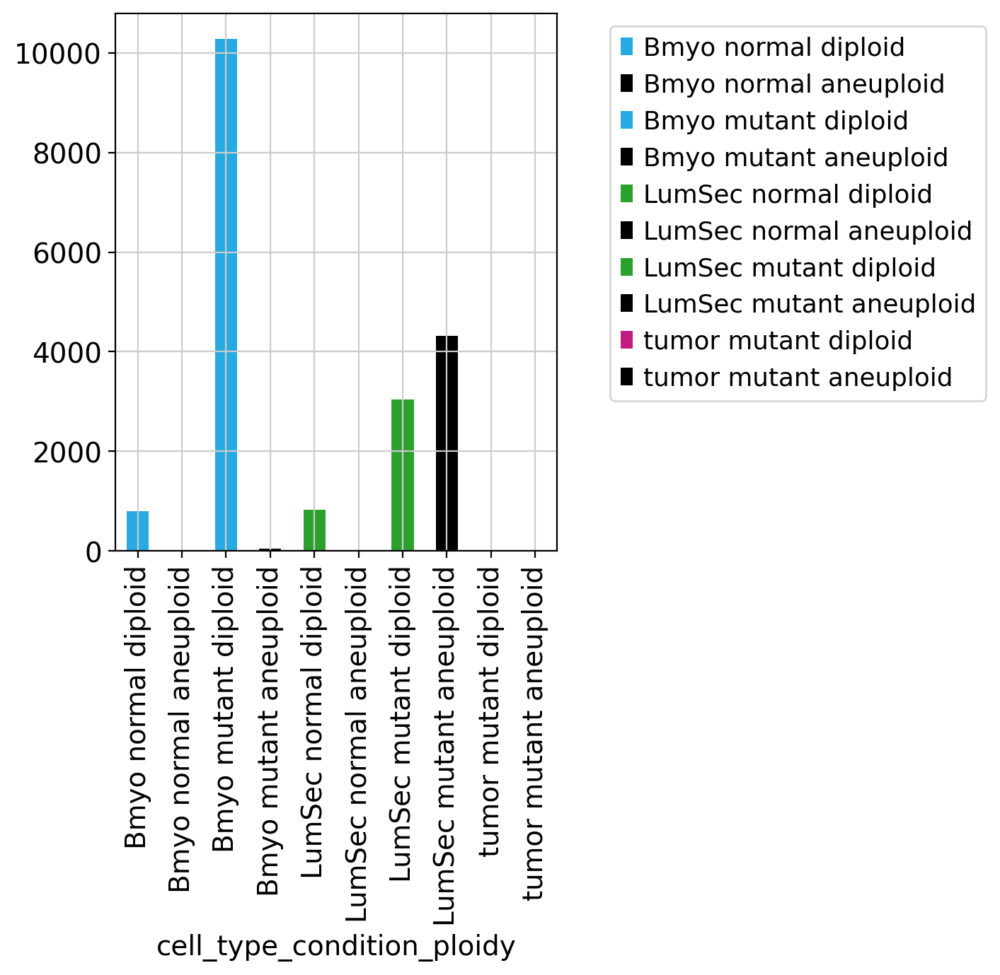

In [88]:
tmp = pd.crosstab(sub.obs['cell_type_condition_ploidy'],sub.obs['cell_type_condition_ploidy']).reindex()[['Bmyo normal diploid',
                  'Bmyo normal aneuploid',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec normal diploid',
                  'LumSec normal aneuploid',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                 'tumor mutant diploid',
                 'tumor mutant aneuploid']].T.plot(kind='bar', stacked=True,color=['#27AAE1','black','#27AAE1','black',
       '#2ca02c','black','#2ca02c','black',
       '#C11C82','black'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('subtype_cell_type_ploidy_stacked_unnormalized.pdf', bbox_inches='tight')

In [80]:
sub2

NameError: name 'sub2' is not defined

In [99]:
sub2.obs['subtype'] = res['subtype']

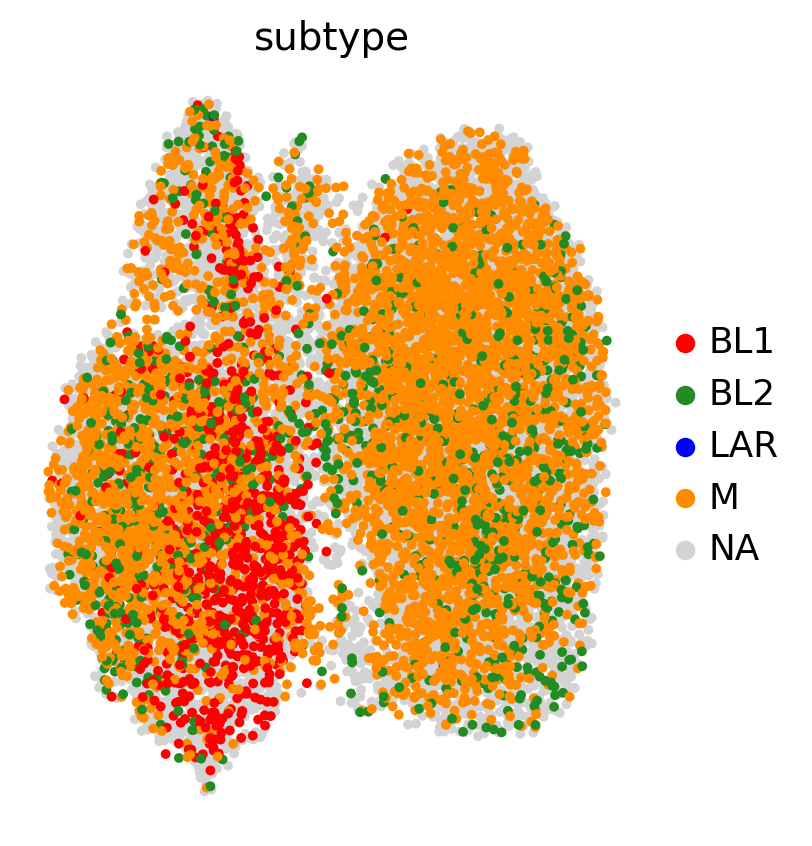

In [100]:
pl.rcParams["figure.figsize"] = (4,5)

sc.pl.umap(sub2, color='subtype', size=50,
          palette = {'BL1':'red',
                                                'BL2':'forestgreen',
                                                'LAR':'blue',
                                               'M':'darkorange',
                                               'UNS':'grey'}
          )

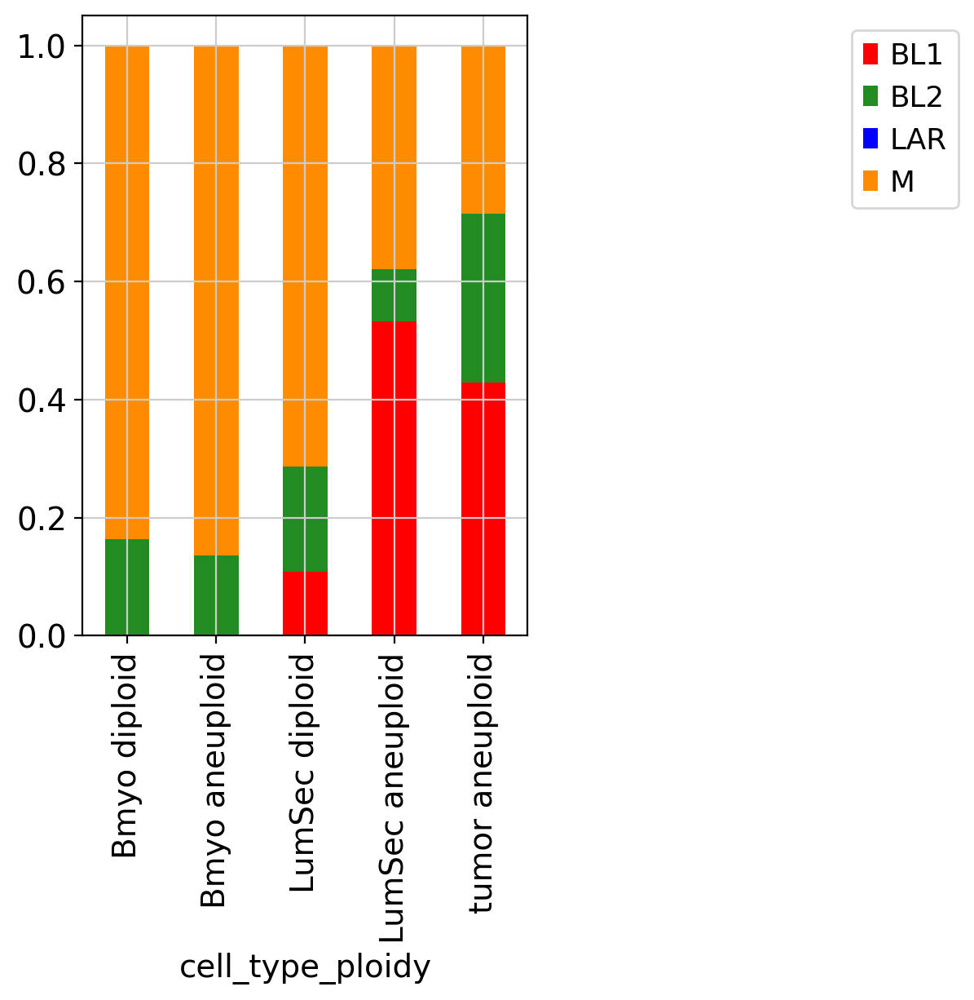

In [104]:
pl.rcParams["figure.figsize"] = (3.5,5)


tmp = pd.crosstab(sub2.obs['subtype'],sub2.obs['cell_type_ploidy'], 
                  normalize='columns').reindex()[['Bmyo diploid', 'Bmyo aneuploid',
                 'LumSec diploid', 'LumSec aneuploid',
                 'tumor aneuploid']].T.plot(kind='bar', stacked=True,
                                                                                                                  color=['red',
                                                'forestgreen',
                                                'blue',
                                               'darkorange',
                                               'grey'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

pl.savefig('subtype_cell_type_ploidy_stacked.pdf', bbox_inches='tight')

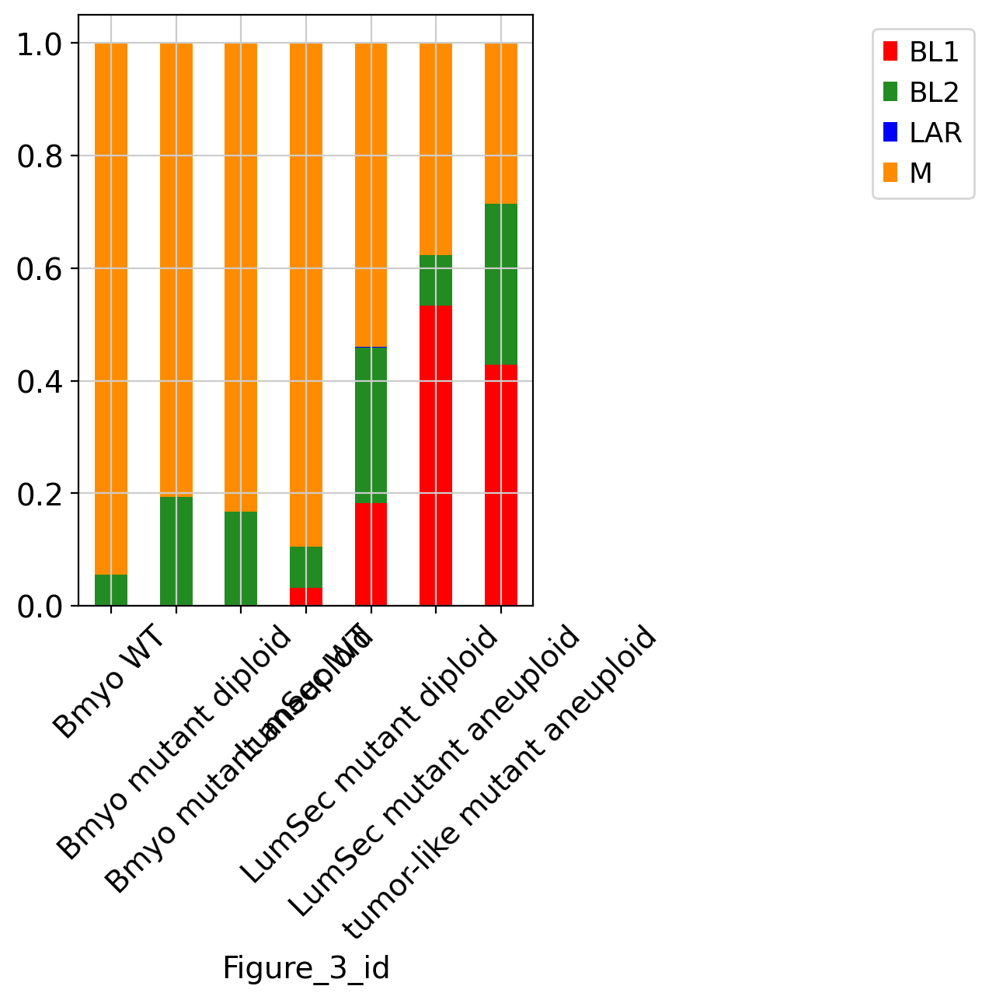

In [38]:
pl.rcParams["figure.figsize"] = (3.75,5)

tmp = pd.crosstab(sub.obs['subtype'],sub.obs['Figure_3_id'], 
                  normalize='columns').reindex()[['Bmyo WT',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec WT',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                 'tumor-like mutant aneuploid']].T.plot(kind='bar', stacked=True,
                                                                                                                  color=['red',
                                                'forestgreen',
                                                'blue',
                                               'darkorange',
                                               'grey'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')
pl.xticks(rotation=45)
pl.savefig('fig3_subtype_cell_type_ploidy_stacked.pdf', bbox_inches='tight')

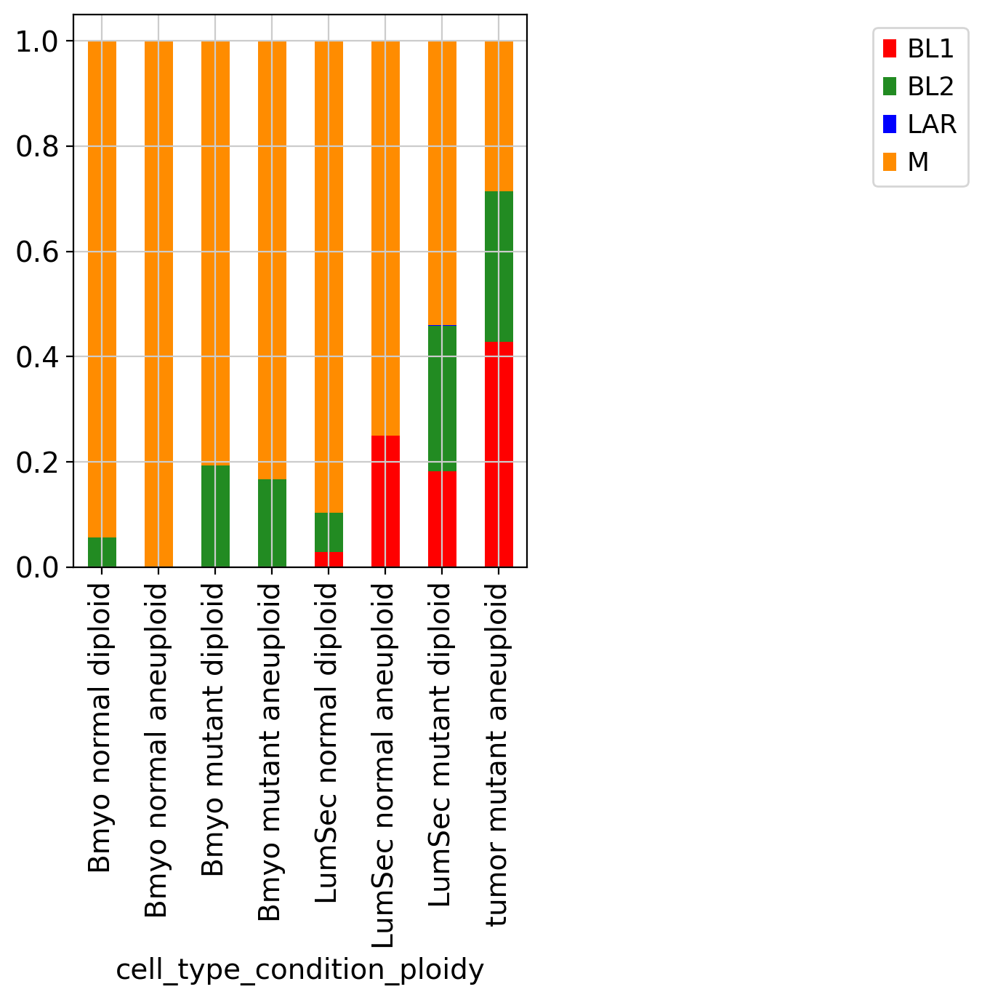

In [93]:
tmp = pd.crosstab(sub.obs['subtype'],sub.obs['cell_type_condition_ploidy'], 
                  normalize='columns').reindex()[['Bmyo normal diploid',
                  'Bmyo normal aneuploid',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec normal diploid',
                  'LumSec normal aneuploid',
                  'LumSec mutant diploid',
                 'tumor mutant aneuploid']].T.plot(kind='bar', stacked=True,
                                                                                                                  color=['red',
                                                'forestgreen',
                                                'blue',
                                               'darkorange',
                                               'grey'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')

#pl.savefig('subtype_cell_type_ploidy_stacked.pdf', bbox_inches='tight')

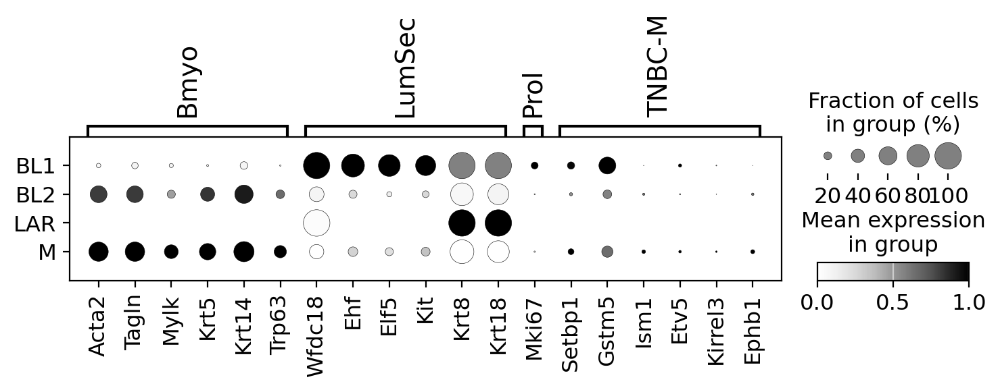

In [38]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "Prol": ["Mki67"],
    "TNBC-M":["Setbp1","Gstm5","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(sub, marker_genes, groupby="subtype",
              standard_scale="var",swap_axes=False,cmap="Grays",
              save='dot_canonical_subtype.pdf'
             )

In [117]:
sub2.obs.columns

Index(['orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample',
       'barcode', 'SeqID', 'SampleID', 'Age', 'Condition', 'Batch', 'UmiSums',
       'GenesDetected', 'prcntMito', 'residDetectionTrend', 'DbltScore',
       'Experiment', 'UMAP1', 'UMAP2', 'Cluster', 'Group', 'MajorGroups',
       'Groups', 'CellTypes', 'CellTypesFinal', 'Colors', 'ptime', 'ptimeBin',
       'GroupColors', 'UMAP_1', 'UMAP_2', 'cell_type', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
       '_scvi_batch', '_scvi_labels', 'leiden', 'scaled_combined_lumsec_basal',
       'subtype', 'p.value', 'correlation', 'subtype_tumor_only',
       'cell_type_epi_individual', 'highlight

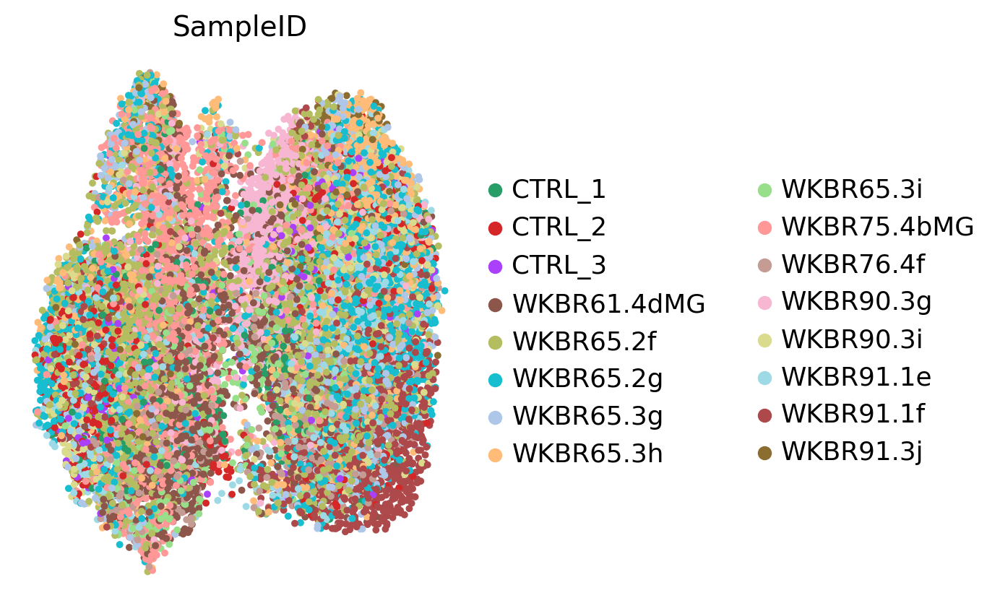

In [119]:
pl.rcParams["figure.figsize"] = (4,5)

sc.pl.umap(sub2, color='SampleID', size=50,save='_each_sample.pdf'
          )

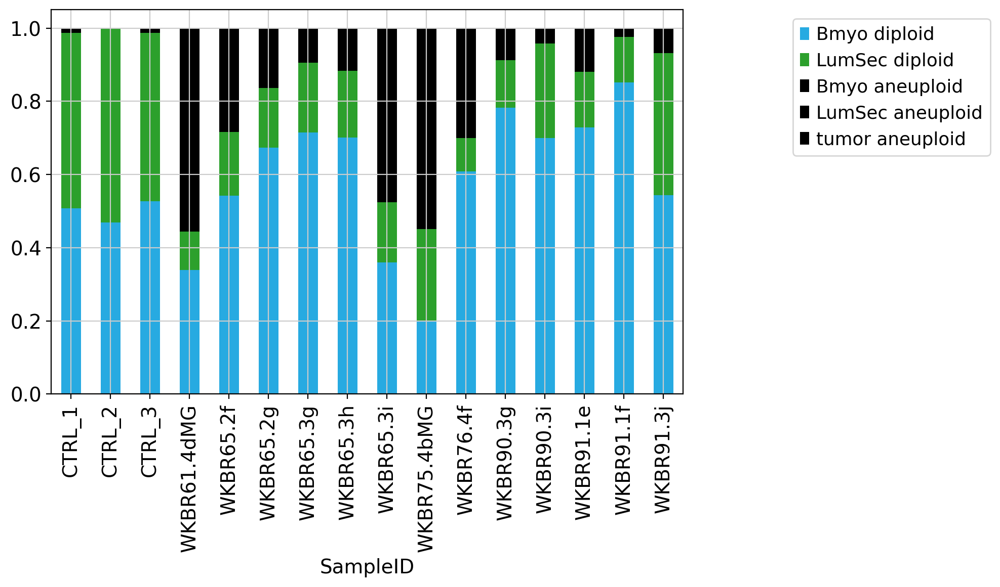

In [125]:
pl.rcParams["figure.figsize"] = (8,5)


tmp = pd.crosstab(sub2.obs['cell_type_ploidy'],sub2.obs['SampleID'], 
                  normalize='columns').reindex(['Bmyo diploid',
                 'LumSec diploid', 
                 'Bmyo aneuploid', 'LumSec aneuploid', 'tumor aneuploid']).T.plot(kind='bar', stacked=True,
                                                             color=['#27AAE1','#2ca02c','black','black','black'])
tmp.legend(title='', bbox_to_anchor=(1.5, 1),loc='upper right')

pl.savefig('sample_id_cell_type_ploidy_stacked.pdf', bbox_inches='tight')

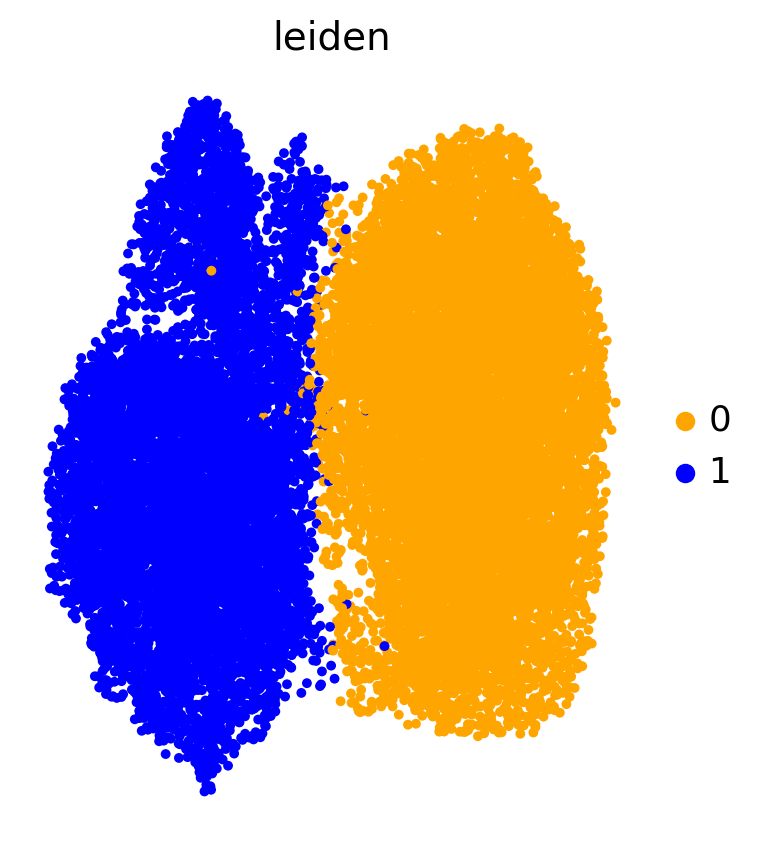

In [127]:
pl.rcParams["figure.figsize"] = (4,5)
sc.pl.umap(no_facs, color='leiden', size=50,
          palette = ["orange","blue"]
          )